In [1]:
# ============================================================
# DEMAND V3 — FOMO + TTFL + TRAFFIC + CONTACT RATE
# FULL PIPELINE FROM SCRATCH
#
# Goal:
# - Check "demand" more carefully for supply-demand analysis
# - Combine:
#   1. Supply: listing_count
#   2. FOMO: early contact rate in first N days
#   3. TTFL: time to first lead
#   4. Traffic: pageviews
#   5. CR: strict_contact / pageviews
#
# Important:
# - Filter by listing_count threshold to avoid tiny groups creating fake insights
# - Uses strict_contact only:
#   view_phone + contact_chat + contact_zalo + contact_sms
# - Keeps other_interaction only as optional all_positive metric
# ============================================================

# ============================================================
# 0. IMPORTS
# ============================================================

import os
import gc
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pyarrow.dataset as ds

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "iframe"

# ============================================================
# 1. CONFIG — EDIT HERE IF NEEDED
# ============================================================

DIM_LISTING_PATH = "/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1/dim_listing"
SNAPSHOT_PATH    = "/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1/fact_listing_snapshot"
EVENTS_PATH      = "/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-2/fact_user_events"

CACHE_DIR = "/kaggle/working/demand_v3_fomo_ttfl_traffic"

FORCE_REBUILD = True

# Batch size: giảm nếu bị OOM
DIM_BATCH_SIZE      = 500_000
SNAPSHOT_BATCH_SIZE = 500_000
EVENTS_BATCH_SIZE   = 300_000

# FOMO window
FOMO_MAX_AGE_DAYS = 7

# Grouping option:
# True  = city/category/ad_type, district/category/ad_type
# False = city/category, district/category
GROUP_WITH_AD_TYPE = True

# Listing threshold để tránh group quá nhỏ
MIN_LISTINGS_CITY_GROUP = 1000
MIN_LISTINGS_HCM_GROUP  = 500

# Evidence thresholds.
# Có thể set về 0 nếu chỉ muốn dùng listing_count threshold.
MIN_PAGEVIEWS_CITY_GROUP        = 1000
MIN_EARLY_VIEWS_CITY_GROUP     = 500
MIN_ITEMS_WITH_LEAD_CITY_GROUP = 30

MIN_PAGEVIEWS_HCM_GROUP        = 500
MIN_EARLY_VIEWS_HCM_GROUP     = 300
MIN_ITEMS_WITH_LEAD_HCM_GROUP = 20

STRICT_CONTACTS = {
    "view_phone",
    "contact_chat",
    "contact_zalo",
    "contact_sms",
}

ALL_POSITIVE = STRICT_CONTACTS.union({"other_interaction"})

CATEGORY_MAP = {
    1010: "1010 - Phòng trọ / căn hộ thuê",
    1020: "1020 - Căn hộ / chung cư",
    1030: "1030 - Nhà ở",
    1040: "1040 - Đất / BĐS thương mại",
    1050: "1050 - Dự án / căn hộ mới",
}

# ============================================================
# 2. RESET CACHE
# ============================================================

if FORCE_REBUILD and os.path.exists(CACHE_DIR):
    shutil.rmtree(CACHE_DIR)

os.makedirs(CACHE_DIR, exist_ok=True)

# ============================================================
# 3. HELPERS
# ============================================================

def clean_text(x, unknown="Unknown"):
    if pd.isna(x):
        return unknown
    x = str(x).strip()
    if x == "":
        return unknown
    return x


def clean_city(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).strip()
    if x == "":
        return "Unknown"

    xl = x.lower()

    if (
        "hồ chí minh" in xl
        or "ho chi minh" in xl
        or "tp.hcm" in xl
        or "tp hcm" in xl
        or xl == "hcm"
        or xl == "tphcm"
    ):
        return "Tp Hồ Chí Minh"

    return x


def clean_district(x):
    return clean_text(x, "Unknown District")


def clean_category(x):
    if pd.isna(x):
        return "Unknown Category"
    try:
        x = int(float(x))
        return CATEGORY_MAP.get(x, str(x))
    except Exception:
        return "Unknown Category"


def safe_div(num, den):
    return num / den.replace(0, np.nan)


def acc_add(acc, key, row, metric_cols):
    if key not in acc:
        acc[key] = {c: 0.0 for c in metric_cols}

    for c in metric_cols:
        acc[key][c] += float(row[c])


def acc_to_df(acc, key_cols):
    rows = []
    for key, values in acc.items():
        row = dict(zip(key_cols, key))
        row.update(values)
        rows.append(row)
    return pd.DataFrame(rows)


def add_group_label(df, geo_col):
    df = df.copy()

    parts = [df[geo_col].astype(str), df["category_name"].astype(str)]

    if GROUP_WITH_AD_TYPE and "ad_type" in df.columns:
        parts.append(df["ad_type"].astype(str))

    label = parts[0]
    for p in parts[1:]:
        label = label + " | " + p

    df["group_label"] = label
    return df


def pct_rank(series, higher_is_better=True):
    s = series.replace([np.inf, -np.inf], np.nan)
    if s.notna().sum() <= 1:
        return pd.Series(np.nan, index=s.index)

    if higher_is_better:
        return s.rank(pct=True, ascending=True)
    else:
        # lower value should get higher score
        return s.rank(pct=True, ascending=False)


def build_score_and_segment(
    df,
    geo_col,
    min_listings,
    min_pageviews,
    min_early_views,
    min_items_with_lead,
):
    df = df.copy()

    # -----------------------------
    # Basic ratios
    # -----------------------------
    df["pageviews_per_listing"] = safe_div(
        df["pageviews"],
        df["listing_count"]
    )

    df["strict_contact_per_listing"] = safe_div(
        df["strict_contact"],
        df["listing_count"]
    )

    df["all_positive_per_listing"] = safe_div(
        df["all_positive"],
        df["listing_count"]
    )

    df["strict_contact_rate"] = safe_div(
        df["strict_contact"],
        df["pageviews"]
    )

    df["all_positive_rate"] = safe_div(
        df["all_positive"],
        df["pageviews"]
    )

    df["fomo_early_contact_rate"] = safe_div(
        df["early_contacts_24h"],
        df["early_views_24h"]
    )

    df["lead_listing_rate"] = safe_div(
        df["items_with_lead"],
        df["listing_count"]
    )

    # -----------------------------
    # Reliability filters
    # -----------------------------
    df["passes_listing_threshold"] = (
        df["listing_count"].fillna(0) >= min_listings
    )

    df["passes_evidence_threshold"] = (
        (df["pageviews"].fillna(0) >= min_pageviews)
        & (df["early_views_24h"].fillna(0) >= min_early_views)
        & (df["items_with_lead"].fillna(0) >= min_items_with_lead)
    )

    df["analysis_eligible"] = (
        df["passes_listing_threshold"]
        & df["passes_evidence_threshold"]
        & df["fomo_early_contact_rate"].notna()
        & df["strict_contact_rate"].notna()
        & df["strict_contact_per_listing"].notna()
        & df["median_ttfl_days"].notna()
    )

    # -----------------------------
    # Rank-based demand score
    # -----------------------------
    score_cols = [
        "score_fomo",
        "score_strict_cr",
        "score_contact_per_listing",
        "score_ttfl_fast",
        "score_pageviews_per_listing",
    ]

    for c in score_cols:
        df[c] = np.nan

    idx = df["analysis_eligible"]

    df.loc[idx, "score_fomo"] = pct_rank(
        df.loc[idx, "fomo_early_contact_rate"],
        higher_is_better=True
    )

    df.loc[idx, "score_strict_cr"] = pct_rank(
        df.loc[idx, "strict_contact_rate"],
        higher_is_better=True
    )

    df.loc[idx, "score_contact_per_listing"] = pct_rank(
        df.loc[idx, "strict_contact_per_listing"],
        higher_is_better=True
    )

    df.loc[idx, "score_ttfl_fast"] = pct_rank(
        df.loc[idx, "median_ttfl_days"],
        higher_is_better=False
    )

    df.loc[idx, "score_pageviews_per_listing"] = pct_rank(
        df.loc[idx, "pageviews_per_listing"],
        higher_is_better=True
    )

    weights = {
        "score_fomo": 0.25,
        "score_strict_cr": 0.25,
        "score_contact_per_listing": 0.25,
        "score_ttfl_fast": 0.20,
        "score_pageviews_per_listing": 0.05,
    }

    weighted_sum = 0
    weight_used = 0

    for c, w in weights.items():
        valid_c = df[c].notna()
        weighted_sum = weighted_sum + df[c].fillna(0) * w
        weight_used = weight_used + valid_c.astype(float) * w

    df["demand_score"] = weighted_sum / weight_used.replace(0, np.nan)

    # -----------------------------
    # Segment labels
    # -----------------------------
    valid = df[df["analysis_eligible"]].copy()

    if len(valid) == 0:
        df["demand_segment"] = np.where(
            df["passes_listing_threshold"],
            "Enough listings but weak evidence",
            "Too small / unreliable"
        )
        return add_group_label(df, geo_col)

    q = {
        "fomo_hi": valid["fomo_early_contact_rate"].quantile(0.60),
        "fomo_lo": valid["fomo_early_contact_rate"].quantile(0.40),
        "cr_hi": valid["strict_contact_rate"].quantile(0.60),
        "cr_lo": valid["strict_contact_rate"].quantile(0.40),
        "cpl_hi": valid["strict_contact_per_listing"].quantile(0.60),
        "cpl_lo": valid["strict_contact_per_listing"].quantile(0.40),
        "ttfl_fast": valid["median_ttfl_days"].quantile(0.40),
        "ttfl_slow": valid["median_ttfl_days"].quantile(0.60),
        "traffic_hi": valid["pageviews_per_listing"].quantile(0.60),
        "traffic_lo": valid["pageviews_per_listing"].quantile(0.40),
        "supply_hi": valid["listing_count"].quantile(0.60),
    }

    def label(row):
        if not row["passes_listing_threshold"]:
            return "Too small / unreliable"

        if not row["passes_evidence_threshold"]:
            return "Enough listings but weak evidence"

        if not row["analysis_eligible"]:
            return "Missing key metric"

        high_fomo = row["fomo_early_contact_rate"] >= q["fomo_hi"]
        high_cr = row["strict_contact_rate"] >= q["cr_hi"]
        high_cpl = row["strict_contact_per_listing"] >= q["cpl_hi"]
        fast_ttfl = row["median_ttfl_days"] <= q["ttfl_fast"]

        low_cr = row["strict_contact_rate"] <= q["cr_lo"]
        low_cpl = row["strict_contact_per_listing"] <= q["cpl_lo"]
        slow_ttfl = row["median_ttfl_days"] >= q["ttfl_slow"]

        high_traffic = row["pageviews_per_listing"] >= q["traffic_hi"]
        low_traffic = row["pageviews_per_listing"] <= q["traffic_lo"]
        high_supply = row["listing_count"] >= q["supply_hi"]

        if high_fomo and high_cr and high_cpl and fast_ttfl:
            return "Confirmed hot demand"

        if high_traffic and low_cr:
            return "High attention, low conversion"

        if high_fomo and fast_ttfl and low_traffic:
            return "FOMO fast but traffic thin"

        if high_supply and low_cpl and slow_ttfl:
            return "Potential oversupply / slow liquidity"

        if high_cpl and fast_ttfl:
            return "Fast liquidity"

        if low_cpl and slow_ttfl:
            return "Weak demand / slow liquidity"

        return "Normal / mixed"

    df["demand_segment"] = df.apply(label, axis=1)

    return add_group_label(df, geo_col)


def save_plot(fig, name):
    path = os.path.join(CACHE_DIR, name)
    fig.write_html(path)
    fig.show(renderer="iframe")
    print("[SAVED]", path)


# ============================================================
# 4. FIND INPUT FILES
# ============================================================

print("Available Kaggle input folders:")
for dirname, _, filenames in os.walk("/kaggle/input"):
    if filenames:
        print(dirname, "| sample:", filenames[:2])

# ============================================================
# 5. BUILD item_map FROM dim_listing
# ============================================================

print("\n[1/7] Building item_map from dim_listing...")

dim_ds = ds.dataset(DIM_LISTING_PATH, format="parquet")

dim_cols = [
    "item_id",
    "city_name",
    "district_name",
    "category",
    "ad_type",
    "posted_date",
]

item_parts = []

for i, batch in enumerate(
    dim_ds.to_batches(columns=dim_cols, batch_size=DIM_BATCH_SIZE),
    start=1
):
    df = batch.to_pandas()

    df["city_name"] = df["city_name"].map(clean_city)
    df["district_name"] = df["district_name"].map(clean_district)
    df["category_name"] = df["category"].map(clean_category)
    df["ad_type"] = df["ad_type"].map(lambda x: clean_text(x, "Unknown Ad Type"))
    df["posted_date"] = pd.to_datetime(df["posted_date"], errors="coerce")

    df = df[
        [
            "item_id",
            "city_name",
            "district_name",
            "category",
            "category_name",
            "ad_type",
            "posted_date",
        ]
    ].drop_duplicates("item_id")

    item_parts.append(df)

    if i % 10 == 0:
        print("dim_listing batches:", i)

    del df
    gc.collect()

item_map = pd.concat(item_parts, ignore_index=True).drop_duplicates("item_id")

item_map_path = os.path.join(CACHE_DIR, "item_map.parquet")
item_map.to_parquet(item_map_path, index=False)

print("item_map shape:", item_map.shape)
display(item_map.head())

# ============================================================
# 6. GROUP KEYS
# ============================================================

city_keys = ["city_name", "category_name"]
hcm_keys = ["district_name", "category_name"]

if GROUP_WITH_AD_TYPE:
    city_keys.append("ad_type")
    hcm_keys.append("ad_type")

print("City group keys:", city_keys)
print("HCM group keys:", hcm_keys)

# ============================================================
# 7. BUILD SUPPLY TABLES FROM dim_listing
# ============================================================

print("\n[2/7] Building supply tables...")

city_supply = (
    item_map
    .groupby(city_keys, dropna=False)
    .agg(listing_count=("item_id", "nunique"))
    .reset_index()
)

hcm_supply = (
    item_map[
        (item_map["city_name"] == "Tp Hồ Chí Minh")
        & (~item_map["district_name"].isin(["Unknown District", "Unmapped Item"]))
    ]
    .groupby(hcm_keys, dropna=False)
    .agg(listing_count=("item_id", "nunique"))
    .reset_index()
)

city_supply.to_parquet(os.path.join(CACHE_DIR, "city_supply.parquet"), index=False)
hcm_supply.to_parquet(os.path.join(CACHE_DIR, "hcm_supply.parquet"), index=False)

print("city_supply:", city_supply.shape)
print("hcm_supply:", hcm_supply.shape)

display(city_supply.sort_values("listing_count", ascending=False).head(20))
display(hcm_supply.sort_values("listing_count", ascending=False).head(20))

# ============================================================
# 8. SCAN fact_listing_snapshot ONCE
#    Build FOMO + item-level TTFL
# ============================================================

print("\n[3/7] Scanning fact_listing_snapshot for FOMO + TTFL...")

snap_ds = ds.dataset(SNAPSHOT_PATH, format="parquet")

item_map_for_snapshot = item_map[
    [
        "item_id",
        "city_name",
        "district_name",
        "category_name",
        "ad_type",
        "posted_date",
    ]
].copy()

city_fomo_acc = {}
hcm_fomo_acc = {}

fomo_metric_cols = [
    "early_views_24h",
    "early_contacts_24h",
    "early_snapshot_rows",
    "early_unique_items_sum_batch",
    "missing_views_rows",
    "missing_contacts_rows",
]

first_lead = {}

dq = {
    "total_snapshot_rows": 0,
    "unmapped_item_rows": 0,
    "negative_age_rows": 0,
    "missing_views_rows": 0,
    "missing_contacts_rows": 0,
    "valid_fomo_rows": 0,
    "valid_first_lead_rows": 0,
}

snapshot_cols = [
    "item_id",
    "date",
    "views_24h",
    "contacts_24h",
    "listing_age_days",
]

for i, batch in enumerate(
    snap_ds.to_batches(columns=snapshot_cols, batch_size=SNAPSHOT_BATCH_SIZE),
    start=1
):
    df = batch.to_pandas()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["views_24h"] = pd.to_numeric(df["views_24h"], errors="coerce")
    df["contacts_24h"] = pd.to_numeric(df["contacts_24h"], errors="coerce")
    df["listing_age_days"] = pd.to_numeric(df["listing_age_days"], errors="coerce")

    dq["total_snapshot_rows"] += len(df)
    dq["negative_age_rows"] += int((df["listing_age_days"] < 0).sum())
    dq["missing_views_rows"] += int(df["views_24h"].isna().sum())
    dq["missing_contacts_rows"] += int(df["contacts_24h"].isna().sum())

    df = df.merge(
        item_map_for_snapshot,
        on="item_id",
        how="left",
        indicator=True
    )

    df["is_mapped_item"] = df["_merge"].eq("both")
    dq["unmapped_item_rows"] += int((~df["is_mapped_item"]).sum())

    # -----------------------------
    # 8A. FOMO rows
    # Keep NaN views/contact as 0.
    # Only remove negative / invalid age.
    # -----------------------------
    valid_fomo = df[
        (df["is_mapped_item"])
        & (df["listing_age_days"].notna())
        & (df["listing_age_days"] >= 0)
        & (df["listing_age_days"] <= FOMO_MAX_AGE_DAYS)
    ].copy()

    dq["valid_fomo_rows"] += len(valid_fomo)

    if len(valid_fomo) > 0:
        valid_fomo["views_24h_clean"] = valid_fomo["views_24h"].fillna(0)
        valid_fomo["contacts_24h_clean"] = valid_fomo["contacts_24h"].fillna(0)

        # City-level FOMO
        grp = (
            valid_fomo
            .groupby(city_keys, dropna=False)
            .agg(
                early_views_24h=("views_24h_clean", "sum"),
                early_contacts_24h=("contacts_24h_clean", "sum"),
                early_snapshot_rows=("item_id", "size"),
                early_unique_items_sum_batch=("item_id", "nunique"),
                missing_views_rows=("views_24h", lambda x: x.isna().sum()),
                missing_contacts_rows=("contacts_24h", lambda x: x.isna().sum()),
            )
            .reset_index()
        )

        for _, row in grp.iterrows():
            key = tuple(row[k] for k in city_keys)
            acc_add(city_fomo_acc, key, row, fomo_metric_cols)

        # HCM district-level FOMO
        hcm_valid = valid_fomo[
            (valid_fomo["city_name"] == "Tp Hồ Chí Minh")
            & (~valid_fomo["district_name"].isin(["Unknown District", "Unmapped Item"]))
        ].copy()

        if len(hcm_valid) > 0:
            grp = (
                hcm_valid
                .groupby(hcm_keys, dropna=False)
                .agg(
                    early_views_24h=("views_24h_clean", "sum"),
                    early_contacts_24h=("contacts_24h_clean", "sum"),
                    early_snapshot_rows=("item_id", "size"),
                    early_unique_items_sum_batch=("item_id", "nunique"),
                    missing_views_rows=("views_24h", lambda x: x.isna().sum()),
                    missing_contacts_rows=("contacts_24h", lambda x: x.isna().sum()),
                )
                .reset_index()
            )

            for _, row in grp.iterrows():
                key = tuple(row[k] for k in hcm_keys)
                acc_add(hcm_fomo_acc, key, row, fomo_metric_cols)

    # -----------------------------
    # 8B. TTFL item-level
    # First lead = minimum listing_age_days where contacts_24h > 0
    # -----------------------------
    lead_rows = df[
        (df["is_mapped_item"])
        & (df["listing_age_days"].notna())
        & (df["listing_age_days"] >= 0)
        & (df["contacts_24h"].notna())
        & (df["contacts_24h"] > 0)
    ][["item_id", "listing_age_days"]].copy()

    dq["valid_first_lead_rows"] += len(lead_rows)

    if len(lead_rows) > 0:
        first_in_batch = lead_rows.groupby("item_id")["listing_age_days"].min()

        for item_id, age in first_in_batch.items():
            old = first_lead.get(item_id)
            if old is None or age < old:
                first_lead[item_id] = float(age)

    if i % 20 == 0:
        print("snapshot batches:", i)

    del df, valid_fomo
    gc.collect()

city_fomo = acc_to_df(city_fomo_acc, city_keys)
hcm_fomo = acc_to_df(hcm_fomo_acc, hcm_keys)

item_first_lead = pd.DataFrame({
    "item_id": list(first_lead.keys()),
    "time_to_first_lead_days": list(first_lead.values()),
})

city_fomo.to_parquet(os.path.join(CACHE_DIR, "city_fomo.parquet"), index=False)
hcm_fomo.to_parquet(os.path.join(CACHE_DIR, "hcm_fomo.parquet"), index=False)
item_first_lead.to_parquet(os.path.join(CACHE_DIR, "item_first_lead.parquet"), index=False)

dq_df = pd.DataFrame([dq])
dq_df["valid_fomo_rate"] = dq_df["valid_fomo_rows"] / dq_df["total_snapshot_rows"]
dq_df["valid_first_lead_rate"] = dq_df["valid_first_lead_rows"] / dq_df["total_snapshot_rows"]
dq_df.to_csv(os.path.join(CACHE_DIR, "snapshot_dq_summary.csv"), index=False)

print("city_fomo:", city_fomo.shape)
print("hcm_fomo:", hcm_fomo.shape)
print("item_first_lead:", item_first_lead.shape)
display(dq_df)

# ============================================================
# 9. BUILD TTFL GROUP TABLES
# ============================================================

print("\n[4/7] Building TTFL group tables...")

ttfl = item_first_lead.merge(
    item_map[
        [
            "item_id",
            "city_name",
            "district_name",
            "category_name",
            "ad_type",
        ]
    ],
    on="item_id",
    how="left"
)

ttfl["time_to_first_lead_days"] = pd.to_numeric(
    ttfl["time_to_first_lead_days"],
    errors="coerce"
)

ttfl = ttfl[
    (ttfl["time_to_first_lead_days"].notna())
    & (ttfl["time_to_first_lead_days"] >= 0)
].copy()

city_ttfl = (
    ttfl
    .groupby(city_keys, dropna=False)
    .agg(
        items_with_lead=("item_id", "nunique"),
        median_ttfl_days=("time_to_first_lead_days", "median"),
        mean_ttfl_days=("time_to_first_lead_days", "mean"),
        p25_ttfl_days=("time_to_first_lead_days", lambda x: x.quantile(0.25)),
        p75_ttfl_days=("time_to_first_lead_days", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

hcm_ttfl = (
    ttfl[
        (ttfl["city_name"] == "Tp Hồ Chí Minh")
        & (~ttfl["district_name"].isin(["Unknown District", "Unmapped Item"]))
    ]
    .groupby(hcm_keys, dropna=False)
    .agg(
        items_with_lead=("item_id", "nunique"),
        median_ttfl_days=("time_to_first_lead_days", "median"),
        mean_ttfl_days=("time_to_first_lead_days", "mean"),
        p25_ttfl_days=("time_to_first_lead_days", lambda x: x.quantile(0.25)),
        p75_ttfl_days=("time_to_first_lead_days", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

city_ttfl.to_parquet(os.path.join(CACHE_DIR, "city_ttfl.parquet"), index=False)
hcm_ttfl.to_parquet(os.path.join(CACHE_DIR, "hcm_ttfl.parquet"), index=False)

print("city_ttfl:", city_ttfl.shape)
print("hcm_ttfl:", hcm_ttfl.shape)

display(city_ttfl.sort_values("items_with_lead", ascending=False).head(20))
display(hcm_ttfl.sort_values("items_with_lead", ascending=False).head(20))

# ============================================================
# 10. SCAN fact_user_events FOR TRAFFIC + CONTACT RATE
# ============================================================

print("\n[5/7] Scanning fact_user_events for traffic + strict contact rate...")

events_ds = ds.dataset(EVENTS_PATH, format="parquet")

item_map_for_events = item_map[
    [
        "item_id",
        "city_name",
        "district_name",
        "category_name",
        "ad_type",
    ]
].copy()

traffic_metric_cols = [
    "pageviews",
    "strict_contact",
    "all_positive",
    "total_events",
]

city_traffic_acc = {}
hcm_traffic_acc = {}

event_cols = [
    "item_id",
    "city_name",
    "category",
    "event_type",
]

for i, batch in enumerate(
    events_ds.to_batches(columns=event_cols, batch_size=EVENTS_BATCH_SIZE),
    start=1
):
    df = batch.to_pandas()

    df = df.rename(columns={
        "city_name": "event_city_name",
        "category": "event_category",
    })

    df["event_city_name"] = df["event_city_name"].map(clean_city)
    df["event_category_name"] = df["event_category"].map(clean_category)
    df["event_type"] = df["event_type"].fillna("unknown").astype(str)

    df = df.merge(
        item_map_for_events,
        on="item_id",
        how="left"
    )

    # Prefer dim_listing metadata.
    # If item is unmapped, fallback to event city/category where available.
    df["city_name"] = df["city_name"].fillna(df["event_city_name"])
    df["category_name"] = df["category_name"].fillna(df["event_category_name"])
    df["district_name"] = df["district_name"].fillna("Unknown District")
    df["ad_type"] = df["ad_type"].fillna("Unknown Ad Type")

    df["pageviews"] = (df["event_type"] == "pageview").astype(np.int64)
    df["strict_contact"] = df["event_type"].isin(STRICT_CONTACTS).astype(np.int64)
    df["all_positive"] = df["event_type"].isin(ALL_POSITIVE).astype(np.int64)
    df["total_events"] = 1

    # City traffic
    grp = (
        df
        .groupby(city_keys, dropna=False)[traffic_metric_cols]
        .sum()
        .reset_index()
    )

    for _, row in grp.iterrows():
        key = tuple(row[k] for k in city_keys)
        acc_add(city_traffic_acc, key, row, traffic_metric_cols)

    # HCM district traffic
    hcm_df = df[
        (df["city_name"] == "Tp Hồ Chí Minh")
        & (~df["district_name"].isin(["Unknown District", "Unmapped Item"]))
    ].copy()

    if len(hcm_df) > 0:
        grp = (
            hcm_df
            .groupby(hcm_keys, dropna=False)[traffic_metric_cols]
            .sum()
            .reset_index()
        )

        for _, row in grp.iterrows():
            key = tuple(row[k] for k in hcm_keys)
            acc_add(hcm_traffic_acc, key, row, traffic_metric_cols)

    if i % 20 == 0:
        print("event batches:", i)

    del df
    gc.collect()

city_traffic = acc_to_df(city_traffic_acc, city_keys)
hcm_traffic = acc_to_df(hcm_traffic_acc, hcm_keys)

city_traffic.to_parquet(os.path.join(CACHE_DIR, "city_traffic.parquet"), index=False)
hcm_traffic.to_parquet(os.path.join(CACHE_DIR, "hcm_traffic.parquet"), index=False)

print("city_traffic:", city_traffic.shape)
print("hcm_traffic:", hcm_traffic.shape)

display(city_traffic.sort_values("pageviews", ascending=False).head(20))
display(hcm_traffic.sort_values("pageviews", ascending=False).head(20))

# ============================================================
# 11. MERGE DEMAND V3 TABLES
# ============================================================

print("\n[6/7] Merging supply + FOMO + TTFL + traffic...")

count_cols = [
    "listing_count",
    "early_views_24h",
    "early_contacts_24h",
    "early_snapshot_rows",
    "early_unique_items_sum_batch",
    "missing_views_rows",
    "missing_contacts_rows",
    "items_with_lead",
    "pageviews",
    "strict_contact",
    "all_positive",
    "total_events",
]

city_demand = (
    city_supply
    .merge(city_fomo, on=city_keys, how="outer")
    .merge(city_ttfl, on=city_keys, how="outer")
    .merge(city_traffic, on=city_keys, how="outer")
)

hcm_demand = (
    hcm_supply
    .merge(hcm_fomo, on=hcm_keys, how="outer")
    .merge(hcm_ttfl, on=hcm_keys, how="outer")
    .merge(hcm_traffic, on=hcm_keys, how="outer")
)

for df in [city_demand, hcm_demand]:
    for c in count_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0)

city_demand = build_score_and_segment(
    city_demand,
    geo_col="city_name",
    min_listings=MIN_LISTINGS_CITY_GROUP,
    min_pageviews=MIN_PAGEVIEWS_CITY_GROUP,
    min_early_views=MIN_EARLY_VIEWS_CITY_GROUP,
    min_items_with_lead=MIN_ITEMS_WITH_LEAD_CITY_GROUP,
)

hcm_demand = build_score_and_segment(
    hcm_demand,
    geo_col="district_name",
    min_listings=MIN_LISTINGS_HCM_GROUP,
    min_pageviews=MIN_PAGEVIEWS_HCM_GROUP,
    min_early_views=MIN_EARLY_VIEWS_HCM_GROUP,
    min_items_with_lead=MIN_ITEMS_WITH_LEAD_HCM_GROUP,
)

city_result_path = os.path.join(CACHE_DIR, "city_demand_v3_fomo_ttfl_traffic.csv")
hcm_result_path = os.path.join(CACHE_DIR, "hcm_district_demand_v3_fomo_ttfl_traffic.csv")

city_demand.to_csv(city_result_path, index=False)
hcm_demand.to_csv(hcm_result_path, index=False)

print("[SAVED]", city_result_path)
print("[SAVED]", hcm_result_path)

# ============================================================
# 12. MAIN TABLES TO INSPECT
# ============================================================

print("\nTop confirmed / high-score city groups:")
top_city = (
    city_demand[
        city_demand["analysis_eligible"]
    ]
    .sort_values("demand_score", ascending=False)
    .head(30)
)

display(
    top_city[
        [
            "group_label",
            "listing_count",
            "pageviews",
            "strict_contact",
            "strict_contact_rate",
            "strict_contact_per_listing",
            "early_views_24h",
            "early_contacts_24h",
            "fomo_early_contact_rate",
            "items_with_lead",
            "lead_listing_rate",
            "median_ttfl_days",
            "demand_score",
            "demand_segment",
        ]
    ]
)

print("\nTop confirmed / high-score HCM district groups:")
top_hcm = (
    hcm_demand[
        hcm_demand["analysis_eligible"]
    ]
    .sort_values("demand_score", ascending=False)
    .head(30)
)

display(
    top_hcm[
        [
            "group_label",
            "listing_count",
            "pageviews",
            "strict_contact",
            "strict_contact_rate",
            "strict_contact_per_listing",
            "early_views_24h",
            "early_contacts_24h",
            "fomo_early_contact_rate",
            "items_with_lead",
            "lead_listing_rate",
            "median_ttfl_days",
            "demand_score",
            "demand_segment",
        ]
    ]
)

print("\nPotential high attention but low conversion — city:")
display(
    city_demand[
        city_demand["analysis_eligible"]
        & (city_demand["demand_segment"] == "High attention, low conversion")
    ]
    .sort_values("pageviews_per_listing", ascending=False)
    .head(20)
    [
        [
            "group_label",
            "listing_count",
            "pageviews_per_listing",
            "strict_contact_rate",
            "strict_contact_per_listing",
            "median_ttfl_days",
            "demand_segment",
        ]
    ]
)

print("\nPotential oversupply / slow liquidity — HCM:")
display(
    hcm_demand[
        hcm_demand["analysis_eligible"]
        & (hcm_demand["demand_segment"] == "Potential oversupply / slow liquidity")
    ]
    .sort_values(["listing_count", "strict_contact_per_listing"], ascending=[False, True])
    .head(20)
    [
        [
            "group_label",
            "listing_count",
            "pageviews",
            "strict_contact_rate",
            "strict_contact_per_listing",
            "median_ttfl_days",
            "demand_segment",
        ]
    ]
)

# Save key filtered tables
top_city.to_csv(os.path.join(CACHE_DIR, "top_city_confirmed_demand.csv"), index=False)
top_hcm.to_csv(os.path.join(CACHE_DIR, "top_hcm_confirmed_demand.csv"), index=False)

city_demand[
    ~city_demand["passes_listing_threshold"]
].to_csv(os.path.join(CACHE_DIR, "city_groups_too_small.csv"), index=False)

hcm_demand[
    ~hcm_demand["passes_listing_threshold"]
].to_csv(os.path.join(CACHE_DIR, "hcm_groups_too_small.csv"), index=False)

# ============================================================
# 13. PLOTS
# ============================================================

print("\n[7/7] Drawing charts...")

# -----------------------------
# 13A. City scatter: supply vs demand score
# -----------------------------
plot_city = city_demand[
    city_demand["passes_listing_threshold"]
].copy()

fig = px.scatter(
    plot_city,
    x="listing_count",
    y="demand_score",
    size="pageviews",
    color="demand_segment",
    hover_name="group_label",
    hover_data={
        "listing_count": ":,.0f",
        "pageviews": ":,.0f",
        "strict_contact": ":,.0f",
        "strict_contact_rate": ":.4f",
        "strict_contact_per_listing": ":.4f",
        "fomo_early_contact_rate": ":.4f",
        "median_ttfl_days": ":.2f",
        "items_with_lead": ":,.0f",
        "demand_score": ":.3f",
    },
    log_x=True,
    title="City Group Demand V3: Supply vs Combined Demand Score",
)

fig.update_layout(height=650)
save_plot(fig, "city_supply_vs_demand_score.html")

# -----------------------------
# 13B. HCM scatter: supply vs demand score
# -----------------------------
plot_hcm = hcm_demand[
    hcm_demand["passes_listing_threshold"]
].copy()

fig = px.scatter(
    plot_hcm,
    x="listing_count",
    y="demand_score",
    size="pageviews",
    color="demand_segment",
    hover_name="group_label",
    hover_data={
        "listing_count": ":,.0f",
        "pageviews": ":,.0f",
        "strict_contact": ":,.0f",
        "strict_contact_rate": ":.4f",
        "strict_contact_per_listing": ":.4f",
        "fomo_early_contact_rate": ":.4f",
        "median_ttfl_days": ":.2f",
        "items_with_lead": ":,.0f",
        "demand_score": ":.3f",
    },
    log_x=True,
    title="HCM District Group Demand V3: Supply vs Combined Demand Score",
)

fig.update_layout(height=650)
save_plot(fig, "hcm_supply_vs_demand_score.html")

# -----------------------------
# 13C. Top City groups by demand score
# -----------------------------
plot_top = (
    city_demand[
        city_demand["analysis_eligible"]
    ]
    .sort_values("demand_score", ascending=False)
    .head(25)
    .sort_values("demand_score", ascending=True)
)

fig = px.bar(
    plot_top,
    x="demand_score",
    y="group_label",
    orientation="h",
    color="demand_segment",
    hover_data={
        "listing_count": ":,.0f",
        "pageviews": ":,.0f",
        "strict_contact_rate": ":.4f",
        "fomo_early_contact_rate": ":.4f",
        "median_ttfl_days": ":.2f",
    },
    title="Top City Groups by Demand V3 Score",
)

fig.update_layout(height=750, yaxis_title="")
save_plot(fig, "top_city_demand_score.html")

# -----------------------------
# 13D. Top HCM groups by demand score
# -----------------------------
plot_top = (
    hcm_demand[
        hcm_demand["analysis_eligible"]
    ]
    .sort_values("demand_score", ascending=False)
    .head(25)
    .sort_values("demand_score", ascending=True)
)

fig = px.bar(
    plot_top,
    x="demand_score",
    y="group_label",
    orientation="h",
    color="demand_segment",
    hover_data={
        "listing_count": ":,.0f",
        "pageviews": ":,.0f",
        "strict_contact_rate": ":.4f",
        "fomo_early_contact_rate": ":.4f",
        "median_ttfl_days": ":.2f",
    },
    title="Top HCM District Groups by Demand V3 Score",
)

fig.update_layout(height=750, yaxis_title="")
save_plot(fig, "top_hcm_demand_score.html")

# -----------------------------
# 13E. FOMO vs TTFL map — HCM
# x high = stronger FOMO
# y low = faster lead
# -----------------------------
plot_hcm2 = hcm_demand[
    hcm_demand["analysis_eligible"]
].copy()

fig = px.scatter(
    plot_hcm2,
    x="fomo_early_contact_rate",
    y="median_ttfl_days",
    size="listing_count",
    color="demand_segment",
    hover_name="group_label",
    hover_data={
        "listing_count": ":,.0f",
        "pageviews": ":,.0f",
        "strict_contact_rate": ":.4f",
        "strict_contact_per_listing": ":.4f",
        "items_with_lead": ":,.0f",
        "demand_score": ":.3f",
    },
    title="HCM Demand Map: FOMO Rate vs Median TTFL<br>Right = stronger early demand, Lower = faster lead",
)

fig.update_yaxes(autorange="reversed")
fig.update_layout(height=650)
save_plot(fig, "hcm_fomo_vs_ttfl.html")

# -----------------------------
# 13F. Segment count
# -----------------------------
seg_city = (
    city_demand["demand_segment"]
    .value_counts()
    .reset_index()
)
seg_city.columns = ["demand_segment", "groups"]

fig = px.bar(
    seg_city,
    x="demand_segment",
    y="groups",
    title="City Group Count by Demand Segment",
)
fig.update_layout(height=500, xaxis_tickangle=-30)
save_plot(fig, "city_segment_count.html")

seg_hcm = (
    hcm_demand["demand_segment"]
    .value_counts()
    .reset_index()
)
seg_hcm.columns = ["demand_segment", "groups"]

fig = px.bar(
    seg_hcm,
    x="demand_segment",
    y="groups",
    title="HCM Group Count by Demand Segment",
)
fig.update_layout(height=500, xaxis_tickangle=-30)
save_plot(fig, "hcm_segment_count.html")

# ============================================================
# 14. OUTPUT FILES
# ============================================================

print("\nDONE. Output files:")
for f in sorted(os.listdir(CACHE_DIR)):
    print("-", os.path.join(CACHE_DIR, f))

Available Kaggle input folders:
/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1/fact_listing_snapshot | sample: ['datathon_fact_listing_snapshot-000000000052.parquet', 'datathon_fact_listing_snapshot-000000000036.parquet']
/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1/fact_post_contact_interactions | sample: ['datathon_fact_user_ad_interactions-000000000092.parquet', 'datathon_fact_user_ad_interactions-000000000099.parquet']
/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1/dim_listing | sample: ['datathon_dim_listing-000000000012.parquet', 'datathon_dim_listing-000000000023.parquet']
/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1/test | sample: ['test_users.parquet']
/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-2/fact_user_events | sample: ['datathon_fact_user_events-000000000246.parquet', 'datathon_fact_user_events-000000000185.parquet']

[1/7] Building item_map from dim_listing...
dim_listing batches: 10
dim_listing batches: 20
dim_listing b

,item_id,city_name,district_name,category,category_name,ad_type,posted_date
0,bc8a95ba9c8c41b86fc446e58af07aacf1e98cb0a8f632...,Tp Hồ Chí Minh,Quận 3,1010,1010 - Phòng trọ / căn hộ thuê,let,2025-03-04
1,2e58d907f4986a98aa31700ae56883bbc85748932d58af...,Tp Hồ Chí Minh,Quận 8,1010,1010 - Phòng trọ / căn hộ thuê,let,2025-05-04
2,3d186c9e829ba17729a239816bcfe24c9e23bdd119f62c...,Tp Hồ Chí Minh,Quận 8,1010,1010 - Phòng trọ / căn hộ thuê,let,2025-04-17
3,e9f549a8c6b0ed5c823df7de5c0344d7b0b1777a65af61...,Tp Hồ Chí Minh,Quận 3,1010,1010 - Phòng trọ / căn hộ thuê,let,2025-07-03
4,6c30deece657bdce3cd0ab779e3dc0954ca775cd275379...,Tp Hồ Chí Minh,Quận Gò Vấp,1010,1010 - Phòng trọ / căn hộ thuê,let,2025-11-26


City group keys: ['city_name', 'category_name', 'ad_type']
HCM group keys: ['district_name', 'category_name', 'ad_type']

[2/7] Building supply tables...
city_supply: (508, 4)
hcm_supply: (200, 4)


,city_name,category_name,ad_type,listing_count
407,Tp Hồ Chí Minh,1020 - Căn hộ / chung cư,sell,733140
404,Tp Hồ Chí Minh,1010 - Phòng trọ / căn hộ thuê,let,373553
412,Tp Hồ Chí Minh,1050 - Dự án / căn hộ mới,let,325650
406,Tp Hồ Chí Minh,1020 - Căn hộ / chung cư,let,321968
408,Tp Hồ Chí Minh,1030 - Nhà ở,let,175926
133,Hà Nội,1020 - Căn hộ / chung cư,sell,160037
411,Tp Hồ Chí Minh,1040 - Đất / BĐS thương mại,sell,99867
405,Tp Hồ Chí Minh,1010 - Phòng trọ / căn hộ thuê,sell,79612
467,Đà Nẵng,1020 - Căn hộ / chung cư,sell,57231
471,Đà Nẵng,1040 - Đất / BĐS thương mại,sell,48328


,district_name,category_name,ad_type,listing_count
147,Quận Bình Tân,1020 - Căn hộ / chung cư,sell,90354
156,Quận Gò Vấp,1020 - Căn hộ / chung cư,sell,84777
75,Quận 12,1020 - Căn hộ / chung cư,sell,71540
193,Thành phố Thủ Đức,1020 - Căn hộ / chung cư,sell,70658
183,Quận Tân Phú,1020 - Căn hộ / chung cư,sell,59114
161,Quận Gò Vấp,1050 - Dự án / căn hộ mới,let,51298
135,Quận Bình Thạnh,1010 - Phòng trọ / căn hộ thuê,let,46815
174,Quận Tân Bình,1020 - Căn hộ / chung cư,sell,46272
138,Quận Bình Thạnh,1020 - Căn hộ / chung cư,sell,45568
120,Quận 7,1020 - Căn hộ / chung cư,sell,44566


...

[SAVED] /kaggle/working/demand_v3_fomo_ttfl_traffic/top_city_demand_score.html


[SAVED] /kaggle/working/demand_v3_fomo_ttfl_traffic/top_hcm_demand_score.html


[SAVED] /kaggle/working/demand_v3_fomo_ttfl_traffic/hcm_fomo_vs_ttfl.html


[SAVED] /kaggle/working/demand_v3_fomo_ttfl_traffic/city_segment_count.html


[SAVED] /kaggle/working/demand_v3_fomo_ttfl_traffic/hcm_segment_count.html

DONE. Output files:
- /kaggle/working/demand_v3_fomo_ttfl_traffic/city_demand_v3_fomo_ttfl_traffic.csv
- /kaggle/working/demand_v3_fomo_ttfl_traffic/city_fomo.parquet
- /kaggle/working/demand_v3_fomo_ttfl_traffic/city_groups_too_small.csv
- /kaggle/working/demand_v3_fomo_ttfl_traffic/city_segment_count.html
- /kaggle/working/demand_v3_fomo_ttfl_traffic/city_supply.parquet
- /kaggle/working/demand_v3_fomo_ttfl_traffic/city_supply_vs_demand_score.html
- /kaggle/working/demand_v3_fomo_ttfl_traffic/city_traffic.parquet
- /kaggle/working/demand_v3_fomo_ttfl_traffic/city_ttfl.parquet
- /kaggle/working/demand_v3_fomo_ttfl_traffic/hcm_district_demand_v3_fomo_ttfl_traffic.csv
- /kaggle/working/demand_v3_fomo_ttfl_traffic/hcm_fomo.parquet
- /kaggle/working/demand_v3_fomo_ttfl_traffic/hcm_fomo_vs_ttfl.html
- /kaggle/working/demand_v3_fomo_ttfl_traffic/hcm_groups_too_small.csv
- /kaggle/working/demand_v3_fomo_ttfl_traffic/

In [4]:
# ============================================================
# REDRAW FOMO / TTFL / DEMAND HEATMAPS FROM READ-ONLY OLD OUTPUT
# ============================================================

import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "iframe"

# ============================================================
# 1. PATH CONFIG
# ============================================================

# Read-only old notebook output
READ_CACHE_DIR = "/kaggle/input/notebooks/kimkhanhnguyen214/cung-cau/demand_v3_fomo_ttfl_traffic"

# Writable new output
OUT_DIR = "/kaggle/working/redraw_demand_fomo_ttfl_heatmaps"
os.makedirs(OUT_DIR, exist_ok=True)

CITY_FINAL_CSV = os.path.join(READ_CACHE_DIR, "city_demand_v3_fomo_ttfl_traffic.csv")
HCM_FINAL_CSV  = os.path.join(READ_CACHE_DIR, "hcm_district_demand_v3_fomo_ttfl_traffic.csv")

CITY_SUPPLY_PARQUET = os.path.join(READ_CACHE_DIR, "city_supply.parquet")
CITY_FOMO_PARQUET   = os.path.join(READ_CACHE_DIR, "city_fomo.parquet")
CITY_TTFL_PARQUET   = os.path.join(READ_CACHE_DIR, "city_ttfl.parquet")

HCM_SUPPLY_PARQUET  = os.path.join(READ_CACHE_DIR, "hcm_supply.parquet")
HCM_FOMO_PARQUET    = os.path.join(READ_CACHE_DIR, "hcm_fomo.parquet")
HCM_TTFL_PARQUET    = os.path.join(READ_CACHE_DIR, "hcm_ttfl.parquet")

MIN_LISTINGS_CITY = 1000
MIN_LISTINGS_HCM  = 500

TOP_CITY_ROWS = 35
TOP_HCM_ROWS  = 30

print("READ_CACHE_DIR:", READ_CACHE_DIR)
print("OUT_DIR:", OUT_DIR)

print("\nFiles in READ_CACHE_DIR:")
for f in sorted(os.listdir(READ_CACHE_DIR)):
    print("-", f)

# ============================================================
# 2. HELPERS
# ============================================================

def safe_div(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)

def pct_rank(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)

    if s.notna().sum() <= 1:
        return pd.Series(np.nan, index=s.index)

    if higher_is_better:
        return s.rank(pct=True, ascending=True)
    else:
        return s.rank(pct=True, ascending=False)

def save_html(fig, filename):
    path = os.path.join(OUT_DIR, filename)
    fig.write_html(path)
    print("[SAVED]", path)

def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

def build_from_parts(supply_path, fomo_path, ttfl_path, geo_keys):
    supply = pd.read_parquet(supply_path)
    fomo   = pd.read_parquet(fomo_path)
    ttfl   = pd.read_parquet(ttfl_path)

    df = (
        supply
        .merge(fomo, on=geo_keys, how="outer")
        .merge(ttfl, on=geo_keys, how="outer")
    )

    count_cols = [
        "listing_count",
        "early_views_24h",
        "early_contacts_24h",
        "early_snapshot_rows",
        "early_unique_items_sum_batch",
        "missing_views_rows",
        "missing_contacts_rows",
        "items_with_lead",
    ]

    for c in count_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0)

    return df

def enrich_fomo_ttfl_demand(df):
    df = df.copy()

    for c in [
        "listing_count",
        "early_views_24h",
        "early_contacts_24h",
        "items_with_lead",
        "median_ttfl_days",
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # FOMO = early contacts / early views
    df["fomo_early_contact_rate"] = safe_div(
        df["early_contacts_24h"],
        df["early_views_24h"]
    )

    # TTFL speed: thấp ngày hơn => speed cao hơn
    df["ttfl_speed"] = 1 / (1 + df["median_ttfl_days"])

    # Percentile rank để normalize 2 metric khác đơn vị
    df["score_fomo"] = pct_rank(
        df["fomo_early_contact_rate"],
        higher_is_better=True
    )

    df["score_ttfl_speed"] = pct_rank(
        df["ttfl_speed"],
        higher_is_better=True
    )

    # Demand score chỉ từ FOMO + TTFL
    df["demand_score_fomo_ttfl"] = (
        0.6 * df["score_fomo"] +
        0.4 * df["score_ttfl_speed"]
    )

    return df

def add_labels(df, geo_col):
    df = df.copy()

    if "ad_type" in df.columns:
        df["heatmap_col"] = df["category_name"].astype(str) + " | " + df["ad_type"].astype(str)
        df["segment_label"] = (
            df[geo_col].astype(str)
            + " | "
            + df["category_name"].astype(str)
            + " | "
            + df["ad_type"].astype(str)
        )
    else:
        df["heatmap_col"] = df["category_name"].astype(str)
        df["segment_label"] = (
            df[geo_col].astype(str)
            + " | "
            + df["category_name"].astype(str)
        )

    return df

def make_heatmap(
    df,
    row_col,
    col_col,
    value_col,
    title,
    filename,
    text_auto=".3f",
    reverse_scale=False,
    zmin=None,
    zmax=None,
    sort_rows="desc",
):
    tmp = df.copy()

    pivot = tmp.pivot_table(
        index=row_col,
        columns=col_col,
        values=value_col,
        aggfunc="mean"
    )

    row_mean = pivot.mean(axis=1)

    if sort_rows == "desc":
        pivot = pivot.loc[row_mean.sort_values(ascending=False).index]
    elif sort_rows == "asc":
        pivot = pivot.loc[row_mean.sort_values(ascending=True).index]

    height = max(450, 28 * len(pivot) + 180)

    color_scale = "RdYlGn_r" if reverse_scale else "RdYlGn"

    fig = px.imshow(
        pivot,
        aspect="auto",
        text_auto=text_auto,
        color_continuous_scale=color_scale,
        zmin=zmin,
        zmax=zmax,
        title=title,
    )

    fig.update_layout(
        height=height,
        xaxis_title="Category / Ad Type",
        yaxis_title=row_col,
    )

    fig.show()
    save_html(fig, filename)

    matrix_path = os.path.join(OUT_DIR, filename.replace(".html", "_matrix.csv"))
    pivot.to_csv(matrix_path)
    print("[SAVED]", matrix_path)

    return pivot

def aggregate_geo_overall(df, geo_col):
    tmp = df.copy()

    tmp["ttfl_weighted_component"] = (
        tmp["median_ttfl_days"] * tmp["items_with_lead"].fillna(0)
    )

    grp = (
        tmp.groupby(geo_col, dropna=False)
        .agg(
            listing_count=("listing_count", "sum"),
            early_views_24h=("early_views_24h", "sum"),
            early_contacts_24h=("early_contacts_24h", "sum"),
            items_with_lead=("items_with_lead", "sum"),
            ttfl_weighted_component=("ttfl_weighted_component", "sum"),
        )
        .reset_index()
    )

    grp["median_ttfl_days"] = (
        grp["ttfl_weighted_component"]
        / grp["items_with_lead"].replace(0, np.nan)
    )

    grp = grp.drop(columns=["ttfl_weighted_component"])
    grp = enrich_fomo_ttfl_demand(grp)

    return grp

# ============================================================
# 3. LOAD CITY / HCM DATA
# ============================================================

# CITY
if os.path.exists(CITY_FINAL_CSV):
    print("\n[LOAD] city final CSV")
    city = pd.read_csv(CITY_FINAL_CSV)
else:
    print("\n[LOAD] city from parts")
    city_supply_test = pd.read_parquet(CITY_SUPPLY_PARQUET)
    city_keys = ["city_name", "category_name"]
    if "ad_type" in city_supply_test.columns:
        city_keys.append("ad_type")

    city = build_from_parts(
        CITY_SUPPLY_PARQUET,
        CITY_FOMO_PARQUET,
        CITY_TTFL_PARQUET,
        city_keys
    )

# HCM
if os.path.exists(HCM_FINAL_CSV):
    print("[LOAD] hcm final CSV")
    hcm = pd.read_csv(HCM_FINAL_CSV)
else:
    print("[LOAD] hcm from parts")
    hcm_supply_test = pd.read_parquet(HCM_SUPPLY_PARQUET)
    hcm_keys = ["district_name", "category_name"]
    if "ad_type" in hcm_supply_test.columns:
        hcm_keys.append("ad_type")

    hcm = build_from_parts(
        HCM_SUPPLY_PARQUET,
        HCM_FOMO_PARQUET,
        HCM_TTFL_PARQUET,
        hcm_keys
    )

city = enrich_fomo_ttfl_demand(city)
hcm  = enrich_fomo_ttfl_demand(hcm)

city = add_labels(city, "city_name")
hcm  = add_labels(hcm, "district_name")

city_plot = city[city["listing_count"] >= MIN_LISTINGS_CITY].copy()
hcm_plot  = hcm[hcm["listing_count"] >= MIN_LISTINGS_HCM].copy()

hcm_plot = hcm_plot[
    ~hcm_plot["district_name"].astype(str).isin(["Unknown District", "Unmapped Item"])
].copy()

print("\ncity raw:", city.shape, "| filtered:", city_plot.shape)
print("hcm raw :", hcm.shape, "| filtered:", hcm_plot.shape)

# ============================================================
# 4. FORMULA PRINT
# ============================================================

print("\n" + "="*100)
print("DEMAND FORMULA")
print("="*100)
print("FOMO rate   = early_contacts_24h / early_views_24h")
print("TTFL speed  = 1 / (1 + median_ttfl_days)")
print("Demand      = 0.6 * pct_rank(FOMO rate) + 0.4 * pct_rank(TTFL speed)")
print("Note: TTFL càng thấp càng tốt, nên đổi thành TTFL speed trước khi rank.")
print(f"City threshold: listing_count >= {MIN_LISTINGS_CITY}")
print(f"HCM threshold : listing_count >= {MIN_LISTINGS_HCM}")

# ============================================================
# 5. DISPLAY FOMO / TTFL TABLES
# ============================================================

city_fomo_cols = existing_cols(city_plot, [
    "city_name", "category_name", "ad_type",
    "listing_count",
    "early_views_24h",
    "early_contacts_24h",
    "fomo_early_contact_rate",
    "median_ttfl_days",
    "demand_score_fomo_ttfl",
])

city_ttfl_cols = existing_cols(city_plot, [
    "city_name", "category_name", "ad_type",
    "listing_count",
    "items_with_lead",
    "median_ttfl_days",
    "mean_ttfl_days",
    "p25_ttfl_days",
    "p75_ttfl_days",
    "fomo_early_contact_rate",
    "demand_score_fomo_ttfl",
])

hcm_fomo_cols = existing_cols(hcm_plot, [
    "district_name", "category_name", "ad_type",
    "listing_count",
    "early_views_24h",
    "early_contacts_24h",
    "fomo_early_contact_rate",
    "median_ttfl_days",
    "demand_score_fomo_ttfl",
])

hcm_ttfl_cols = existing_cols(hcm_plot, [
    "district_name", "category_name", "ad_type",
    "listing_count",
    "items_with_lead",
    "median_ttfl_days",
    "mean_ttfl_days",
    "p25_ttfl_days",
    "p75_ttfl_days",
    "fomo_early_contact_rate",
    "demand_score_fomo_ttfl",
])

print("\nCITY FOMO TABLE")
display(
    city_plot
    .sort_values("fomo_early_contact_rate", ascending=False)
    [city_fomo_cols]
    .head(40)
)

print("\nCITY TTFL TABLE")
display(
    city_plot
    .sort_values("median_ttfl_days", ascending=True)
    [city_ttfl_cols]
    .head(40)
)

print("\nHCM FOMO TABLE")
display(
    hcm_plot
    .sort_values("fomo_early_contact_rate", ascending=False)
    [hcm_fomo_cols]
    .head(40)
)

print("\nHCM TTFL TABLE")
display(
    hcm_plot
    .sort_values("median_ttfl_days", ascending=True)
    [hcm_ttfl_cols]
    .head(40)
)

# Save tables
city_plot.sort_values("fomo_early_contact_rate", ascending=False).to_csv(
    os.path.join(OUT_DIR, "city_fomo_table.csv"),
    index=False
)

city_plot.sort_values("median_ttfl_days", ascending=True).to_csv(
    os.path.join(OUT_DIR, "city_ttfl_table.csv"),
    index=False
)

hcm_plot.sort_values("fomo_early_contact_rate", ascending=False).to_csv(
    os.path.join(OUT_DIR, "hcm_fomo_table.csv"),
    index=False
)

hcm_plot.sort_values("median_ttfl_days", ascending=True).to_csv(
    os.path.join(OUT_DIR, "hcm_ttfl_table.csv"),
    index=False
)

# ============================================================
# 6. OVERALL DEMAND TABLES
# ============================================================

city_overall = aggregate_geo_overall(city_plot, "city_name")
hcm_overall  = aggregate_geo_overall(hcm_plot, "district_name")

city_overall = city_overall.sort_values("demand_score_fomo_ttfl", ascending=False)
hcm_overall  = hcm_overall.sort_values("demand_score_fomo_ttfl", ascending=False)

print("\nOVERALL CITY DEMAND")
display(city_overall.head(40))

print("\nOVERALL HCM DISTRICT DEMAND")
display(hcm_overall.head(40))

city_overall.to_csv(
    os.path.join(OUT_DIR, "city_overall_demand_fomo_ttfl.csv"),
    index=False
)

hcm_overall.to_csv(
    os.path.join(OUT_DIR, "hcm_overall_demand_fomo_ttfl.csv"),
    index=False
)

# ============================================================
# 7. HEATMAPS BY CITY
# ============================================================

top_city_names = (
    city_plot.groupby("city_name")["listing_count"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_CITY_ROWS)
    .index
)

city_hm = city_plot[city_plot["city_name"].isin(top_city_names)].copy()

make_heatmap(
    city_hm,
    row_col="city_name",
    col_col="heatmap_col",
    value_col="fomo_early_contact_rate",
    title="CITY HEATMAP — FOMO RATE = early_contacts / early_views",
    filename="city_heatmap_fomo.html",
    text_auto=".3f",
    reverse_scale=False,
    sort_rows="desc",
)

make_heatmap(
    city_hm,
    row_col="city_name",
    col_col="heatmap_col",
    value_col="median_ttfl_days",
    title="CITY HEATMAP — MEDIAN TTFL DAYS, LOWER = HOTTER",
    filename="city_heatmap_ttfl.html",
    text_auto=".1f",
    reverse_scale=True,
    sort_rows="asc",
)

make_heatmap(
    city_hm,
    row_col="city_name",
    col_col="heatmap_col",
    value_col="demand_score_fomo_ttfl",
    title="CITY HEATMAP — DEMAND SCORE FROM FOMO + TTFL",
    filename="city_heatmap_demand.html",
    text_auto=".3f",
    reverse_scale=False,
    zmin=0,
    zmax=1,
    sort_rows="desc",
)

# ============================================================
# 8. HEATMAPS BY HCM DISTRICT
# ============================================================

top_hcm_names = (
    hcm_plot.groupby("district_name")["listing_count"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_HCM_ROWS)
    .index
)

hcm_hm = hcm_plot[hcm_plot["district_name"].isin(top_hcm_names)].copy()

make_heatmap(
    hcm_hm,
    row_col="district_name",
    col_col="heatmap_col",
    value_col="fomo_early_contact_rate",
    title="HCM DISTRICT HEATMAP — FOMO RATE = early_contacts / early_views",
    filename="hcm_heatmap_fomo.html",
    text_auto=".3f",
    reverse_scale=False,
    sort_rows="desc",
)

make_heatmap(
    hcm_hm,
    row_col="district_name",
    col_col="heatmap_col",
    value_col="median_ttfl_days",
    title="HCM DISTRICT HEATMAP — MEDIAN TTFL DAYS, LOWER = HOTTER",
    filename="hcm_heatmap_ttfl.html",
    text_auto=".1f",
    reverse_scale=True,
    sort_rows="asc",
)

make_heatmap(
    hcm_hm,
    row_col="district_name",
    col_col="heatmap_col",
    value_col="demand_score_fomo_ttfl",
    title="HCM DISTRICT HEATMAP — DEMAND SCORE FROM FOMO + TTFL",
    filename="hcm_heatmap_demand.html",
    text_auto=".3f",
    reverse_scale=False,
    zmin=0,
    zmax=1,
    sort_rows="desc",
)

# ============================================================
# 9. OVERALL ONE-COLUMN HEATMAPS
# ============================================================

# City overall
tmp = city_overall.head(TOP_CITY_ROWS).copy()
pivot = tmp.set_index("city_name")[["demand_score_fomo_ttfl"]]

fig = px.imshow(
    pivot,
    aspect="auto",
    text_auto=".3f",
    color_continuous_scale="RdYlGn",
    zmin=0,
    zmax=1,
    title="OVERALL CITY DEMAND HEATMAP — ALL CATEGORY COMBINED",
)
fig.update_layout(
    height=max(450, 28 * len(pivot) + 180),
    xaxis_title="",
    yaxis_title="City",
)
fig.show()
save_html(fig, "overall_city_demand_heatmap.html")
pivot.to_csv(os.path.join(OUT_DIR, "overall_city_demand_heatmap_matrix.csv"))

# HCM overall
tmp = hcm_overall.head(TOP_HCM_ROWS).copy()
pivot = tmp.set_index("district_name")[["demand_score_fomo_ttfl"]]

fig = px.imshow(
    pivot,
    aspect="auto",
    text_auto=".3f",
    color_continuous_scale="RdYlGn",
    zmin=0,
    zmax=1,
    title="OVERALL HCM DISTRICT DEMAND HEATMAP — ALL CATEGORY COMBINED",
)
fig.update_layout(
    height=max(450, 28 * len(pivot) + 180),
    xaxis_title="",
    yaxis_title="District",
)
fig.show()
save_html(fig, "overall_hcm_demand_heatmap.html")
pivot.to_csv(os.path.join(OUT_DIR, "overall_hcm_demand_heatmap_matrix.csv"))

# ============================================================
# 10. FINAL OUTPUT LIST
# ============================================================

print("\nDONE. New files saved in:")
print(OUT_DIR)

print("\nOutput files:")
for f in sorted(os.listdir(OUT_DIR)):
    print("-", os.path.join(OUT_DIR, f))

READ_CACHE_DIR: /kaggle/input/notebooks/kimkhanhnguyen214/cung-cau/demand_v3_fomo_ttfl_traffic
OUT_DIR: /kaggle/working/redraw_demand_fomo_ttfl_heatmaps

Files in READ_CACHE_DIR:
- city_demand_v3_fomo_ttfl_traffic.csv
- city_fomo.parquet
- city_groups_too_small.csv
- city_segment_count.html
- city_supply.parquet
- city_supply_vs_demand_score.html
- city_traffic.parquet
- city_ttfl.parquet
- hcm_district_demand_v3_fomo_ttfl_traffic.csv
- hcm_fomo.parquet
- hcm_fomo_vs_ttfl.html
- hcm_groups_too_small.csv
- hcm_segment_count.html
- hcm_supply.parquet
- hcm_supply_vs_demand_score.html
- hcm_traffic.parquet
- hcm_ttfl.parquet
- item_first_lead.parquet
- item_map.parquet
- snapshot_dq_summary.csv
- top_city_confirmed_demand.csv
- top_city_demand_score.html
- top_hcm_confirmed_demand.csv
- top_hcm_demand_score.html

[LOAD] city final CSV
[LOAD] hcm final CSV

city raw: (767, 42) | filtered: (89, 42)
hcm raw : (200, 42) | filtered: (142, 42)

DEMAND FORMULA
FOMO rate   = early_contacts_24h / 

,city_name,category_name,ad_type,listing_count,early_views_24h,early_contacts_24h,fomo_early_contact_rate,median_ttfl_days,demand_score_fomo_ttfl
205,Hà Nội,1030 - Nhà ở,let,13734.0,76463.0,14904.0,0.194918,0.0,0.828956
202,Hà Nội,1020 - Căn hộ / chung cư,let,19676.0,220162.0,39043.0,0.177338,0.0,0.812813
206,Hà Nội,1030 - Nhà ở,sell,1677.0,4400.0,763.0,0.173409,1.0,0.658662
613,Tp Hồ Chí Minh,1030 - Nhà ở,sell,9255.0,48395.0,7622.0,0.157496,1.0,0.642519
270,Hải Phòng,1020 - Căn hộ / chung cư,let,1031.0,4592.0,675.0,0.146995,1.0,0.629066
616,Tp Hồ Chí Minh,1040 - Đất / BĐS thương mại,sell,99867.0,546239.0,79816.0,0.146119,0.0,0.776490
36,Bình Dương,1030 - Nhà ở,sell,1566.0,5792.0,835.0,0.144164,2.0,0.570138
199,Hà Nội,1010 - Phòng trọ / căn hộ thuê,let,26101.0,183826.0,25780.0,0.140241,1.0,0.622339
346,Long An,1040 - Đất / BĐS thương mại,sell,25497.0,125321.0,17571.0,0.140208,0.0,0.771109
371,Lâm Đồng,1040 - Đất / BĐS thương mại,sell,9499.0,31716.0,4425.0,0.139519,1.0,0.616958



CITY TTFL TABLE


,city_name,category_name,ad_type,listing_count,items_with_lead,median_ttfl_days,mean_ttfl_days,p25_ttfl_days,p75_ttfl_days,fomo_early_contact_rate,demand_score_fomo_ttfl
11,An Giang,1040 - Đất / BĐS thương mại,sell,1042.0,212.0,0.0,17.636792,0.0,11.25,0.081357,0.520884
16,Bà Rịa - Vũng Tàu,1010 - Phòng trọ / căn hộ thuê,sell,1295.0,341.0,0.0,14.648094,0.0,5.00,0.088534,0.557207
25,Bà Rịa - Vũng Tàu,1040 - Đất / BĐS thương mại,sell,10547.0,2275.0,0.0,23.631209,0.0,16.00,0.122843,0.724023
19,Bà Rịa - Vũng Tàu,1020 - Căn hộ / chung cư,sell,3667.0,809.0,0.0,17.925834,0.0,11.00,0.095045,0.590839
30,Bình Dương,1010 - Phòng trọ / căn hộ thuê,sell,17568.0,3624.0,0.0,26.799669,0.0,11.00,0.099692,0.619091
41,Bình Dương,1050 - Dự án / căn hộ mới,let,4186.0,1337.0,0.0,15.220643,0.0,5.00,0.068318,0.454965
54,Bình Phước,1040 - Đất / BĐS thương mại,sell,9717.0,1447.0,0.0,13.641327,0.0,5.00,0.117275,0.703844
33,Bình Dương,1020 - Căn hộ / chung cư,sell,44033.0,7768.0,0.0,14.588182,0.0,8.00,0.096311,0.597566
68,Bình Thuận,1040 - Đất / BĐS thương mại,sell,3429.0,640.0,0.0,22.079687,0.0,23.00,0.120142,0.718642
39,Bình Dương,1040 - Đất / BĐS thương mại,sell,44051.0,6846.0,0.0,17.157756,0.0,11.00,0.120815,0.721333



HCM FOMO TABLE


...

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/hcm_heatmap_fomo.html
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/hcm_heatmap_fomo_matrix.csv


[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/hcm_heatmap_ttfl.html
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/hcm_heatmap_ttfl_matrix.csv


[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/hcm_heatmap_demand.html
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/hcm_heatmap_demand_matrix.csv


[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/overall_city_demand_heatmap.html


[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/overall_hcm_demand_heatmap.html

DONE. New files saved in:
/kaggle/working/redraw_demand_fomo_ttfl_heatmaps

Output files:
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_fomo_table.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_heatmap_demand.html
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_heatmap_demand_matrix.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_heatmap_fomo.html
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_heatmap_fomo_matrix.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_heatmap_ttfl.html
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_heatmap_ttfl_matrix.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_overall_demand_fomo_ttfl.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/city_ttfl_table.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/hcm_fomo_table.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/hcm_he

city shape: (767, 43)
hcm shape: (200, 43)

Category labels used:
1010 => Phòng trọ / căn hộ thuê
1020 => Căn hộ / chung cư
1030 => Nhà ở
1040 => Đất nền / BĐS thương mại
1050 => Dự án / căn hộ mới


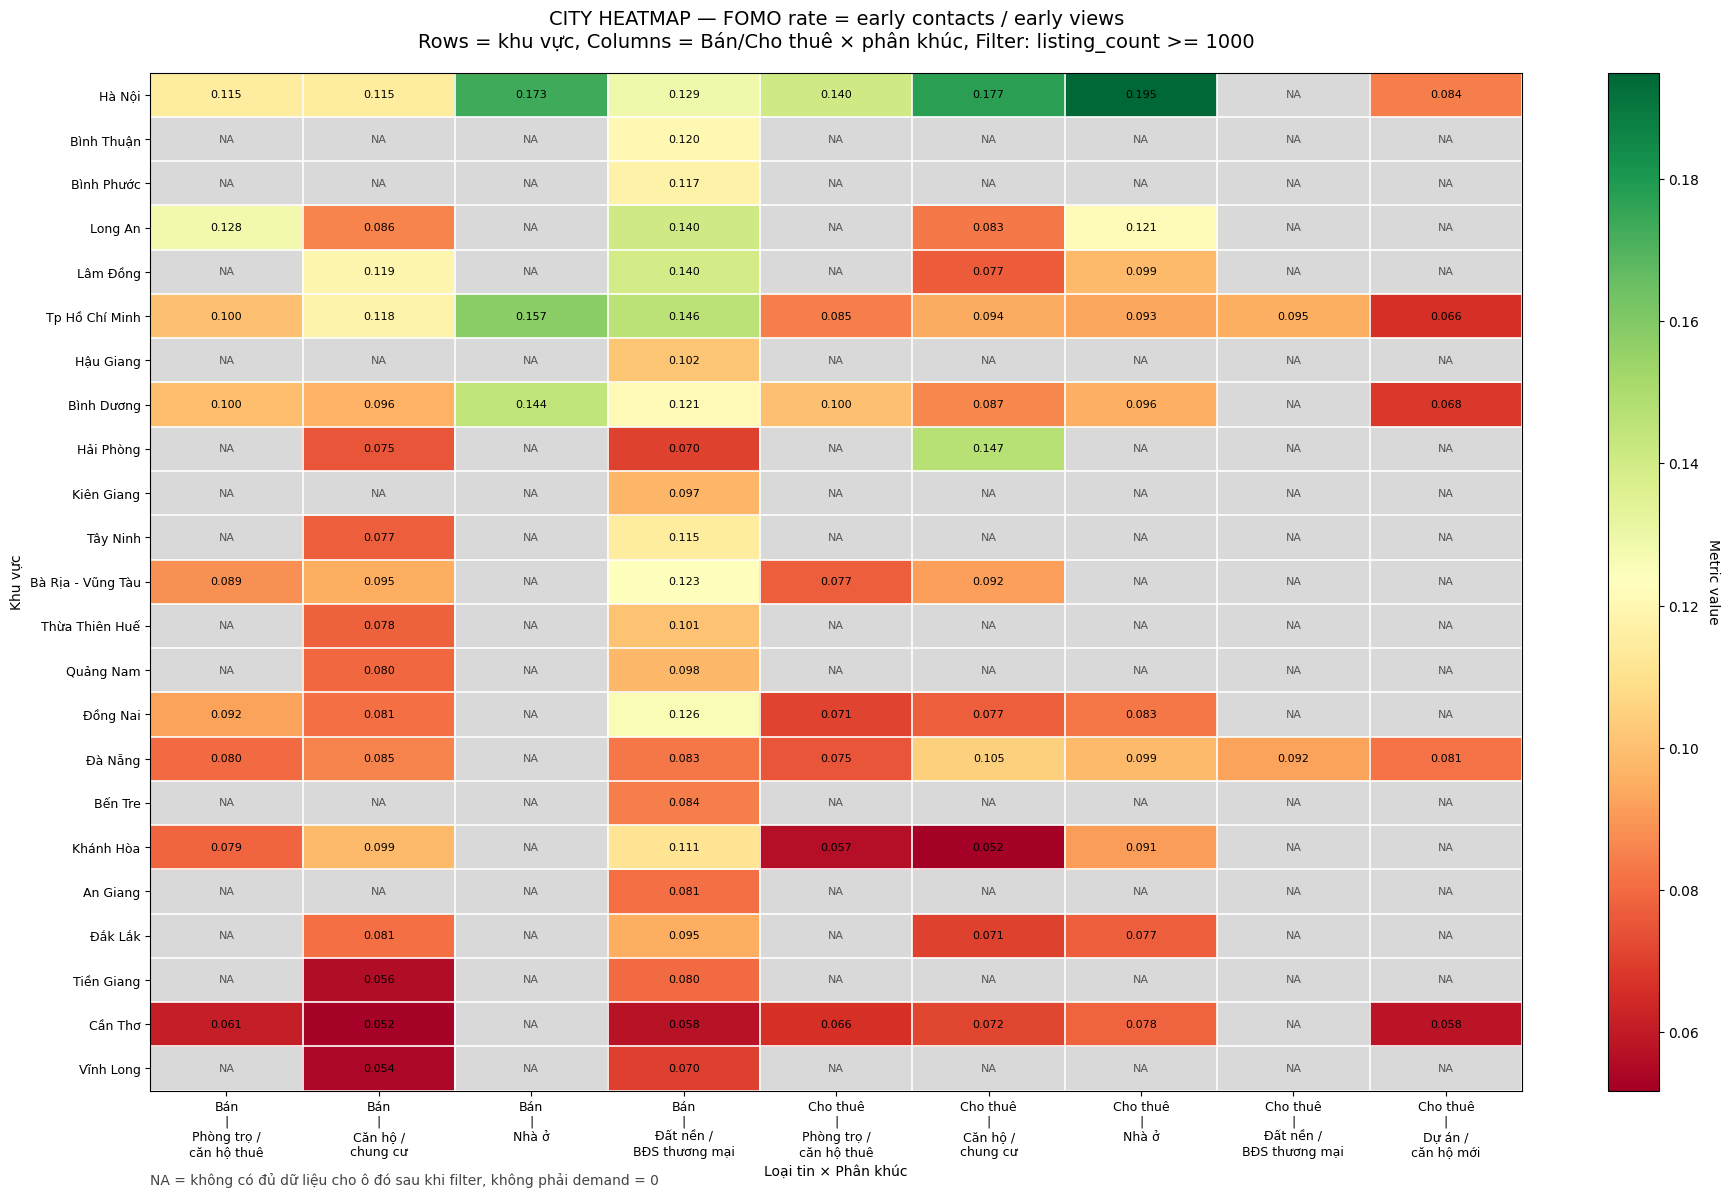

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_fomo.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_fomo_matrix.csv


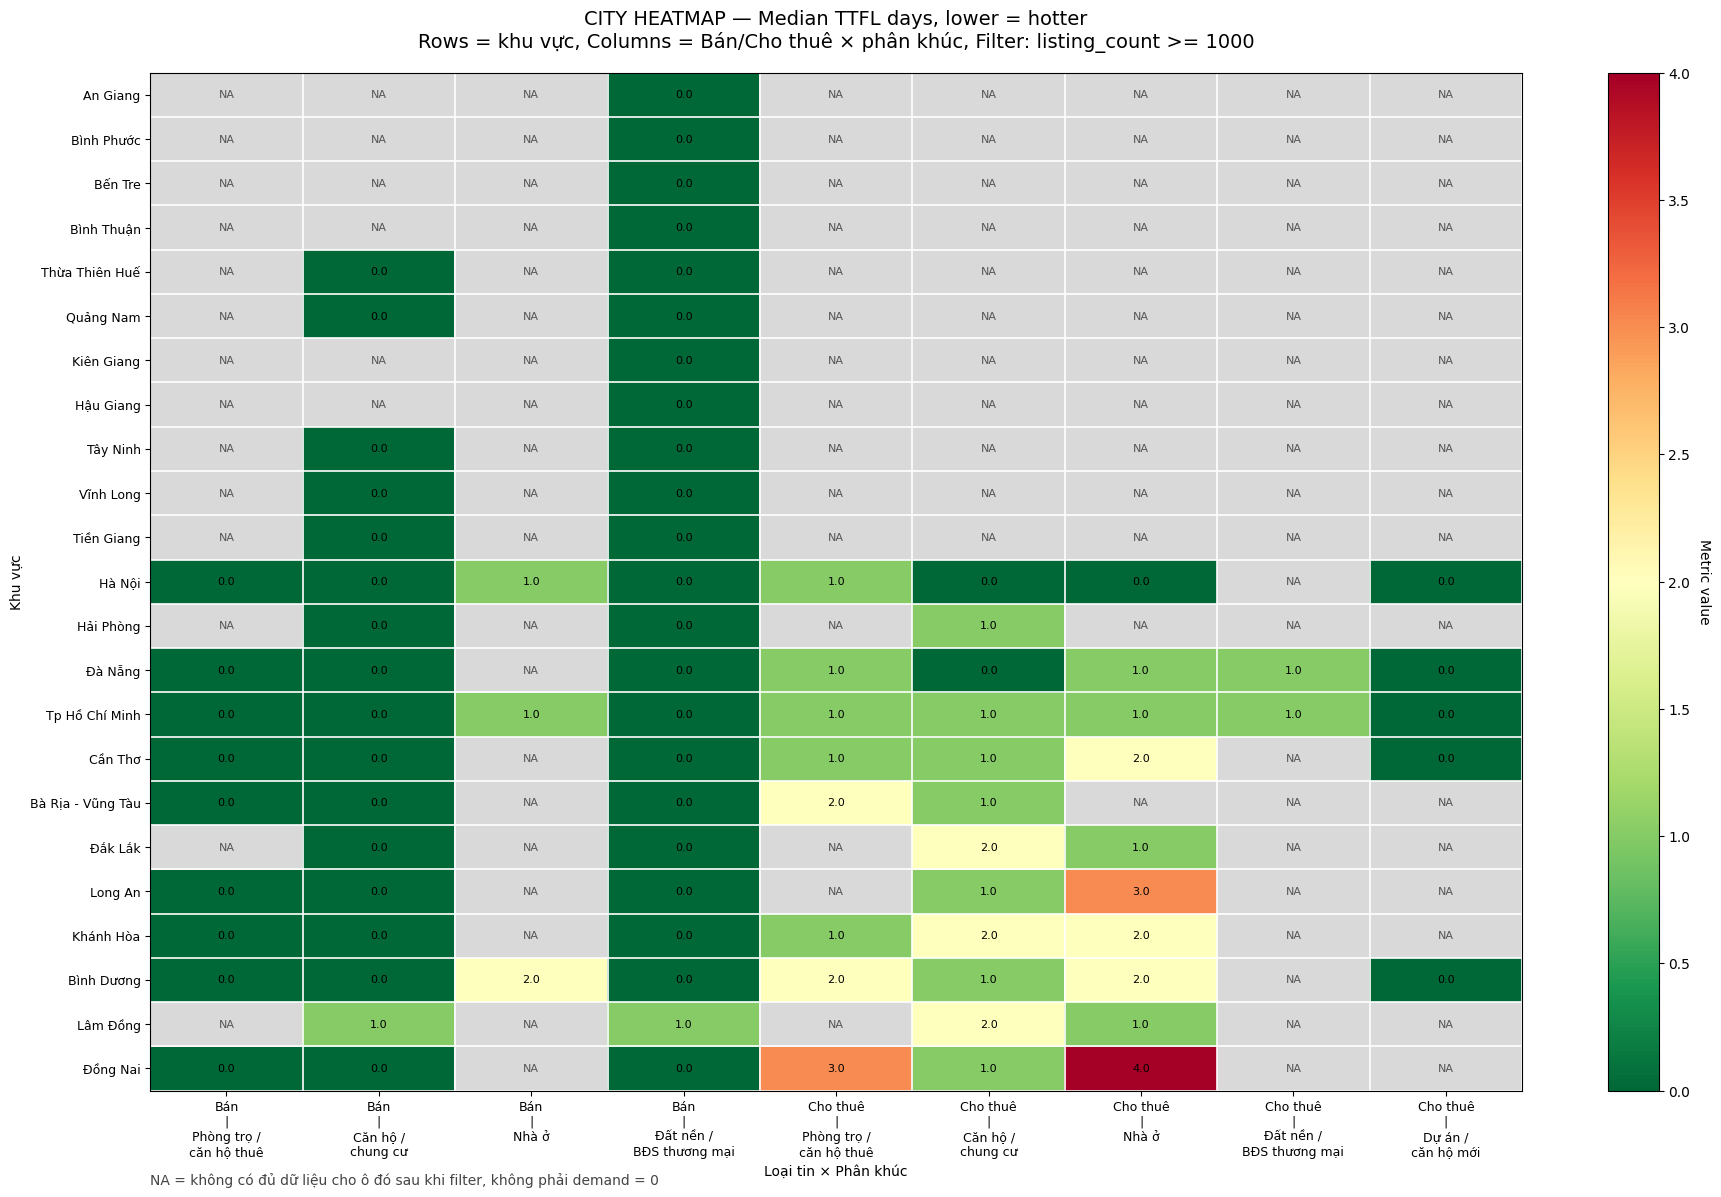

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_ttfl.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_ttfl_matrix.csv


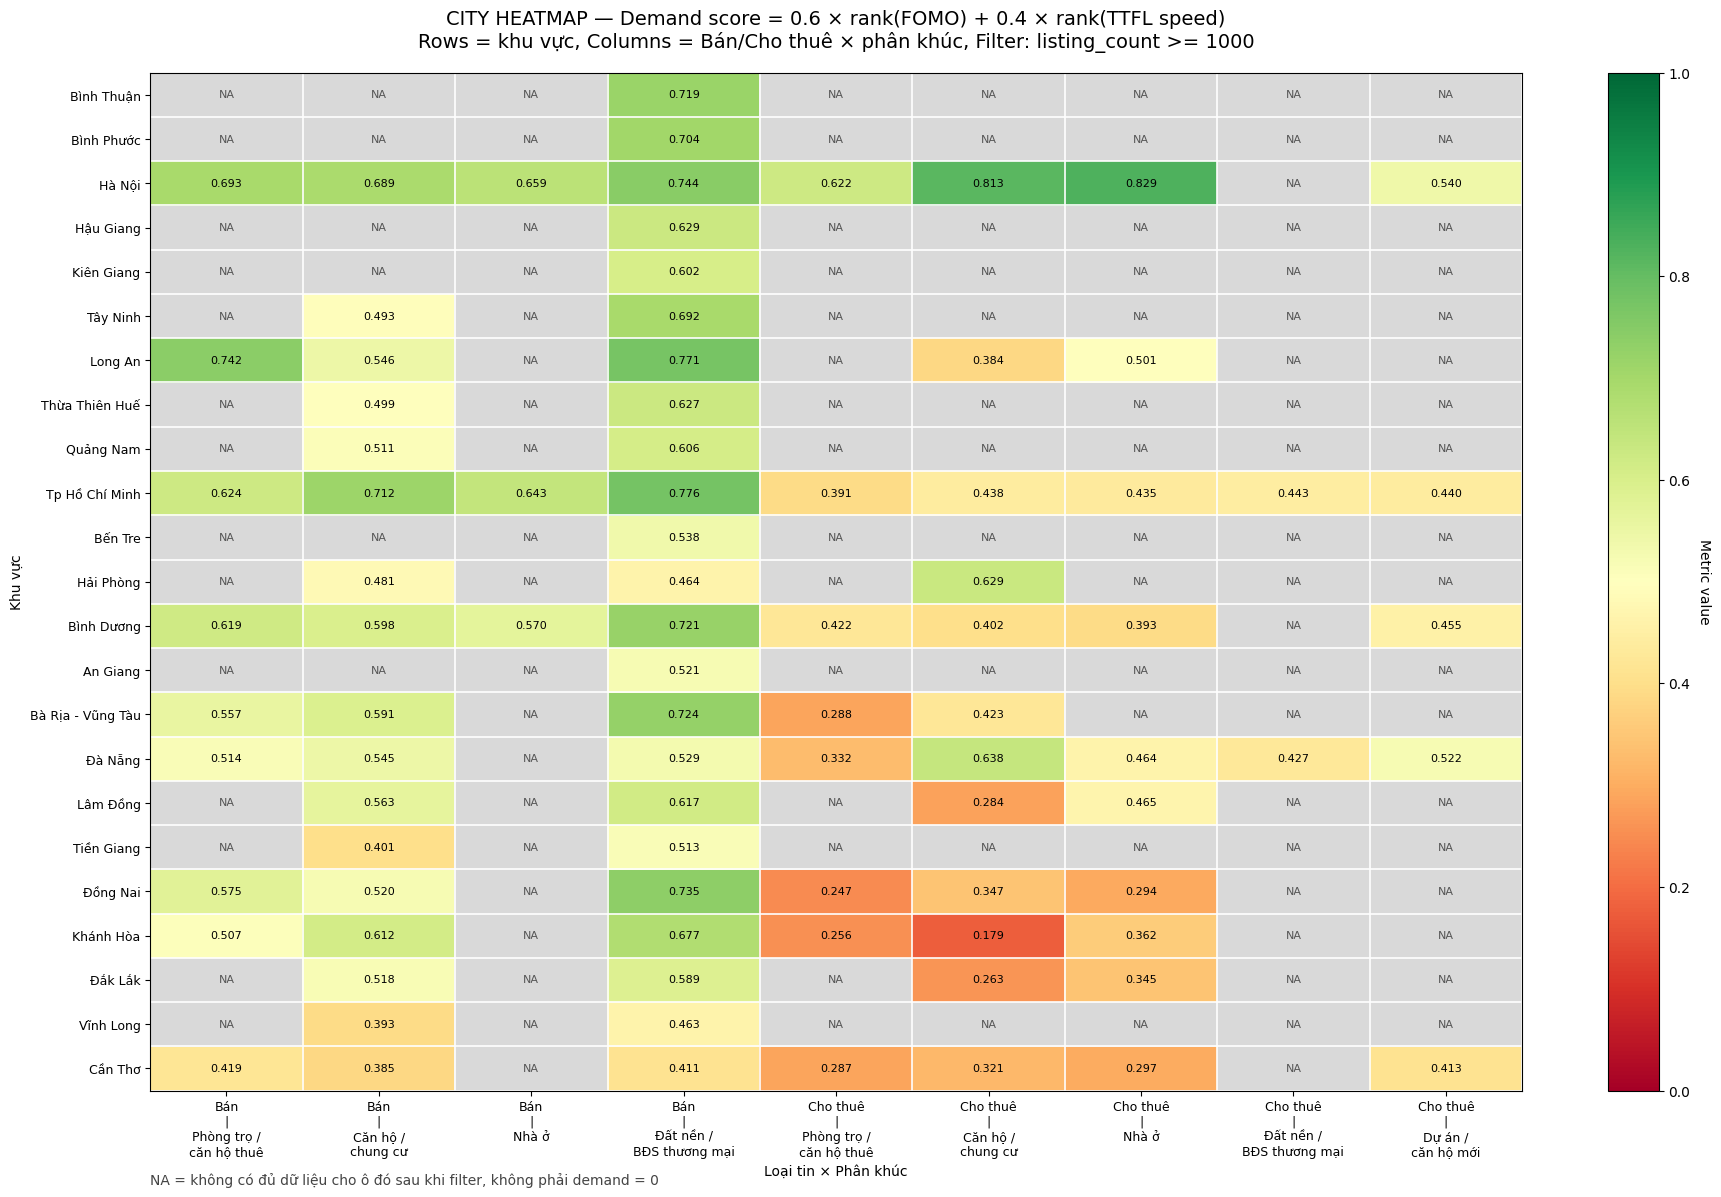

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_demand.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_demand_matrix.csv


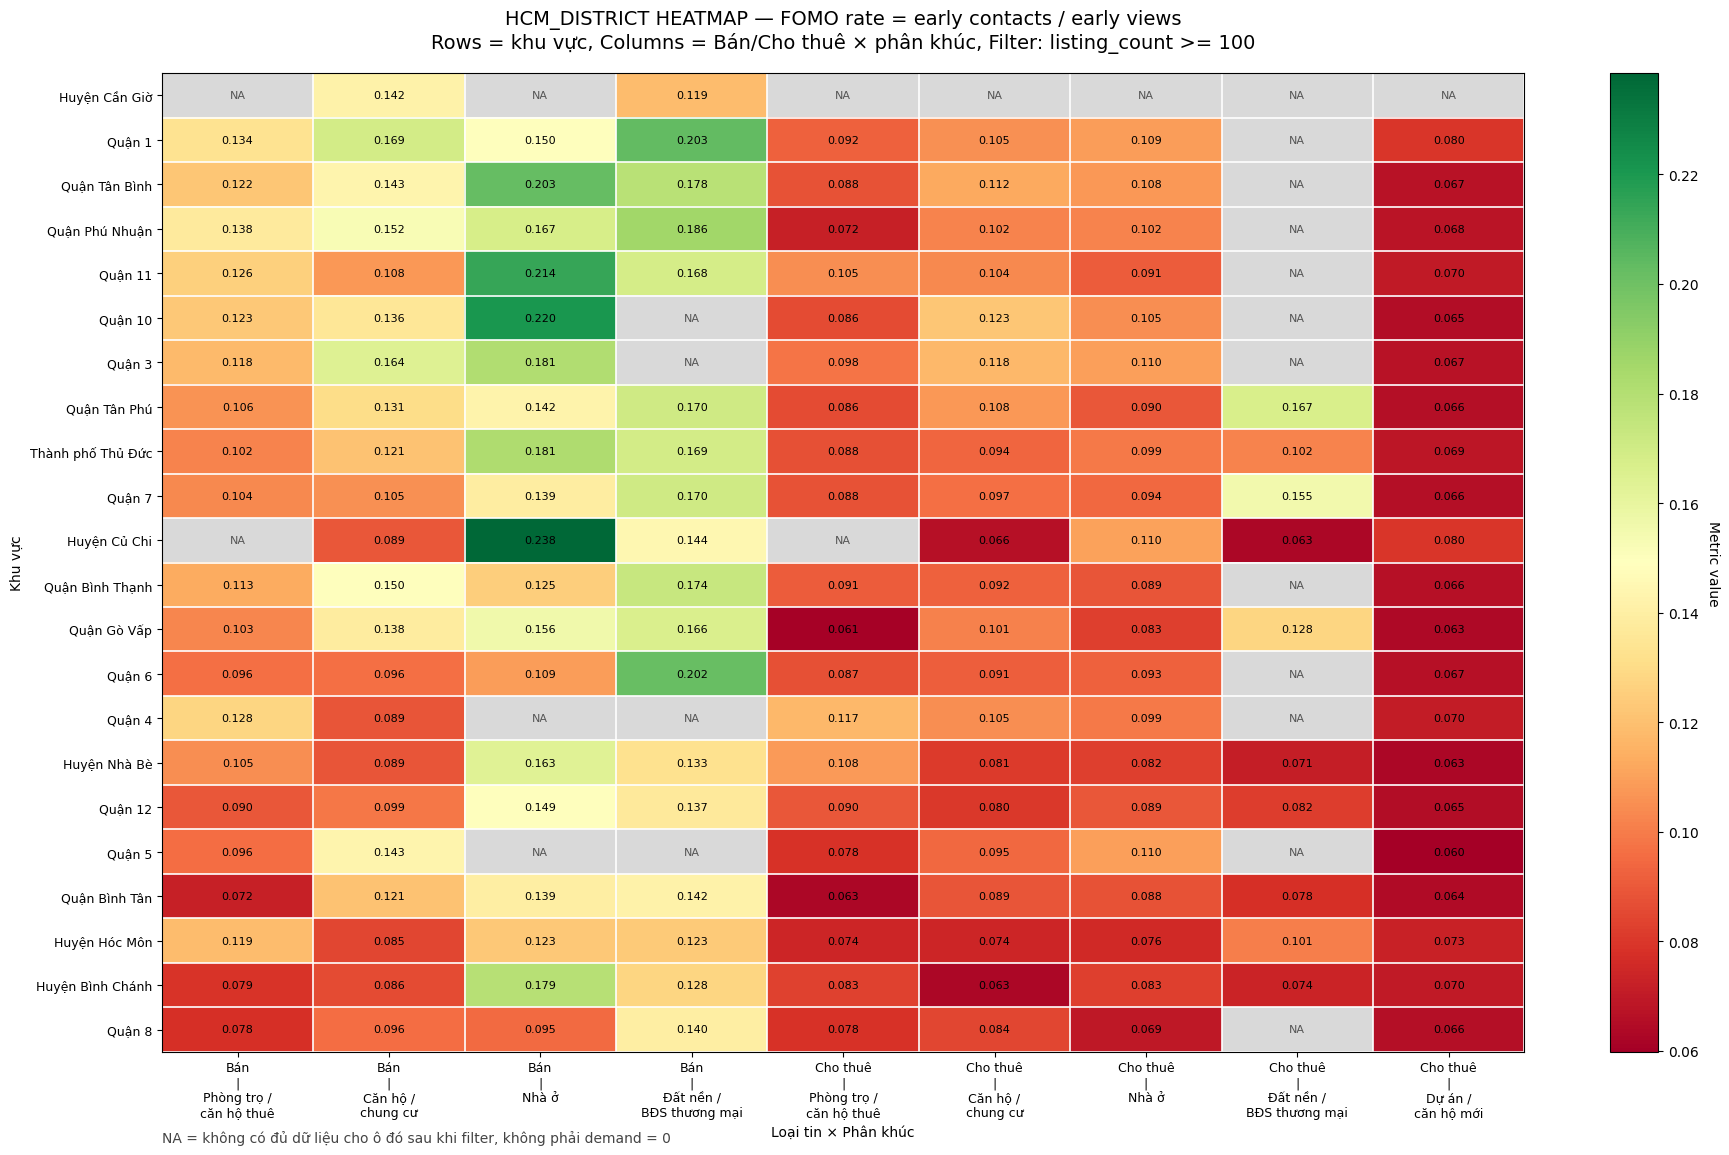

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/hcm_district_category_meaning_fomo.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/hcm_district_category_meaning_fomo_matrix.csv


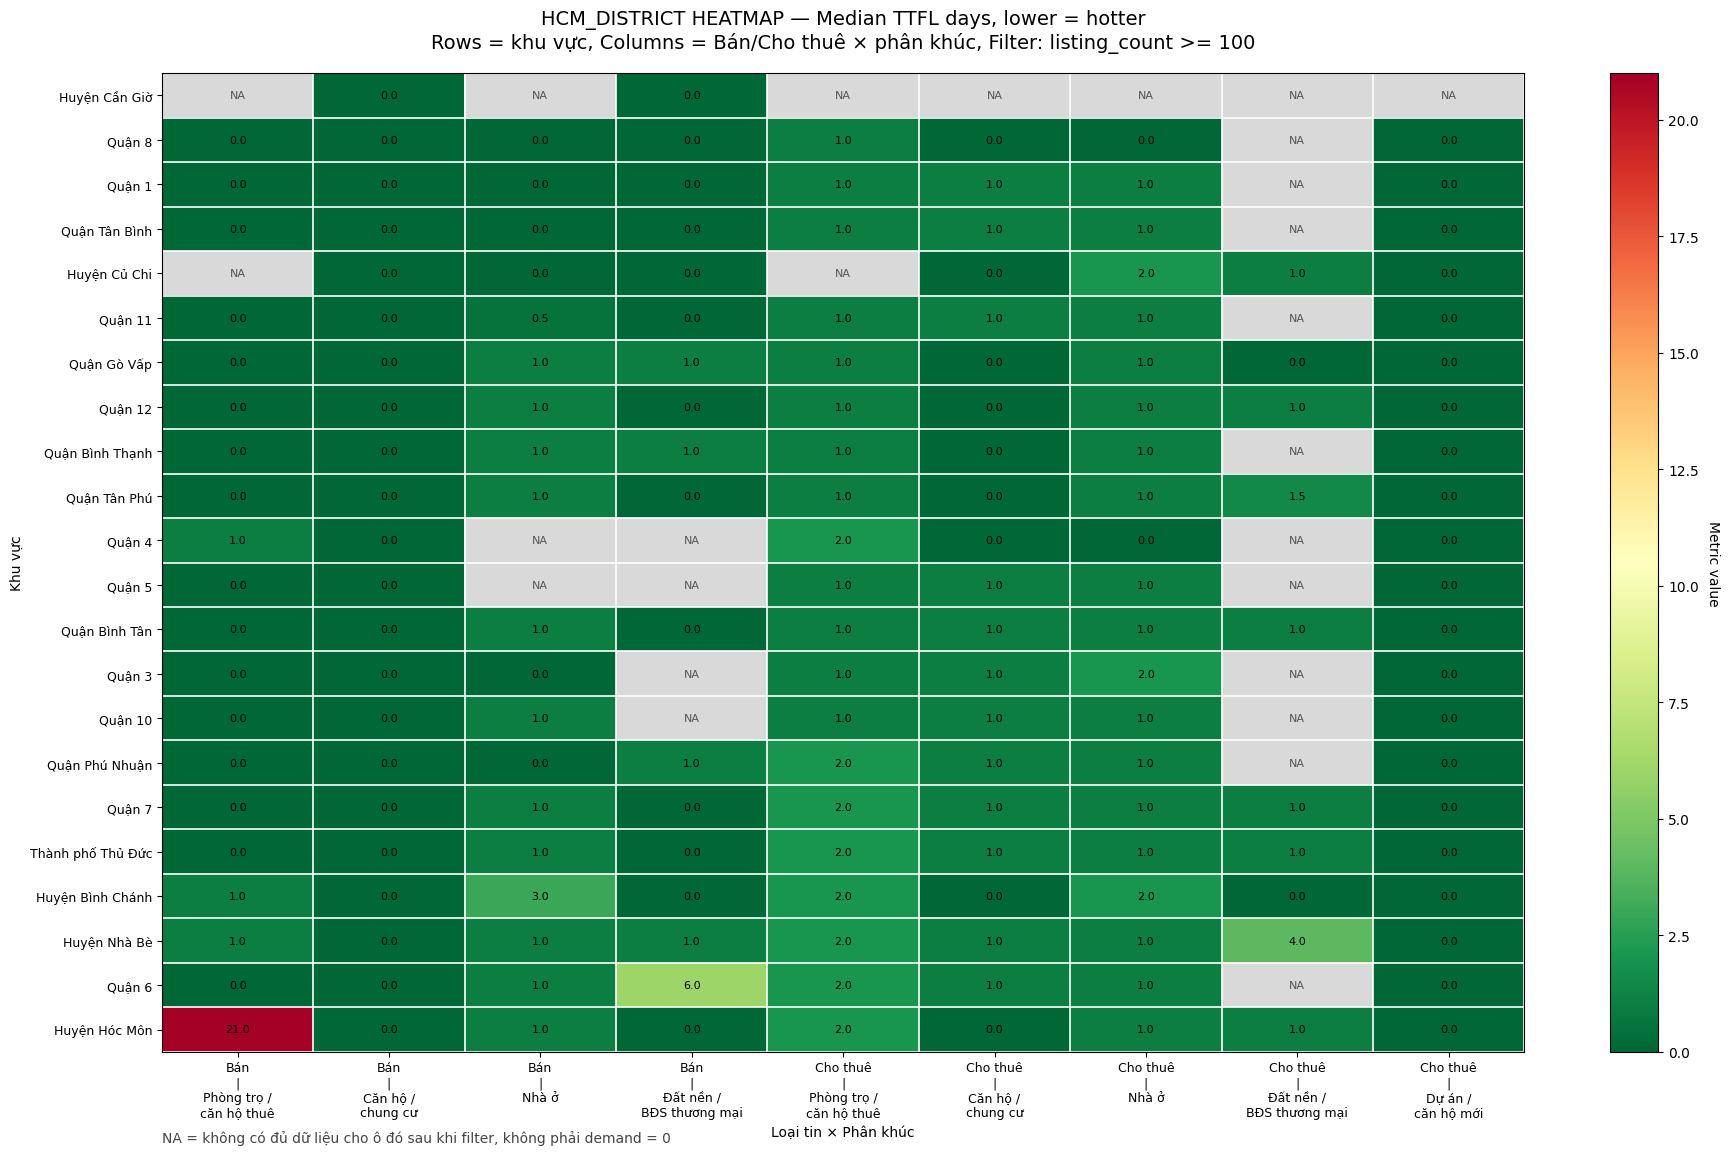

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/hcm_district_category_meaning_ttfl.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/hcm_district_category_meaning_ttfl_matrix.csv


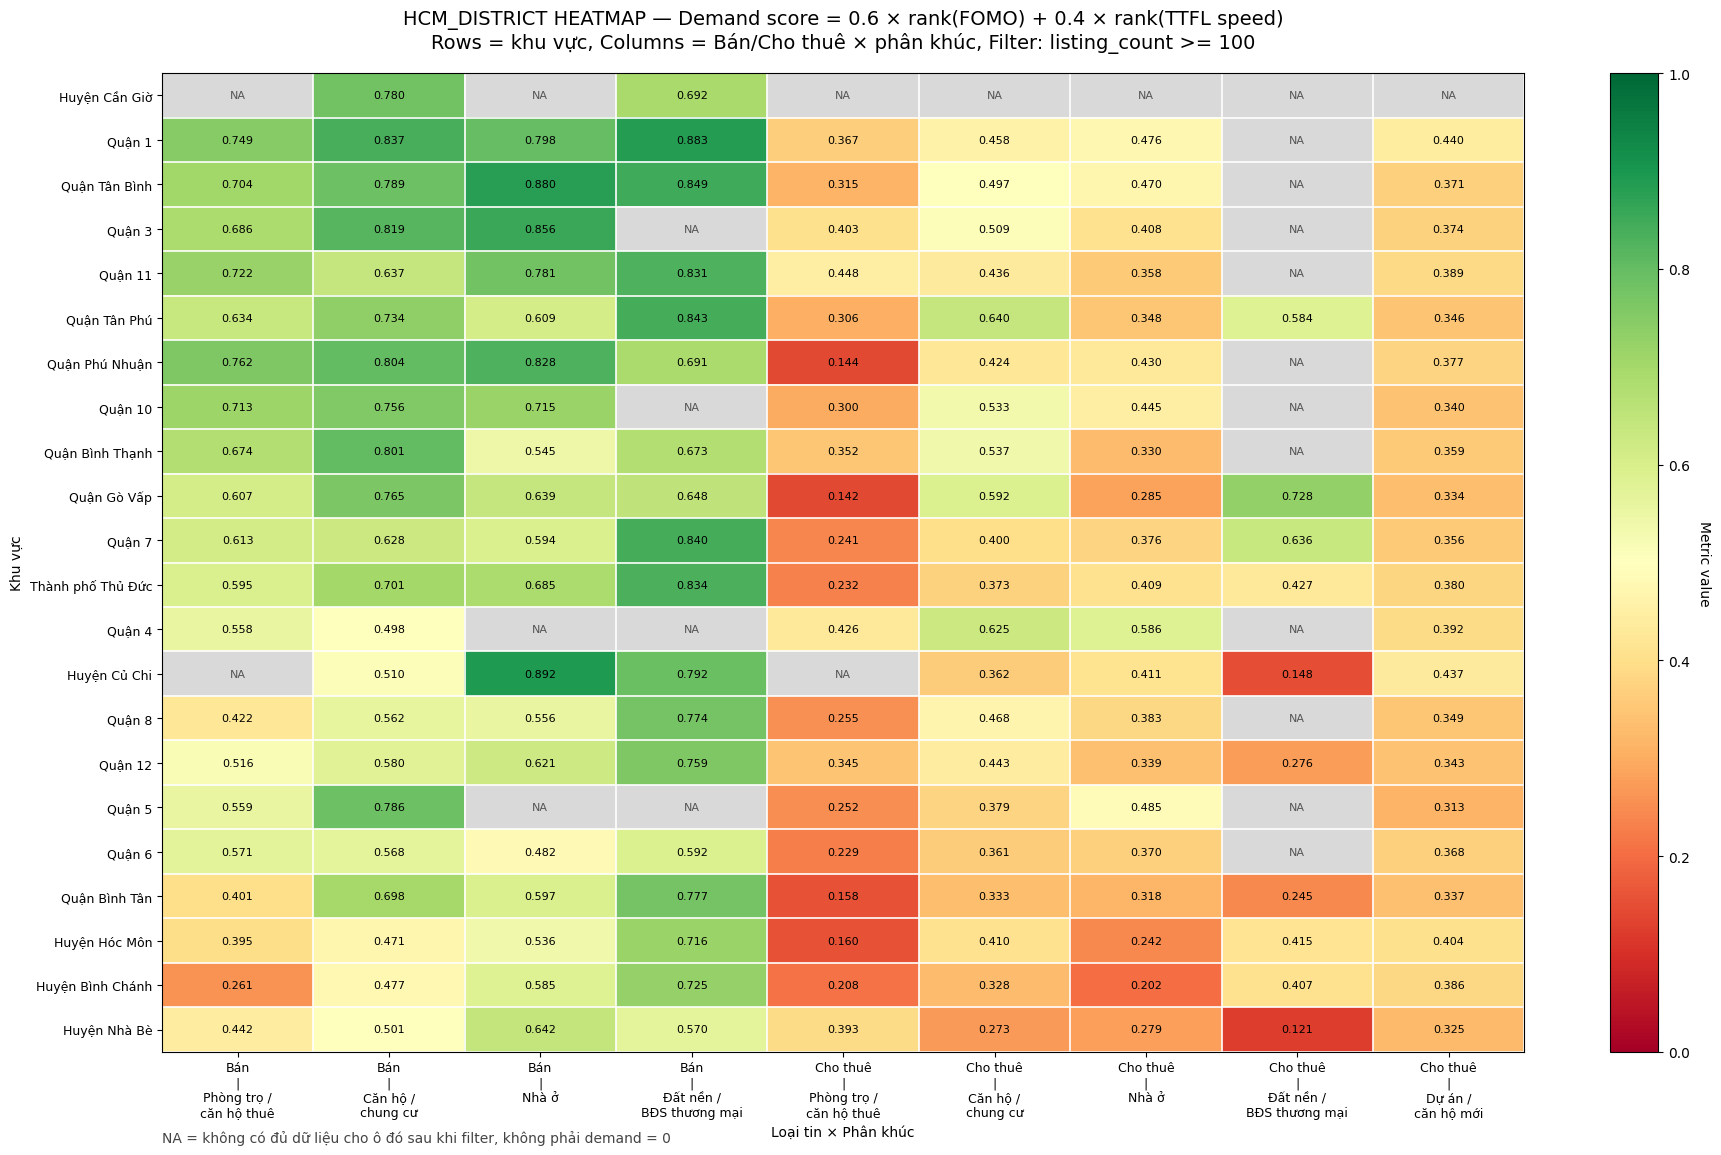

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/hcm_district_category_meaning_demand.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/hcm_district_category_meaning_demand_matrix.csv

DONE. Files saved in:
/kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_demand.png
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_demand_matrix.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_fomo.png
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_meaning_heatmaps/city_category_meaning_fomo_matrix.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps/static_full_grid_category_m

In [11]:
# ============================================================
# STATIC FULL GRID HEATMAPS — BETTER VERSION
#
# Fix:
# - White cells replaced by light gray + "NA"
# - Columns use full category meaning instead of 1010/1020/...
# - Columns = sell/let × category meaning
# - Rows = city / HCM district
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# 1. PATH CONFIG
# ============================================================

READ_CACHE_DIR = "/kaggle/input/datasets/kimkhanhnguyen214/demand-v3/demand_v3_fomo_ttfl_traffic"

OUT_DIR = "/kaggle/working/redraw_demand_fomo_ttfl_heatmaps"
os.makedirs(OUT_DIR, exist_ok=True)

STATIC_DIR = os.path.join(OUT_DIR, "static_full_grid_category_meaning_heatmaps")
os.makedirs(STATIC_DIR, exist_ok=True)

CITY_FINAL_CSV = os.path.join(
    READ_CACHE_DIR,
    "city_demand_v3_fomo_ttfl_traffic.csv"
)

HCM_FINAL_CSV = os.path.join(
    READ_CACHE_DIR,
    "hcm_district_demand_v3_fomo_ttfl_traffic.csv"
)

MIN_LISTINGS_CITY = 1000
MIN_LISTINGS_DISTRICT = 100

TOP_CITY_ROWS = 40
TOP_DISTRICT_ROWS = 35

CATEGORY_MEANING = {
    "1010": "Phòng trọ /\ncăn hộ thuê",
    "1020": "Căn hộ /\nchung cư",
    "1030": "Nhà ở",
    "1040": "Đất nền /\nBĐS thương mại",
    "1050": "Dự án /\ncăn hộ mới",
}

AD_TYPE_MEANING = {
    "sell": "Bán",
    "let": "Cho thuê",
}

# ============================================================
# 2. HELPERS
# ============================================================

def safe_div(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)


def pct_rank(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)

    if s.notna().sum() <= 1:
        return pd.Series(np.nan, index=s.index)

    if higher_is_better:
        return s.rank(pct=True, ascending=True)
    else:
        return s.rank(pct=True, ascending=False)


def normalize_ad_type(x):
    if pd.isna(x):
        return "unknown"

    x = str(x).strip().lower()

    if x in ["sell", "bán", "ban"]:
        return "sell"

    if x in ["let", "rent", "thuê", "thue"]:
        return "let"

    return x


def extract_category_code(x):
    """
    category_name thường có dạng:
    '1010 - Phòng trọ / căn hộ thuê'
    """
    if pd.isna(x):
        return "unknown"

    x = str(x).strip()

    m = re.match(r"^\s*(\d{4})", x)
    if m:
        return m.group(1)

    return x


def category_to_meaning(x):
    code = extract_category_code(x)
    return CATEGORY_MEANING.get(code, str(x))


def make_col_label(row):
    ad = normalize_ad_type(row["ad_type"])
    ad_label = AD_TYPE_MEANING.get(ad, ad)

    cate_label = category_to_meaning(row["category_name"])

    return f"{ad_label}\n|\n{cate_label}"


def enrich_metrics(df):
    df = df.copy()

    for c in [
        "listing_count",
        "early_views_24h",
        "early_contacts_24h",
        "median_ttfl_days",
        "items_with_lead",
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # FOMO
    if "fomo_early_contact_rate" not in df.columns:
        df["fomo_early_contact_rate"] = safe_div(
            df["early_contacts_24h"],
            df["early_views_24h"]
        )
    else:
        df["fomo_early_contact_rate"] = pd.to_numeric(
            df["fomo_early_contact_rate"],
            errors="coerce"
        )

    # TTFL speed
    df["ttfl_speed"] = 1 / (1 + df["median_ttfl_days"])

    # Demand score from FOMO + TTFL only
    df["score_fomo"] = pct_rank(
        df["fomo_early_contact_rate"],
        higher_is_better=True
    )

    df["score_ttfl_speed"] = pct_rank(
        df["ttfl_speed"],
        higher_is_better=True
    )

    df["demand_score_fomo_ttfl"] = (
        0.6 * df["score_fomo"]
        + 0.4 * df["score_ttfl_speed"]
    )

    df["ad_type"] = df["ad_type"].map(normalize_ad_type)
    df["category_code"] = df["category_name"].map(extract_category_code)
    df["category_meaning"] = df["category_name"].map(category_to_meaning)

    df["adtype_category_label"] = df.apply(make_col_label, axis=1)

    return df


def sort_col_labels(cols):
    """
    Sort columns:
    Bán 1010 -> 1020 -> ...
    Cho thuê 1010 -> 1020 -> ...
    """
    def key_func(col):
        col_str = str(col)

        if col_str.startswith("Bán"):
            ad_order = 0
        elif col_str.startswith("Cho thuê"):
            ad_order = 1
        else:
            ad_order = 9

        # Detect category order from Vietnamese label
        if "Phòng trọ" in col_str:
            cate_order = 1010
        elif "Căn hộ" in col_str and "chung cư" in col_str:
            cate_order = 1020
        elif "Nhà ở" in col_str:
            cate_order = 1030
        elif "Đất nền" in col_str:
            cate_order = 1040
        elif "Dự án" in col_str:
            cate_order = 1050
        else:
            cate_order = 9999

        return (ad_order, cate_order)

    return sorted(cols, key=key_func)


def make_full_grid_pivot(df, geo_col, metric, top_n=None):
    tmp = df.copy()

    pivot = tmp.pivot_table(
        index=geo_col,
        columns="adtype_category_label",
        values=metric,
        aggfunc="mean"
    )

    pivot = pivot.reindex(columns=sort_col_labels(pivot.columns))

    row_mean = pivot.mean(axis=1)

    if metric == "median_ttfl_days":
        # TTFL lower is better
        pivot = pivot.loc[row_mean.sort_values(ascending=True).index]
    else:
        pivot = pivot.loc[row_mean.sort_values(ascending=False).index]

    if top_n is not None:
        pivot = pivot.head(top_n)

    return pivot


def plot_static_heatmap(
    pivot,
    title,
    filename,
    fmt=".3f",
    higher_is_better=True,
    vmin=None,
    vmax=None,
    annotate=True,
):
    if pivot.empty:
        print("[SKIP] Empty pivot:", filename)
        return

    data = pivot.values.astype(float)

    n_rows, n_cols = data.shape

    fig_w = max(14, 1.65 * n_cols + 4)
    fig_h = max(7, 0.40 * n_rows + 2.8)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # IMPORTANT:
    # NaN/missing cells will be light gray instead of white.
    base_cmap = plt.cm.RdYlGn if higher_is_better else plt.cm.RdYlGn_r
    cmap = base_cmap.copy()
    cmap.set_bad(color="#d9d9d9")

    masked_data = np.ma.masked_invalid(data)

    im = ax.imshow(
        masked_data,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title, fontsize=14, pad=18)
    ax.set_xlabel("Loại tin × Phân khúc")
    ax.set_ylabel("Khu vực")

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(pivot.columns, rotation=0, ha="center", fontsize=9)

    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(pivot.index, fontsize=9)

    # grid lines
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    if annotate:
        for i in range(n_rows):
            for j in range(n_cols):
                val = data[i, j]

                if np.isfinite(val):
                    text = format(val, fmt)
                    color = "black"
                else:
                    text = "NA"
                    color = "#555555"

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=color
                )

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Metric value", rotation=270, labelpad=15)

    # Add small note
    ax.text(
        0,
        -0.08,
        "NA = không có đủ dữ liệu cho ô đó sau khi filter, không phải demand = 0",
        transform=ax.transAxes,
        fontsize=10,
        color="#444444",
        ha="left",
        va="top"
    )

    plt.tight_layout()

    out_path = os.path.join(STATIC_DIR, filename)
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print("[SAVED]", out_path)


def draw_geo_full_grid_heatmaps(
    df,
    geo_col,
    geo_name,
    min_listings,
    top_n,
):
    df = df.copy()

    # only reliable cells
    df = df[df["listing_count"] >= min_listings].copy()

    # only sell / let
    df = df[df["ad_type"].isin(["sell", "let"])].copy()

    if len(df) == 0:
        print("[SKIP] No rows:", geo_name)
        return

    configs = [
        {
            "metric": "fomo_early_contact_rate",
            "name": "fomo",
            "title": "FOMO rate = early contacts / early views",
            "fmt": ".3f",
            "higher_is_better": True,
            "vmin": None,
            "vmax": None,
        },
        {
            "metric": "median_ttfl_days",
            "name": "ttfl",
            "title": "Median TTFL days, lower = hotter",
            "fmt": ".1f",
            "higher_is_better": False,
            "vmin": None,
            "vmax": None,
        },
        {
            "metric": "demand_score_fomo_ttfl",
            "name": "demand",
            "title": "Demand score = 0.6 × rank(FOMO) + 0.4 × rank(TTFL speed)",
            "fmt": ".3f",
            "higher_is_better": True,
            "vmin": 0,
            "vmax": 1,
        },
    ]

    for cfg in configs:
        pivot = make_full_grid_pivot(
            df=df,
            geo_col=geo_col,
            metric=cfg["metric"],
            top_n=top_n
        )

        title = (
            f"{geo_name.upper()} HEATMAP — {cfg['title']}\n"
            f"Rows = khu vực, Columns = Bán/Cho thuê × phân khúc, "
            f"Filter: listing_count >= {min_listings}"
        )

        filename = f"{geo_name.lower()}_category_meaning_{cfg['name']}.png"

        plot_static_heatmap(
            pivot=pivot,
            title=title,
            filename=filename,
            fmt=cfg["fmt"],
            higher_is_better=cfg["higher_is_better"],
            vmin=cfg["vmin"],
            vmax=cfg["vmax"],
            annotate=True,
        )

        matrix_path = os.path.join(
            STATIC_DIR,
            f"{geo_name.lower()}_category_meaning_{cfg['name']}_matrix.csv"
        )
        pivot.to_csv(matrix_path)
        print("[SAVED]", matrix_path)


# ============================================================
# 3. LOAD DATA
# ============================================================

city = pd.read_csv(CITY_FINAL_CSV)
city = enrich_metrics(city)

hcm = pd.read_csv(HCM_FINAL_CSV)
hcm = enrich_metrics(hcm)

hcm = hcm[
    ~hcm["district_name"].astype(str).isin(["Unknown District", "Unmapped Item"])
].copy()

print("city shape:", city.shape)
print("hcm shape:", hcm.shape)

print("\nCategory labels used:")
for k, v in CATEGORY_MEANING.items():
    print(k, "=>", v.replace("\n", " "))

# ============================================================
# 4. DRAW HEATMAPS
# ============================================================

draw_geo_full_grid_heatmaps(
    df=city,
    geo_col="city_name",
    geo_name="city",
    min_listings=MIN_LISTINGS_CITY,
    top_n=TOP_CITY_ROWS,
)

draw_geo_full_grid_heatmaps(
    df=hcm,
    geo_col="district_name",
    geo_name="hcm_district",
    min_listings=MIN_LISTINGS_DISTRICT,
    top_n=TOP_DISTRICT_ROWS,
)

# ============================================================
# 5. OUTPUT
# ============================================================

print("\nDONE. Files saved in:")
print(STATIC_DIR)

for f in sorted(os.listdir(STATIC_DIR)):
    print("-", os.path.join(STATIC_DIR, f))

In [4]:
# ============================================================
# RULE-BASED DEMAND HEATMAP
#
# No weighted score.
#
# Rule idea:
# - FOMO high  = early contact rate high enough
# - TTFL low   = first lead comes fast enough
#
# HOT DEMAND = FOMO high AND TTFL low
#
# Rows    = city / HCM district
# Columns = Bán/Cho thuê × category meaning
# Values  = rule-based demand segment
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ============================================================
# 1. PATH CONFIG
# ============================================================

READ_CACHE_DIR = "/kaggle/input/notebooks/kimkhanhnguyen214/cung-cau/demand_v3_fomo_ttfl_traffic"

OUT_DIR = "/kaggle/working/rule_based_demand_heatmaps"
os.makedirs(OUT_DIR, exist_ok=True)

CITY_FINAL_CSV = os.path.join(
    READ_CACHE_DIR,
    "city_demand_v3_fomo_ttfl_traffic.csv"
)

HCM_FINAL_CSV = os.path.join(
    READ_CACHE_DIR,
    "hcm_district_demand_v3_fomo_ttfl_traffic.csv"
)

# ============================================================
# 2. RULE CONFIG
# ============================================================

# Lọc ô quá nhỏ để tránh insight ảo
MIN_LISTINGS_CITY = 500
MIN_LISTINGS_HCM  = 200

MIN_EARLY_VIEWS = 300
MIN_ITEMS_WITH_LEAD = 20

TOP_CITY_ROWS = 40
TOP_HCM_ROWS  = 35

# Cách set threshold:
# True  = tự lấy threshold bằng percentile trong data sau filter
# False = dùng ngưỡng manual bên dưới
USE_QUANTILE_RULE = True

# Nếu dùng quantile:
# FOMO high = top 33%
# TTFL low  = fastest 33%
FOMO_HIGH_Q = 0.67
TTFL_LOW_Q  = 0.33

# Nếu muốn manual thì set USE_QUANTILE_RULE = False
MANUAL_FOMO_HIGH = 0.08
MANUAL_TTFL_LOW_DAYS = 3.0

CATEGORY_MEANING = {
    "1010": "Phòng trọ /\ncăn hộ thuê",
    "1020": "Căn hộ /\nchung cư",
    "1030": "Nhà ở",
    "1040": "Đất nền /\nBĐS thương mại",
    "1050": "Dự án /\ncăn hộ mới",
}

AD_TYPE_MEANING = {
    "sell": "Bán",
    "let": "Cho thuê",
}

# ============================================================
# 3. HELPERS
# ============================================================

def safe_div(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)


def normalize_ad_type(x):
    if pd.isna(x):
        return "unknown"

    x = str(x).strip().lower()

    if x in ["sell", "bán", "ban"]:
        return "sell"

    if x in ["let", "rent", "thuê", "thue"]:
        return "let"

    return x


def extract_category_code(x):
    if pd.isna(x):
        return "unknown"

    x = str(x).strip()
    m = re.match(r"^\s*(\d{4})", x)

    if m:
        return m.group(1)

    return x


def category_to_meaning(x):
    code = extract_category_code(x)
    return CATEGORY_MEANING.get(code, str(x))


def make_col_label(row):
    ad = normalize_ad_type(row["ad_type"])
    ad_label = AD_TYPE_MEANING.get(ad, ad)

    cate_label = category_to_meaning(row["category_name"])

    return f"{ad_label}\n|\n{cate_label}"


def sort_col_labels(cols):
    def key_func(col):
        col = str(col)

        if col.startswith("Bán"):
            ad_order = 0
        elif col.startswith("Cho thuê"):
            ad_order = 1
        else:
            ad_order = 9

        if "Phòng trọ" in col:
            cate_order = 1010
        elif "Căn hộ" in col and "chung cư" in col:
            cate_order = 1020
        elif "Nhà ở" in col:
            cate_order = 1030
        elif "Đất nền" in col:
            cate_order = 1040
        elif "Dự án" in col:
            cate_order = 1050
        else:
            cate_order = 9999

        return (ad_order, cate_order)

    return sorted(cols, key=key_func)


def enrich_base_metrics(df):
    df = df.copy()

    for c in [
        "listing_count",
        "early_views_24h",
        "early_contacts_24h",
        "items_with_lead",
        "median_ttfl_days",
        "mean_ttfl_days",
        "p25_ttfl_days",
        "p75_ttfl_days",
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["ad_type"] = df["ad_type"].map(normalize_ad_type)
    df["category_code"] = df["category_name"].map(extract_category_code)
    df["category_meaning"] = df["category_name"].map(category_to_meaning)
    df["adtype_category_label"] = df.apply(make_col_label, axis=1)

    # FOMO
    if "fomo_early_contact_rate" not in df.columns:
        df["fomo_early_contact_rate"] = safe_div(
            df["early_contacts_24h"],
            df["early_views_24h"]
        )
    else:
        df["fomo_early_contact_rate"] = pd.to_numeric(
            df["fomo_early_contact_rate"],
            errors="coerce"
        )

    return df


def add_rule_based_demand(
    df,
    min_listings,
    min_early_views,
    min_items_with_lead,
    use_quantile=True,
    fomo_high_q=0.67,
    ttfl_low_q=0.33,
    manual_fomo_high=0.08,
    manual_ttfl_low_days=3.0,
):
    df = df.copy()

    # Eligible = đủ data để tin rule
    df["rule_eligible"] = (
        (df["listing_count"].fillna(0) >= min_listings)
        & (df["early_views_24h"].fillna(0) >= min_early_views)
        & (df["items_with_lead"].fillna(0) >= min_items_with_lead)
        & (df["fomo_early_contact_rate"].notna())
        & (df["median_ttfl_days"].notna())
    )

    valid = df[df["rule_eligible"]].copy()

    if len(valid) == 0:
        df["fomo_threshold"] = np.nan
        df["ttfl_threshold"] = np.nan
        df["is_fomo_high"] = False
        df["is_ttfl_low"] = False
        df["demand_rule_segment"] = "Not enough data"
        df["demand_rule_code"] = np.nan
        return df, np.nan, np.nan

    if use_quantile:
        fomo_threshold = valid["fomo_early_contact_rate"].quantile(fomo_high_q)
        ttfl_threshold = valid["median_ttfl_days"].quantile(ttfl_low_q)
    else:
        fomo_threshold = manual_fomo_high
        ttfl_threshold = manual_ttfl_low_days

    df["fomo_threshold"] = fomo_threshold
    df["ttfl_threshold"] = ttfl_threshold

    df["is_fomo_high"] = (
        df["rule_eligible"]
        & (df["fomo_early_contact_rate"] >= fomo_threshold)
    )

    df["is_ttfl_low"] = (
        df["rule_eligible"]
        & (df["median_ttfl_days"] <= ttfl_threshold)
    )

    def label(row):
        if not row["rule_eligible"]:
            return "Not enough data"

        fomo = row["is_fomo_high"]
        ttfl = row["is_ttfl_low"]

        if fomo and ttfl:
            return "HOT: high FOMO + fast TTFL"

        if fomo and not ttfl:
            return "High FOMO but slow TTFL"

        if (not fomo) and ttfl:
            return "Fast TTFL but weak FOMO"

        return "Cold / weak demand"

    df["demand_rule_segment"] = df.apply(label, axis=1)

    code_map = {
        "Not enough data": np.nan,
        "Cold / weak demand": 0,
        "Fast TTFL but weak FOMO": 1,
        "High FOMO but slow TTFL": 2,
        "HOT: high FOMO + fast TTFL": 3,
    }

    df["demand_rule_code"] = df["demand_rule_segment"].map(code_map)

    return df, fomo_threshold, ttfl_threshold


def make_pivot(df, geo_col, value_col):
    pivot = df.pivot_table(
        index=geo_col,
        columns="adtype_category_label",
        values=value_col,
        aggfunc="mean"
    )

    pivot = pivot.reindex(columns=sort_col_labels(pivot.columns))

    # Sort rows by hotness:
    # For rule code: high is hot.
    # For fomo: high is hot.
    # For ttfl: low is hot.
    if value_col == "median_ttfl_days":
        row_metric = pivot.mean(axis=1)
        pivot = pivot.loc[row_metric.sort_values(ascending=True).index]
    else:
        row_metric = pivot.mean(axis=1)
        pivot = pivot.loc[row_metric.sort_values(ascending=False).index]

    return pivot


def plot_rule_heatmap(pivot, title, filename):
    if pivot.empty:
        print("[SKIP] Empty pivot:", filename)
        return

    data = pivot.values.astype(float)
    masked = np.ma.masked_invalid(data)

    # 0 cold, 1 fast only, 2 fomo only, 3 hot
    colors = [
        "#d73027",  # 0 Cold - red
        "#fee08b",  # 1 Fast TTFL only - yellow
        "#91bfdb",  # 2 High FOMO only - blue
        "#1a9850",  # 3 Hot - green
    ]

    cmap = mcolors.ListedColormap(colors)
    cmap.set_bad(color="#d9d9d9")

    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    n_rows, n_cols = data.shape

    fig_w = max(14, 1.65 * n_cols + 4)
    fig_h = max(7, 0.42 * n_rows + 3)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(
        masked,
        aspect="auto",
        cmap=cmap,
        norm=norm
    )

    ax.set_title(title, fontsize=14, pad=18)
    ax.set_xlabel("Loại tin × Phân khúc")
    ax.set_ylabel("Khu vực")

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(pivot.columns, rotation=0, ha="center", fontsize=9)

    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(pivot.index, fontsize=9)

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    label_by_code = {
        0: "Cold",
        1: "Fast\nTTFL only",
        2: "High\nFOMO only",
        3: "HOT",
    }

    for i in range(n_rows):
        for j in range(n_cols):
            val = data[i, j]

            if np.isfinite(val):
                code = int(round(val))
                text = label_by_code.get(code, str(code))
                color = "black"
            else:
                text = "NA"
                color = "#555555"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=7,
                color=color
            )

    legend_items = [
        mpatches.Patch(color="#1a9850", label="HOT: FOMO cao + TTFL nhanh"),
        mpatches.Patch(color="#91bfdb", label="FOMO cao nhưng TTFL chậm"),
        mpatches.Patch(color="#fee08b", label="TTFL nhanh nhưng FOMO yếu"),
        mpatches.Patch(color="#d73027", label="Cầu yếu / cold"),
        mpatches.Patch(color="#d9d9d9", label="NA / không đủ dữ liệu"),
    ]

    ax.legend(
        handles=legend_items,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        title="Rule segment"
    )

    ax.text(
        0,
        -0.08,
        "Rule: HOT nếu FOMO >= threshold và TTFL <= threshold. NA = không đủ dữ liệu sau filter.",
        transform=ax.transAxes,
        fontsize=10,
        color="#444444",
        ha="left",
        va="top"
    )

    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print("[SAVED]", out_path)


def plot_numeric_heatmap(
    pivot,
    title,
    filename,
    fmt=".3f",
    higher_is_better=True,
    vmin=None,
    vmax=None,
):
    if pivot.empty:
        print("[SKIP] Empty pivot:", filename)
        return

    data = pivot.values.astype(float)
    masked = np.ma.masked_invalid(data)

    base_cmap = plt.cm.RdYlGn if higher_is_better else plt.cm.RdYlGn_r
    cmap = base_cmap.copy()
    cmap.set_bad(color="#d9d9d9")

    n_rows, n_cols = data.shape

    fig_w = max(14, 1.65 * n_cols + 4)
    fig_h = max(7, 0.42 * n_rows + 3)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(
        masked,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title, fontsize=14, pad=18)
    ax.set_xlabel("Loại tin × Phân khúc")
    ax.set_ylabel("Khu vực")

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(pivot.columns, rotation=0, ha="center", fontsize=9)

    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(pivot.index, fontsize=9)

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(n_rows):
        for j in range(n_cols):
            val = data[i, j]

            if np.isfinite(val):
                text = format(val, fmt)
            else:
                text = "NA"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
                color="black" if np.isfinite(val) else "#555555"
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Metric value", rotation=270, labelpad=15)

    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print("[SAVED]", out_path)


def build_rule_tables_and_heatmaps(
    df,
    geo_col,
    geo_name,
    min_listings,
    top_n,
):
    df = df.copy()

    df = df[df["ad_type"].isin(["sell", "let"])].copy()

    df, fomo_thr, ttfl_thr = add_rule_based_demand(
        df=df,
        min_listings=min_listings,
        min_early_views=MIN_EARLY_VIEWS,
        min_items_with_lead=MIN_ITEMS_WITH_LEAD,
        use_quantile=USE_QUANTILE_RULE,
        fomo_high_q=FOMO_HIGH_Q,
        ttfl_low_q=TTFL_LOW_Q,
        manual_fomo_high=MANUAL_FOMO_HIGH,
        manual_ttfl_low_days=MANUAL_TTFL_LOW_DAYS,
    )

    print("\n" + "=" * 100)
    print(f"{geo_name.upper()} RULE THRESHOLDS")
    print("=" * 100)
    print("FOMO threshold:", fomo_thr)
    print("TTFL threshold:", ttfl_thr)
    print("HOT rule: fomo_early_contact_rate >= threshold AND median_ttfl_days <= threshold")

    # Save full table
    full_path = os.path.join(OUT_DIR, f"{geo_name.lower()}_rule_based_demand_table.csv")
    df.to_csv(full_path, index=False)
    print("[SAVED]", full_path)

    # Display hot table
    display_cols = [
        geo_col,
        "ad_type",
        "category_name",
        "listing_count",
        "early_views_24h",
        "early_contacts_24h",
        "fomo_early_contact_rate",
        "items_with_lead",
        "median_ttfl_days",
        "is_fomo_high",
        "is_ttfl_low",
        "demand_rule_segment",
    ]

    display_cols = [c for c in display_cols if c in df.columns]

    print(f"\nHOT groups — {geo_name}")
    display(
        df[
            df["demand_rule_segment"] == "HOT: high FOMO + fast TTFL"
        ]
        .sort_values(["fomo_early_contact_rate", "median_ttfl_days"], ascending=[False, True])
        [display_cols]
        .head(50)
    )

    # Keep top rows by supply for visual stability
    eligible_for_geo = df[df["listing_count"] >= min_listings].copy()

    top_geo = (
        eligible_for_geo
        .groupby(geo_col)["listing_count"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    plot_df = df[df[geo_col].isin(top_geo)].copy()

    # Rule heatmap
    rule_pivot = make_pivot(
        plot_df,
        geo_col=geo_col,
        value_col="demand_rule_code"
    )

    rule_pivot.to_csv(
        os.path.join(OUT_DIR, f"{geo_name.lower()}_rule_based_demand_matrix.csv")
    )

    plot_rule_heatmap(
        pivot=rule_pivot,
        title=(
            f"{geo_name.upper()} RULE-BASED DEMAND HEATMAP\n"
            f"HOT if FOMO >= {fomo_thr:.4f} and TTFL <= {ttfl_thr:.2f} days"
        ),
        filename=f"{geo_name.lower()}_rule_based_demand_heatmap.png"
    )

    # FOMO heatmap for checking
    fomo_pivot = make_pivot(
        plot_df,
        geo_col=geo_col,
        value_col="fomo_early_contact_rate"
    )

    fomo_pivot.to_csv(
        os.path.join(OUT_DIR, f"{geo_name.lower()}_fomo_matrix.csv")
    )

    plot_numeric_heatmap(
        pivot=fomo_pivot,
        title=f"{geo_name.upper()} FOMO HEATMAP",
        filename=f"{geo_name.lower()}_fomo_heatmap.png",
        fmt=".3f",
        higher_is_better=True
    )

    # TTFL heatmap for checking
    ttfl_pivot = make_pivot(
        plot_df,
        geo_col=geo_col,
        value_col="median_ttfl_days"
    )

    ttfl_pivot.to_csv(
        os.path.join(OUT_DIR, f"{geo_name.lower()}_ttfl_matrix.csv")
    )

    plot_numeric_heatmap(
        pivot=ttfl_pivot,
        title=f"{geo_name.upper()} TTFL HEATMAP, LOWER = HOTTER",
        filename=f"{geo_name.lower()}_ttfl_heatmap.png",
        fmt=".1f",
        higher_is_better=False
    )

    return df

# ============================================================
# 4. LOAD DATA
# ============================================================

city = pd.read_csv(CITY_FINAL_CSV)
city = enrich_base_metrics(city)

hcm = pd.read_csv(HCM_FINAL_CSV)
hcm = enrich_base_metrics(hcm)

hcm = hcm[
    ~hcm["district_name"].astype(str).isin(["Unknown District", "Unmapped Item"])
].copy()

print("city shape:", city.shape)
print("hcm shape:", hcm.shape)

print("\nRule mode:")
if USE_QUANTILE_RULE:
    print(f"Quantile rule: FOMO >= q{FOMO_HIGH_Q}, TTFL <= q{TTFL_LOW_Q}")
else:
    print(f"Manual rule: FOMO >= {MANUAL_FOMO_HIGH}, TTFL <= {MANUAL_TTFL_LOW_DAYS}")

print("\nFormula:")
print("FOMO rate = early_contacts_24h / early_views_24h")
print("TTFL = median_ttfl_days")
print("HOT demand = FOMO high AND TTFL low")

# ============================================================
# 5. BUILD RULE-BASED OUTPUTS
# ============================================================

city_rule = build_rule_tables_and_heatmaps(
    df=city,
    geo_col="city_name",
    geo_name="city",
    min_listings=MIN_LISTINGS_CITY,
    top_n=TOP_CITY_ROWS,
)

hcm_rule = build_rule_tables_and_heatmaps(
    df=hcm,
    geo_col="district_name",
    geo_name="hcm_district",
    min_listings=MIN_LISTINGS_HCM,
    top_n=TOP_HCM_ROWS,
)

# ============================================================
# 6. SEGMENT SUMMARY
# ============================================================

print("\nCITY segment summary:")
display(
    city_rule
    .groupby("demand_rule_segment", dropna=False)
    .agg(
        groups=("demand_rule_segment", "size"),
        listings=("listing_count", "sum"),
        median_fomo=("fomo_early_contact_rate", "median"),
        median_ttfl=("median_ttfl_days", "median"),
    )
    .reset_index()
    .sort_values("groups", ascending=False)
)

print("\nHCM segment summary:")
display(
    hcm_rule
    .groupby("demand_rule_segment", dropna=False)
    .agg(
        groups=("demand_rule_segment", "size"),
        listings=("listing_count", "sum"),
        median_fomo=("fomo_early_contact_rate", "median"),
        median_ttfl=("median_ttfl_days", "median"),
    )
    .reset_index()
    .sort_values("groups", ascending=False)
)

print("\nDONE. Files saved in:")
print(OUT_DIR)

for f in sorted(os.listdir(OUT_DIR)):
    print("-", os.path.join(OUT_DIR, f))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/notebooks/kimkhanhnguyen214/cung-cau/demand_v3_fomo_ttfl_traffic/city_demand_v3_fomo_ttfl_traffic.csv'

In [2]:
# ============================================================
# RULE-BASED DEMAND — FULL COMPONENT FORMULA
#
# Không dùng weighted score.
#
# Demand được chia thành các component:
# 1. Supply reliability: listing_count đủ lớn
# 2. Evidence reliability: pageviews / early_views / items_with_lead đủ lớn
# 3. FOMO signal: early contact rate cao
# 4. TTFL signal: lead đến nhanh
# 5. CR signal: strict_contact / pageviews cao
# 6. CPL signal: strict_contact / listing cao
# 7. Traffic signal: pageviews / listing đủ mạnh
# 8. Lead coverage: tỷ lệ listing từng có lead đủ mạnh
#
# HOT demand =
# eligible
# AND FOMO cao
# AND TTFL nhanh
# AND contact quality tốt
#
# Output:
# - city_rule_based_full_component_demand_table.csv
# - hcm_district_rule_based_full_component_demand_table.csv
# - city_rule_based_full_component_heatmap.png
# - hcm_district_rule_based_full_component_heatmap.png
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ============================================================
# 1. PATH CONFIG
# ============================================================

READ_CACHE_DIR = "/kaggle/input/notebooks/kimkhanhnguyen214/cung-cau/demand_v3_fomo_ttfl_traffic"

OUT_DIR = "/kaggle/working/rule_based_full_component_demand"
os.makedirs(OUT_DIR, exist_ok=True)

CITY_FINAL_CSV = os.path.join(
    READ_CACHE_DIR,
    "city_demand_v3_fomo_ttfl_traffic.csv"
)

HCM_FINAL_CSV = os.path.join(
    READ_CACHE_DIR,
    "hcm_district_demand_v3_fomo_ttfl_traffic.csv"
)

# ============================================================
# 2. RULE CONFIG
# ============================================================

# Reliability threshold
MIN_LISTINGS_CITY = 1000
MIN_LISTINGS_HCM  = 500

MIN_PAGEVIEWS_CITY = 1000
MIN_PAGEVIEWS_HCM  = 500

MIN_EARLY_VIEWS_CITY = 500
MIN_EARLY_VIEWS_HCM  = 300

MIN_ITEMS_WITH_LEAD_CITY = 30
MIN_ITEMS_WITH_LEAD_HCM  = 20

TOP_CITY_ROWS = 40
TOP_HCM_ROWS  = 35

# Threshold mode:
# "within_adtype_category" = so sánh trong cùng sell/let + category
# "global" = so sánh toàn bảng
THRESHOLD_SCOPE = "within_adtype_category"

# Nếu một nhóm sell/let + category có quá ít geo rows thì fallback về global threshold
MIN_ROWS_FOR_LOCAL_THRESHOLD = 8

# Quantile threshold
FOMO_HIGH_Q = 0.60
TTFL_FAST_Q = 0.40

CR_HIGH_Q = 0.60
CPL_HIGH_Q = 0.60
TRAFFIC_HIGH_Q = 0.50
LEAD_COVERAGE_HIGH_Q = 0.50

CATEGORY_MEANING = {
    "1010": "Phòng trọ /\ncăn hộ thuê",
    "1020": "Căn hộ /\nchung cư",
    "1030": "Nhà ở",
    "1040": "Đất nền /\nBĐS thương mại",
    "1050": "Dự án /\ncăn hộ mới",
}

AD_TYPE_MEANING = {
    "sell": "Bán",
    "let": "Cho thuê",
}

# ============================================================
# 3. HELPERS
# ============================================================

def safe_div(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)


def normalize_ad_type(x):
    if pd.isna(x):
        return "unknown"

    x = str(x).strip().lower()

    if x in ["sell", "bán", "ban"]:
        return "sell"

    if x in ["let", "rent", "thuê", "thue"]:
        return "let"

    return x


def extract_category_code(x):
    if pd.isna(x):
        return "unknown"

    x = str(x).strip()
    m = re.match(r"^\s*(\d{4})", x)

    if m:
        return m.group(1)

    return x


def category_to_meaning(x):
    code = extract_category_code(x)
    return CATEGORY_MEANING.get(code, str(x))


def make_col_label(row):
    ad = normalize_ad_type(row["ad_type"])
    ad_label = AD_TYPE_MEANING.get(ad, ad)

    cate_label = category_to_meaning(row["category_name"])

    return f"{ad_label}\n|\n{cate_label}"


def sort_col_labels(cols):
    def key_func(col):
        col = str(col)

        if col.startswith("Bán"):
            ad_order = 0
        elif col.startswith("Cho thuê"):
            ad_order = 1
        else:
            ad_order = 9

        if "Phòng trọ" in col:
            cate_order = 1010
        elif "Căn hộ" in col and "chung cư" in col:
            cate_order = 1020
        elif "Nhà ở" in col:
            cate_order = 1030
        elif "Đất nền" in col:
            cate_order = 1040
        elif "Dự án" in col:
            cate_order = 1050
        else:
            cate_order = 9999

        return (ad_order, cate_order)

    return sorted(cols, key=key_func)


def enrich_base_metrics(df):
    df = df.copy()

    numeric_cols = [
        "listing_count",
        "pageviews",
        "strict_contact",
        "all_positive",
        "total_events",
        "early_views_24h",
        "early_contacts_24h",
        "items_with_lead",
        "median_ttfl_days",
        "mean_ttfl_days",
        "p25_ttfl_days",
        "p75_ttfl_days",
    ]

    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["ad_type"] = df["ad_type"].map(normalize_ad_type)
    df["category_code"] = df["category_name"].map(extract_category_code)
    df["category_meaning"] = df["category_name"].map(category_to_meaning)
    df["adtype_category_label"] = df.apply(make_col_label, axis=1)
    df["threshold_group"] = df["ad_type"].astype(str) + " | " + df["category_code"].astype(str)

    # Core metrics
    df["fomo_early_contact_rate"] = safe_div(
        df["early_contacts_24h"],
        df["early_views_24h"]
    )

    df["strict_contact_rate"] = safe_div(
        df["strict_contact"],
        df["pageviews"]
    )

    df["strict_contact_per_listing"] = safe_div(
        df["strict_contact"],
        df["listing_count"]
    )

    df["pageviews_per_listing"] = safe_div(
        df["pageviews"],
        df["listing_count"]
    )

    df["lead_listing_rate"] = safe_div(
        df["items_with_lead"],
        df["listing_count"]
    )

    return df


def compute_thresholds(valid_df):
    """
    Tính global threshold cho toàn bảng.
    """
    return {
        "fomo_high_thr": valid_df["fomo_early_contact_rate"].quantile(FOMO_HIGH_Q),
        "ttfl_fast_thr": valid_df["median_ttfl_days"].quantile(TTFL_FAST_Q),
        "cr_high_thr": valid_df["strict_contact_rate"].quantile(CR_HIGH_Q),
        "cpl_high_thr": valid_df["strict_contact_per_listing"].quantile(CPL_HIGH_Q),
        "traffic_high_thr": valid_df["pageviews_per_listing"].quantile(TRAFFIC_HIGH_Q),
        "lead_coverage_high_thr": valid_df["lead_listing_rate"].quantile(LEAD_COVERAGE_HIGH_Q),
    }


def add_full_component_rules(
    df,
    geo_col,
    min_listings,
    min_pageviews,
    min_early_views,
    min_items_with_lead,
):
    df = df.copy()

    # ========================================================
    # A. Eligibility gate
    # ========================================================

    df["supply_ok"] = df["listing_count"].fillna(0) >= min_listings

    df["evidence_ok"] = (
        (df["pageviews"].fillna(0) >= min_pageviews)
        & (df["early_views_24h"].fillna(0) >= min_early_views)
        & (df["items_with_lead"].fillna(0) >= min_items_with_lead)
    )

    df["metric_ok"] = (
        df["fomo_early_contact_rate"].notna()
        & df["median_ttfl_days"].notna()
        & df["strict_contact_rate"].notna()
        & df["strict_contact_per_listing"].notna()
        & df["pageviews_per_listing"].notna()
        & df["lead_listing_rate"].notna()
    )

    df["rule_eligible"] = (
        df["supply_ok"]
        & df["evidence_ok"]
        & df["metric_ok"]
        & df["ad_type"].isin(["sell", "let"])
    )

    valid = df[df["rule_eligible"]].copy()

    if len(valid) == 0:
        df["demand_rule_segment"] = "Not enough data"
        df["demand_rule_code"] = np.nan
        return df, {}

    # ========================================================
    # B. Thresholds
    # ========================================================

    global_thr = compute_thresholds(valid)

    # Default: assign global threshold to all rows
    for k, v in global_thr.items():
        df[k] = v

    # Optional: local threshold by sell/let + category
    if THRESHOLD_SCOPE == "within_adtype_category":
        local_rows = []

        for group_name, sub in valid.groupby("threshold_group", dropna=False):
            if len(sub) < MIN_ROWS_FOR_LOCAL_THRESHOLD:
                continue

            thr = compute_thresholds(sub)
            thr["threshold_group"] = group_name
            local_rows.append(thr)

        if len(local_rows) > 0:
            local_thr = pd.DataFrame(local_rows)

            # Remove old threshold cols before merge
            threshold_cols = [
                "fomo_high_thr",
                "ttfl_fast_thr",
                "cr_high_thr",
                "cpl_high_thr",
                "traffic_high_thr",
                "lead_coverage_high_thr",
            ]

            df = df.drop(columns=threshold_cols, errors="ignore")

            df = df.merge(
                local_thr,
                on="threshold_group",
                how="left"
            )

            # Fill missing local thresholds by global thresholds
            for k, v in global_thr.items():
                df[k] = df[k].fillna(v)

    # ========================================================
    # C. Component flags
    # ========================================================

    df["fomo_high"] = (
        df["rule_eligible"]
        & (df["fomo_early_contact_rate"] >= df["fomo_high_thr"])
    )

    df["ttfl_fast"] = (
        df["rule_eligible"]
        & (df["median_ttfl_days"] <= df["ttfl_fast_thr"])
    )

    df["cr_high"] = (
        df["rule_eligible"]
        & (df["strict_contact_rate"] >= df["cr_high_thr"])
    )

    df["cpl_high"] = (
        df["rule_eligible"]
        & (df["strict_contact_per_listing"] >= df["cpl_high_thr"])
    )

    df["traffic_high"] = (
        df["rule_eligible"]
        & (df["pageviews_per_listing"] >= df["traffic_high_thr"])
    )

    df["lead_coverage_high"] = (
        df["rule_eligible"]
        & (df["lead_listing_rate"] >= df["lead_coverage_high_thr"])
    )

    # ========================================================
    # D. Demand formula
    # ========================================================
    # Không weighted score.
    # Đây là rule / formula dạng component:
    #
    # core_demand =
    #     FOMO cao AND TTFL nhanh
    #
    # contact_quality =
    #     CR cao OR contact/listing cao
    #
    # broad_confirmation =
    #     traffic/listing cao OR lead coverage cao
    #
    # super_hot =
    #     core_demand AND CR cao AND contact/listing cao AND broad_confirmation
    #
    # confirmed_hot =
    #     core_demand AND contact_quality
    #
    # emerging =
    #     core_demand
    #     OR FOMO cao + contact_quality
    #     OR TTFL nhanh + contact_quality
    # ========================================================

    df["core_demand"] = df["fomo_high"] & df["ttfl_fast"]

    df["contact_quality"] = df["cr_high"] | df["cpl_high"]

    df["broad_confirmation"] = df["traffic_high"] | df["lead_coverage_high"]

    df["component_pass_count"] = (
        df["fomo_high"].astype(int)
        + df["ttfl_fast"].astype(int)
        + df["cr_high"].astype(int)
        + df["cpl_high"].astype(int)
        + df["traffic_high"].astype(int)
        + df["lead_coverage_high"].astype(int)
    )

    def label(row):
        if not row["rule_eligible"]:
            return "NA / not enough data"

        if (
            row["core_demand"]
            and row["cr_high"]
            and row["cpl_high"]
            and row["broad_confirmation"]
        ):
            return "SUPER HOT demand"

        if row["core_demand"] and row["contact_quality"]:
            return "Confirmed hot demand"

        if (
            row["core_demand"]
            or (row["fomo_high"] and row["contact_quality"])
            or (row["ttfl_fast"] and row["contact_quality"])
        ):
            return "Emerging / niche demand"

        if row["component_pass_count"] >= 2:
            return "Weak mixed signal"

        return "Cold / weak demand"

    df["demand_rule_segment"] = df.apply(label, axis=1)

    code_map = {
        "Cold / weak demand": 0,
        "Weak mixed signal": 1,
        "Emerging / niche demand": 2,
        "Confirmed hot demand": 3,
        "SUPER HOT demand": 4,
        "NA / not enough data": np.nan,
    }

    df["demand_rule_code"] = df["demand_rule_segment"].map(code_map)

    # readable formula string
    df["demand_formula_detail"] = (
        "FOMO=" + df["fomo_high"].astype(str)
        + " | TTFL=" + df["ttfl_fast"].astype(str)
        + " | CR=" + df["cr_high"].astype(str)
        + " | CPL=" + df["cpl_high"].astype(str)
        + " | Traffic=" + df["traffic_high"].astype(str)
        + " | LeadCoverage=" + df["lead_coverage_high"].astype(str)
        + " | PassCount=" + df["component_pass_count"].astype(str)
    )

    return df, global_thr


def make_pivot(df, geo_col, value_col):
    pivot = df.pivot_table(
        index=geo_col,
        columns="adtype_category_label",
        values=value_col,
        aggfunc="mean"
    )

    pivot = pivot.reindex(columns=sort_col_labels(pivot.columns))

    row_metric = pivot.mean(axis=1)

    if value_col == "median_ttfl_days":
        pivot = pivot.loc[row_metric.sort_values(ascending=True).index]
    else:
        pivot = pivot.loc[row_metric.sort_values(ascending=False).index]

    return pivot


def plot_rule_heatmap(pivot, title, filename):
    if pivot.empty:
        print("[SKIP] Empty pivot:", filename)
        return

    data = pivot.values.astype(float)
    masked = np.ma.masked_invalid(data)

    # 0 cold, 1 weak, 2 emerging, 3 confirmed, 4 super hot
    colors = [
        "#d73027",  # 0 cold
        "#fdae61",  # 1 weak
        "#fee08b",  # 2 emerging
        "#66bd63",  # 3 confirmed
        "#006837",  # 4 super hot
    ]

    cmap = mcolors.ListedColormap(colors)
    cmap.set_bad(color="#d9d9d9")

    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    n_rows, n_cols = data.shape

    fig_w = max(14, 1.65 * n_cols + 4)
    fig_h = max(7, 0.42 * n_rows + 3)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(
        masked,
        aspect="auto",
        cmap=cmap,
        norm=norm
    )

    ax.set_title(title, fontsize=14, pad=18)
    ax.set_xlabel("Loại tin × Phân khúc")
    ax.set_ylabel("Khu vực")

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(pivot.columns, rotation=0, ha="center", fontsize=9)

    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(pivot.index, fontsize=9)

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    label_by_code = {
        0: "Cold",
        1: "Weak",
        2: "Emerging",
        3: "Hot",
        4: "SUPER\nHOT",
    }

    for i in range(n_rows):
        for j in range(n_cols):
            val = data[i, j]

            if np.isfinite(val):
                code = int(round(val))
                text = label_by_code.get(code, str(code))
                color = "black"
            else:
                text = "NA"
                color = "#555555"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=7,
                color=color
            )

    legend_items = [
        mpatches.Patch(color="#006837", label="SUPER HOT: core + CR + CPL + traffic/coverage"),
        mpatches.Patch(color="#66bd63", label="Confirmed hot: FOMO cao + TTFL nhanh + contact quality"),
        mpatches.Patch(color="#fee08b", label="Emerging / niche demand"),
        mpatches.Patch(color="#fdae61", label="Weak mixed signal"),
        mpatches.Patch(color="#d73027", label="Cold / weak demand"),
        mpatches.Patch(color="#d9d9d9", label="NA / không đủ dữ liệu"),
    ]

    ax.legend(
        handles=legend_items,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        title="Demand rule"
    )

    ax.text(
        0,
        -0.08,
        "Formula: core_demand = FOMO cao AND TTFL nhanh. Confirmed hot = core_demand AND contact_quality.",
        transform=ax.transAxes,
        fontsize=10,
        color="#444444",
        ha="left",
        va="top"
    )

    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print("[SAVED]", out_path)


def plot_numeric_heatmap(
    pivot,
    title,
    filename,
    fmt=".3f",
    higher_is_better=True,
):
    if pivot.empty:
        print("[SKIP] Empty pivot:", filename)
        return

    data = pivot.values.astype(float)
    masked = np.ma.masked_invalid(data)

    cmap = plt.get_cmap("RdYlGn" if higher_is_better else "RdYlGn_r").copy()
    cmap.set_bad(color="#d9d9d9")

    n_rows, n_cols = data.shape

    fig_w = max(14, 1.65 * n_cols + 4)
    fig_h = max(7, 0.42 * n_rows + 3)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(
        masked,
        aspect="auto",
        cmap=cmap
    )

    ax.set_title(title, fontsize=14, pad=18)
    ax.set_xlabel("Loại tin × Phân khúc")
    ax.set_ylabel("Khu vực")

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(pivot.columns, rotation=0, ha="center", fontsize=9)

    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(pivot.index, fontsize=9)

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(n_rows):
        for j in range(n_cols):
            val = data[i, j]

            if np.isfinite(val):
                text = format(val, fmt)
                color = "black"
            else:
                text = "NA"
                color = "#555555"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
                color=color
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Metric value", rotation=270, labelpad=15)

    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print("[SAVED]", out_path)


def build_outputs(
    df,
    geo_col,
    geo_name,
    min_listings,
    min_pageviews,
    min_early_views,
    min_items_with_lead,
    top_n,
):
    df = df.copy()

    df = df[df["ad_type"].isin(["sell", "let"])].copy()

    rule_df, global_thr = add_full_component_rules(
        df=df,
        geo_col=geo_col,
        min_listings=min_listings,
        min_pageviews=min_pageviews,
        min_early_views=min_early_views,
        min_items_with_lead=min_items_with_lead,
    )

    print("\n" + "=" * 100)
    print(f"{geo_name.upper()} GLOBAL THRESHOLDS")
    print("=" * 100)
    for k, v in global_thr.items():
        print(k, "=", v)

    # Save full rule table
    table_path = os.path.join(
        OUT_DIR,
        f"{geo_name.lower()}_rule_based_full_component_demand_table.csv"
    )
    rule_df.to_csv(table_path, index=False)
    print("[SAVED]", table_path)

    # Main display table
    display_cols = [
        geo_col,
        "ad_type",
        "category_name",
        "listing_count",
        "pageviews",
        "pageviews_per_listing",
        "strict_contact",
        "strict_contact_rate",
        "strict_contact_per_listing",
        "early_views_24h",
        "early_contacts_24h",
        "fomo_early_contact_rate",
        "items_with_lead",
        "lead_listing_rate",
        "median_ttfl_days",
        "fomo_high",
        "ttfl_fast",
        "cr_high",
        "cpl_high",
        "traffic_high",
        "lead_coverage_high",
        "component_pass_count",
        "demand_rule_segment",
    ]

    display_cols = [c for c in display_cols if c in rule_df.columns]

    print(f"\nTOP HOT GROUPS — {geo_name}")
    display(
        rule_df[
            rule_df["demand_rule_segment"].isin([
                "SUPER HOT demand",
                "Confirmed hot demand",
            ])
        ]
        .sort_values(
            ["demand_rule_code", "component_pass_count", "fomo_early_contact_rate"],
            ascending=[False, False, False]
        )
        [display_cols]
        .head(60)
    )

    print(f"\nSEGMENT SUMMARY — {geo_name}")
    display(
        rule_df
        .groupby("demand_rule_segment", dropna=False)
        .agg(
            groups=("demand_rule_segment", "size"),
            listings=("listing_count", "sum"),
            median_fomo=("fomo_early_contact_rate", "median"),
            median_ttfl=("median_ttfl_days", "median"),
            median_cr=("strict_contact_rate", "median"),
            median_cpl=("strict_contact_per_listing", "median"),
        )
        .reset_index()
        .sort_values("groups", ascending=False)
    )

    # Top geo by total listing for stable heatmap
    eligible_geo = rule_df[
        rule_df["listing_count"].fillna(0) >= min_listings
    ].copy()

    top_geo = (
        eligible_geo
        .groupby(geo_col)["listing_count"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    plot_df = rule_df[rule_df[geo_col].isin(top_geo)].copy()

    # Rule heatmap
    rule_pivot = make_pivot(
        plot_df,
        geo_col=geo_col,
        value_col="demand_rule_code"
    )

    rule_matrix_path = os.path.join(
        OUT_DIR,
        f"{geo_name.lower()}_rule_based_full_component_matrix.csv"
    )
    rule_pivot.to_csv(rule_matrix_path)
    print("[SAVED]", rule_matrix_path)

    plot_rule_heatmap(
        pivot=rule_pivot,
        title=(
            f"{geo_name.upper()} — RULE-BASED FULL COMPONENT DEMAND\n"
            f"Rows = khu vực, Columns = Bán/Cho thuê × phân khúc"
        ),
        filename=f"{geo_name.lower()}_rule_based_full_component_heatmap.png"
    )

    # Optional component heatmaps for checking
    component_heatmaps = [
        ("fomo_early_contact_rate", "FOMO rate", "fomo", ".3f", True),
        ("median_ttfl_days", "Median TTFL days, lower = hotter", "ttfl", ".1f", False),
        ("strict_contact_rate", "Strict contact rate = strict_contact / pageviews", "strict_cr", ".3f", True),
        ("strict_contact_per_listing", "Strict contact per listing", "contact_per_listing", ".2f", True),
        ("pageviews_per_listing", "Pageviews per listing", "pageviews_per_listing", ".1f", True),
        ("lead_listing_rate", "Lead listing rate = items_with_lead / listings", "lead_listing_rate", ".3f", True),
    ]

    for value_col, title, suffix, fmt, hib in component_heatmaps:
        pivot = make_pivot(
            plot_df,
            geo_col=geo_col,
            value_col=value_col
        )

        matrix_path = os.path.join(
            OUT_DIR,
            f"{geo_name.lower()}_{suffix}_matrix.csv"
        )
        pivot.to_csv(matrix_path)

        plot_numeric_heatmap(
            pivot=pivot,
            title=f"{geo_name.upper()} — {title}",
            filename=f"{geo_name.lower()}_{suffix}_heatmap.png",
            fmt=fmt,
            higher_is_better=hib,
        )

    return rule_df

# ============================================================
# 4. LOAD DATA
# ============================================================

city = pd.read_csv(CITY_FINAL_CSV)
city = enrich_base_metrics(city)

hcm = pd.read_csv(HCM_FINAL_CSV)
hcm = enrich_base_metrics(hcm)

hcm = hcm[
    ~hcm["district_name"].astype(str).isin(["Unknown District", "Unmapped Item"])
].copy()

print("city shape:", city.shape)
print("hcm shape:", hcm.shape)

print("\nFORMULA:")
print("eligible = supply_ok AND evidence_ok AND metric_ok")
print("core_demand = fomo_high AND ttfl_fast")
print("contact_quality = cr_high OR cpl_high")
print("broad_confirmation = traffic_high OR lead_coverage_high")
print("SUPER HOT = core_demand AND cr_high AND cpl_high AND broad_confirmation")
print("Confirmed hot = core_demand AND contact_quality")
print("Emerging = core_demand OR fomo_high+contact_quality OR ttfl_fast+contact_quality")

# ============================================================
# 5. BUILD CITY OUTPUTS
# ============================================================

city_rule = build_outputs(
    df=city,
    geo_col="city_name",
    geo_name="city",
    min_listings=MIN_LISTINGS_CITY,
    min_pageviews=MIN_PAGEVIEWS_CITY,
    min_early_views=MIN_EARLY_VIEWS_CITY,
    min_items_with_lead=MIN_ITEMS_WITH_LEAD_CITY,
    top_n=TOP_CITY_ROWS,
)

# ============================================================
# 6. BUILD HCM DISTRICT OUTPUTS
# ============================================================

hcm_rule = build_outputs(
    df=hcm,
    geo_col="district_name",
    geo_name="hcm_district",
    min_listings=MIN_LISTINGS_HCM,
    min_pageviews=MIN_PAGEVIEWS_HCM,
    min_early_views=MIN_EARLY_VIEWS_HCM,
    min_items_with_lead=MIN_ITEMS_WITH_LEAD_HCM,
    top_n=TOP_HCM_ROWS,
)

# ============================================================
# 7. FINAL OUTPUT LIST
# ============================================================

print("\nDONE. Files saved in:")
print(OUT_DIR)

print("\nOutput files:")
for f in sorted(os.listdir(OUT_DIR)):
    print("-", os.path.join(OUT_DIR, f))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/notebooks/kimkhanhnguyen214/cung-cau/demand_v3_fomo_ttfl_traffic/city_demand_v3_fomo_ttfl_traffic.csv'

city shape: (767, 43)
hcm shape: (200, 43)

Category labels used:
1010 => Phòng trọ / căn hộ thuê
1020 => Căn hộ / chung cư
1030 => Nhà ở
1040 => Đất nền / BĐS thương mại
1050 => Dự án / căn hộ mới

IMPORTANT:
- Không filter theo listing_count.
- Heatmap / matrix CSV chỉ giữ top 25 row.
- FOMO, Demand sort cao -> thấp.
- TTFL sort thấp -> cao vì TTFL thấp nghĩa là listing có lead nhanh hơn.


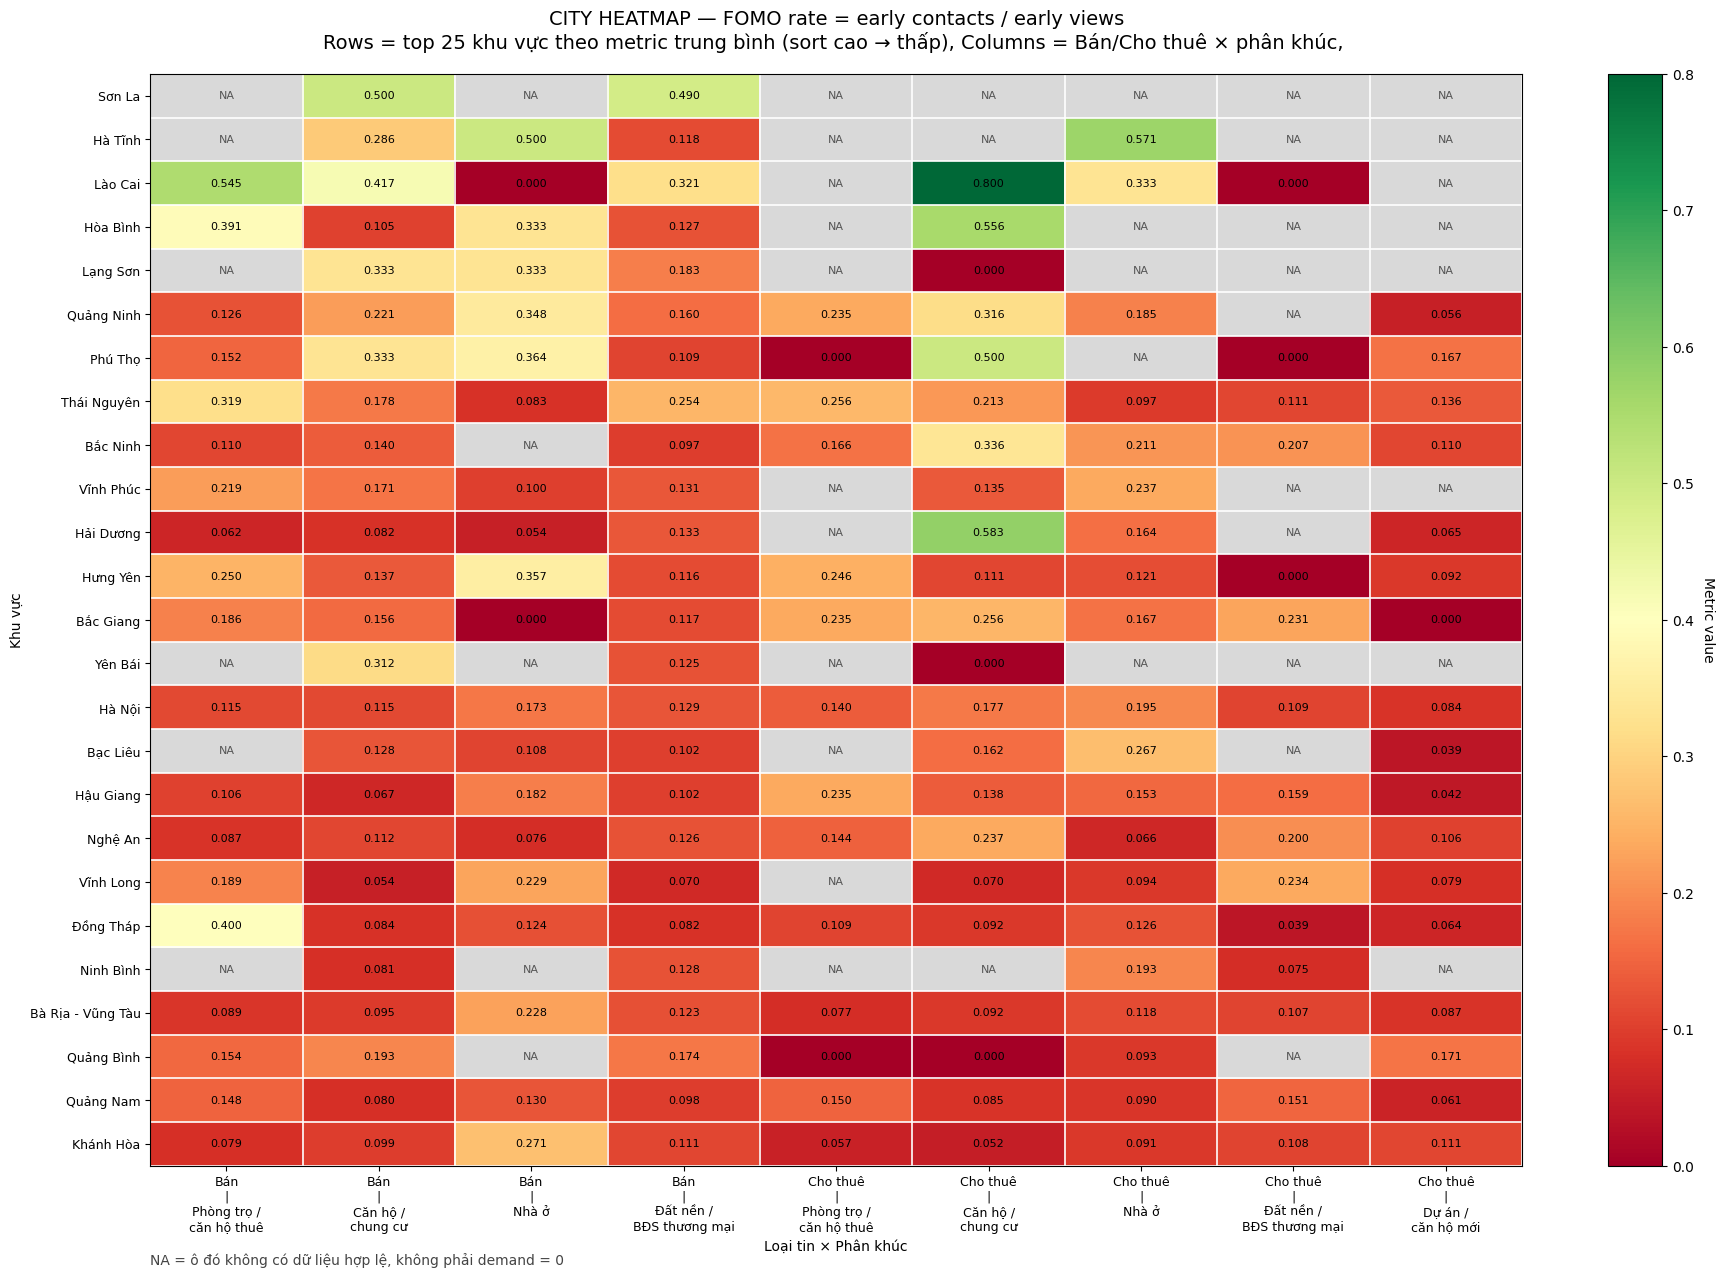

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_fomo_top25_no_listing_filter.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_fomo_top25_no_listing_filter_matrix.csv


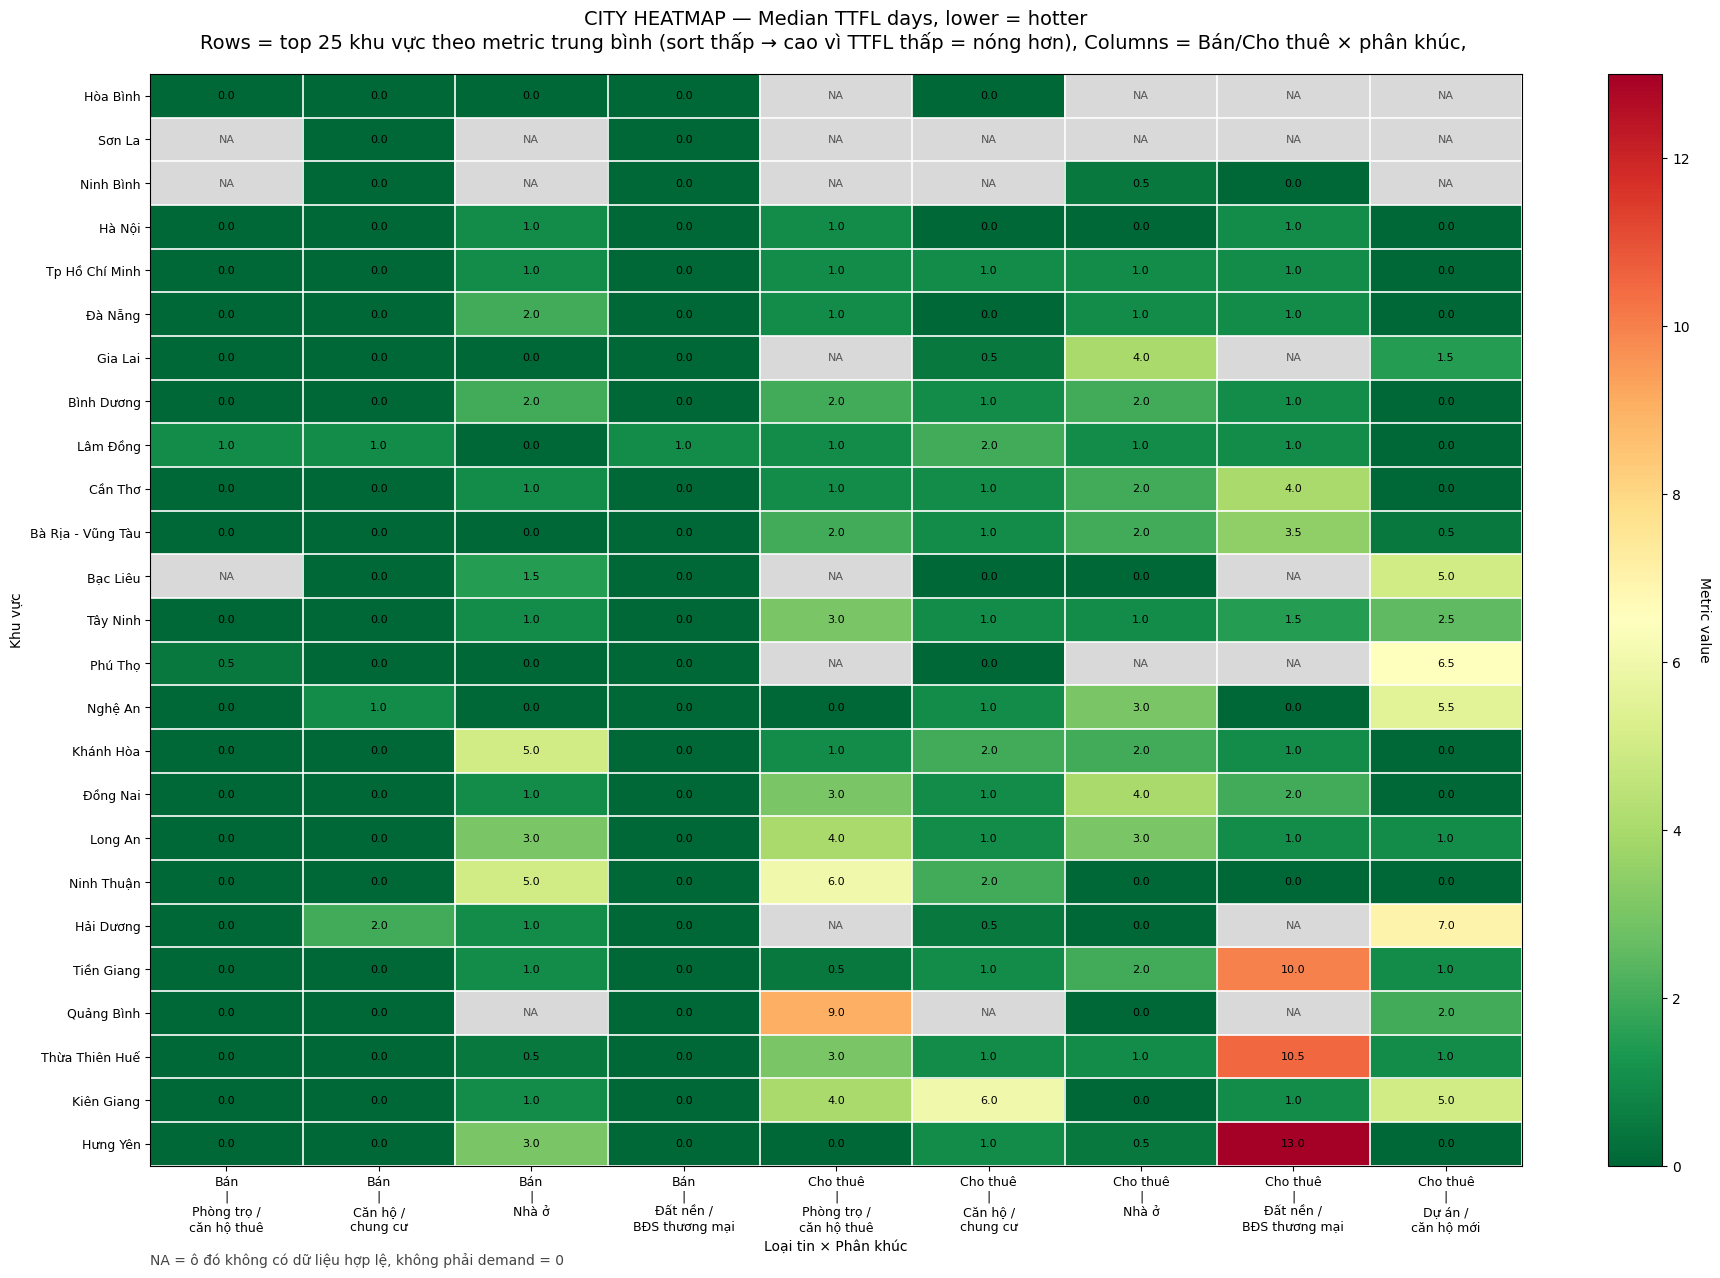

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_ttfl_top25_no_listing_filter.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_ttfl_top25_no_listing_filter_matrix.csv


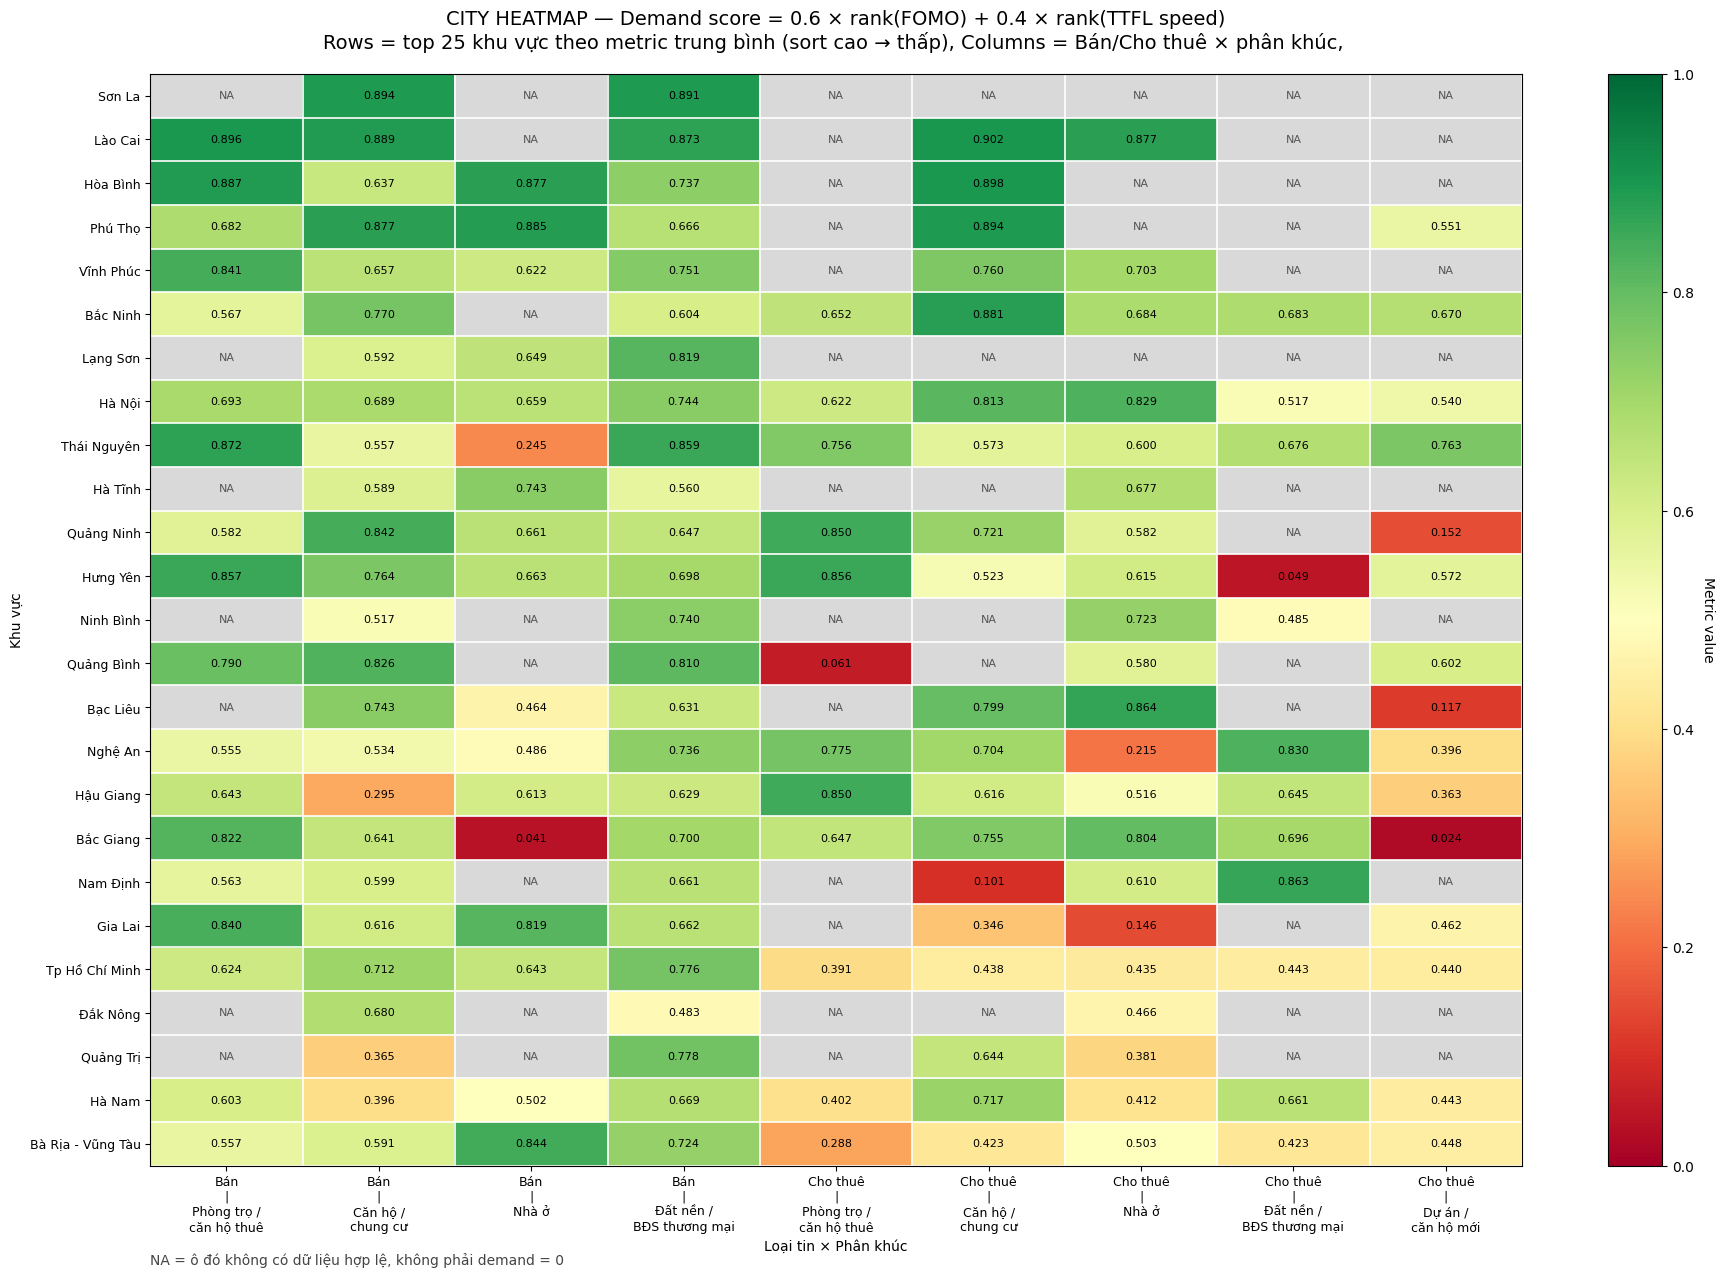

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_demand_top25_no_listing_filter.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_demand_top25_no_listing_filter_matrix.csv


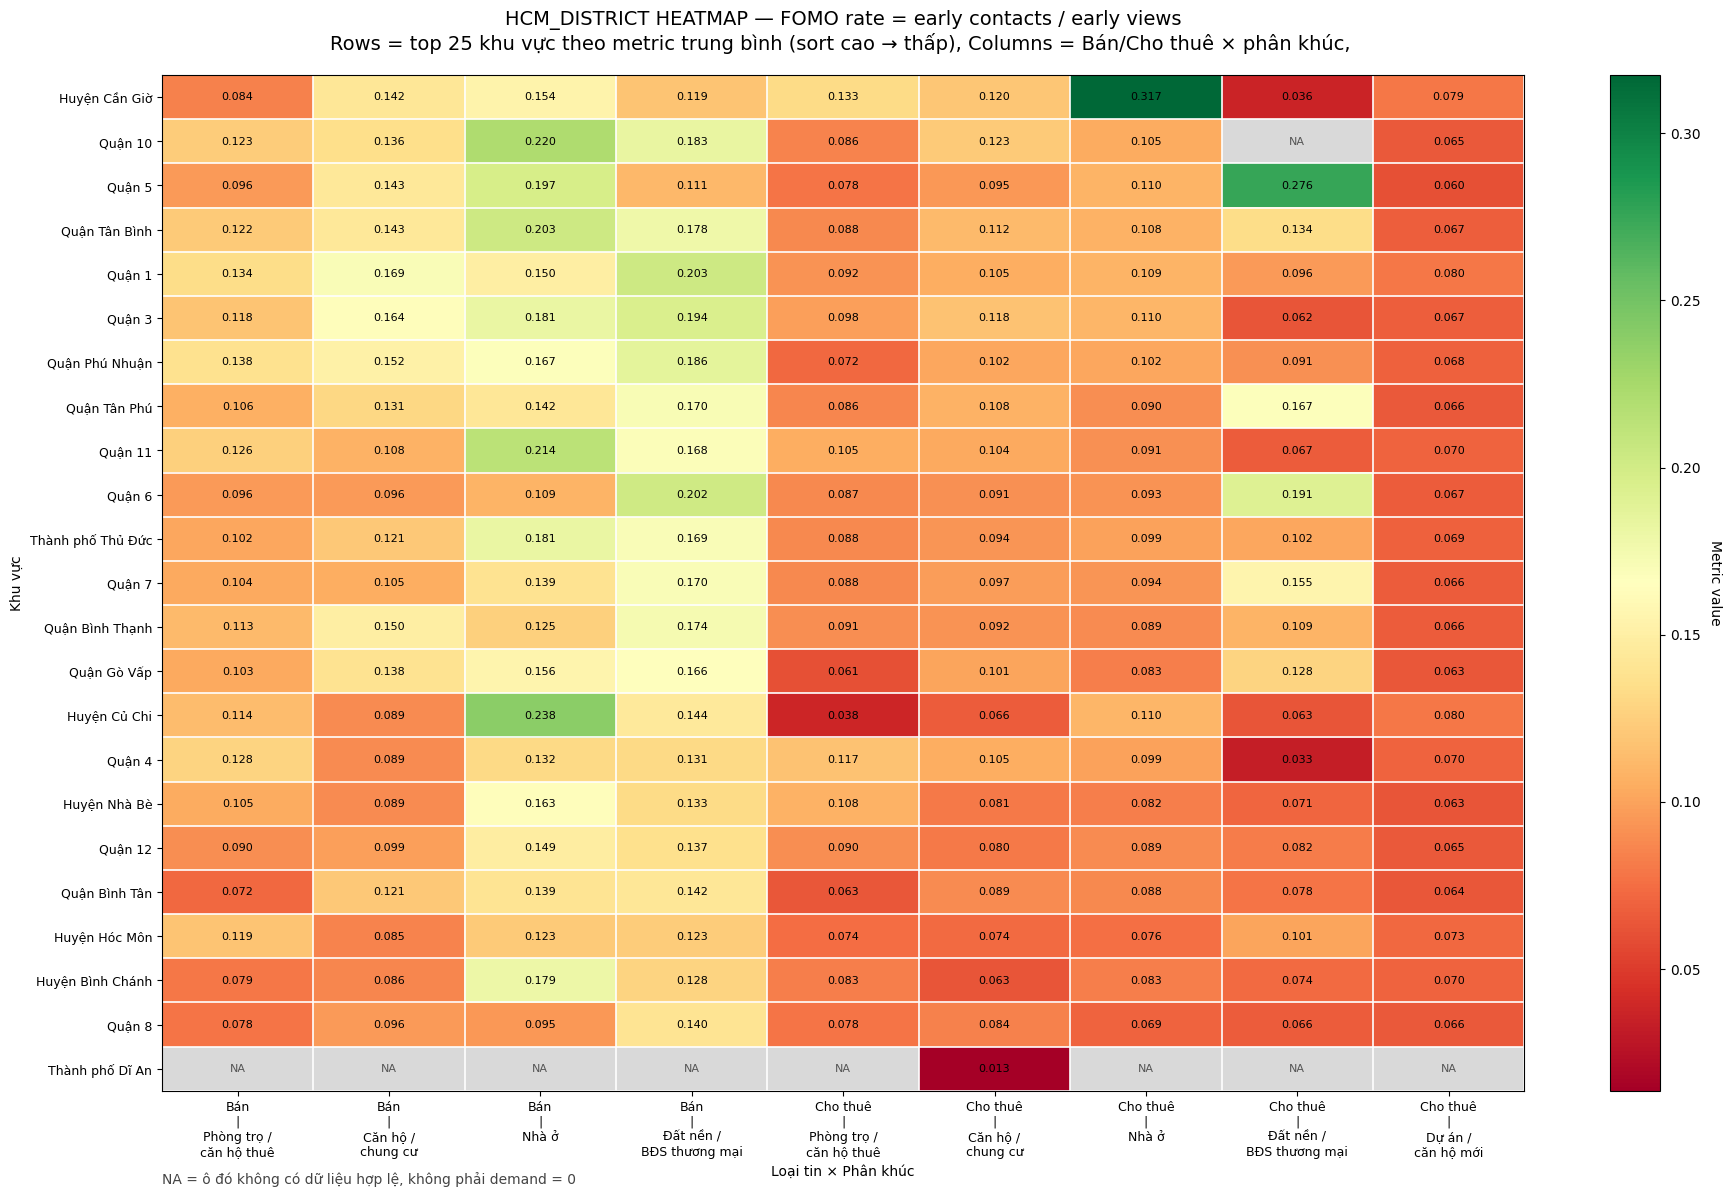

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/hcm_district_category_meaning_fomo_top25_no_listing_filter.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/hcm_district_category_meaning_fomo_top25_no_listing_filter_matrix.csv


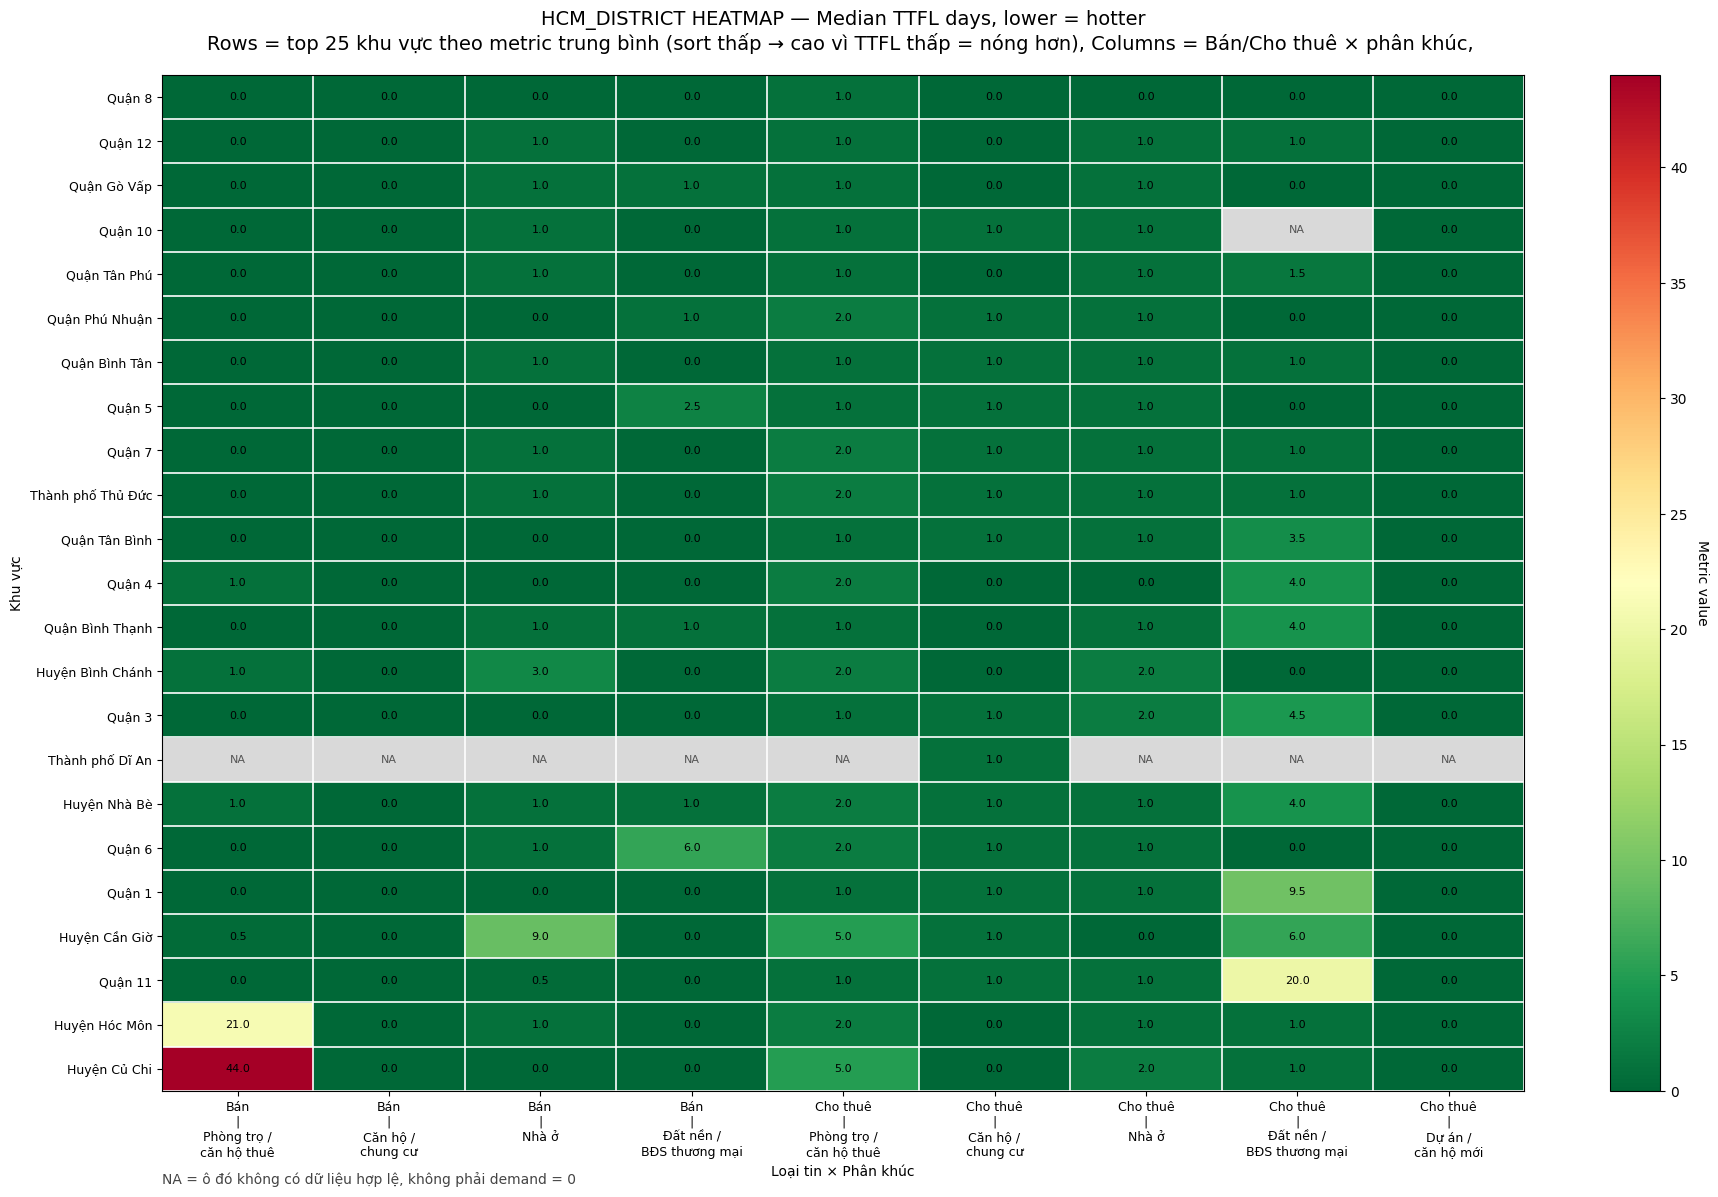

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/hcm_district_category_meaning_ttfl_top25_no_listing_filter.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/hcm_district_category_meaning_ttfl_top25_no_listing_filter_matrix.csv


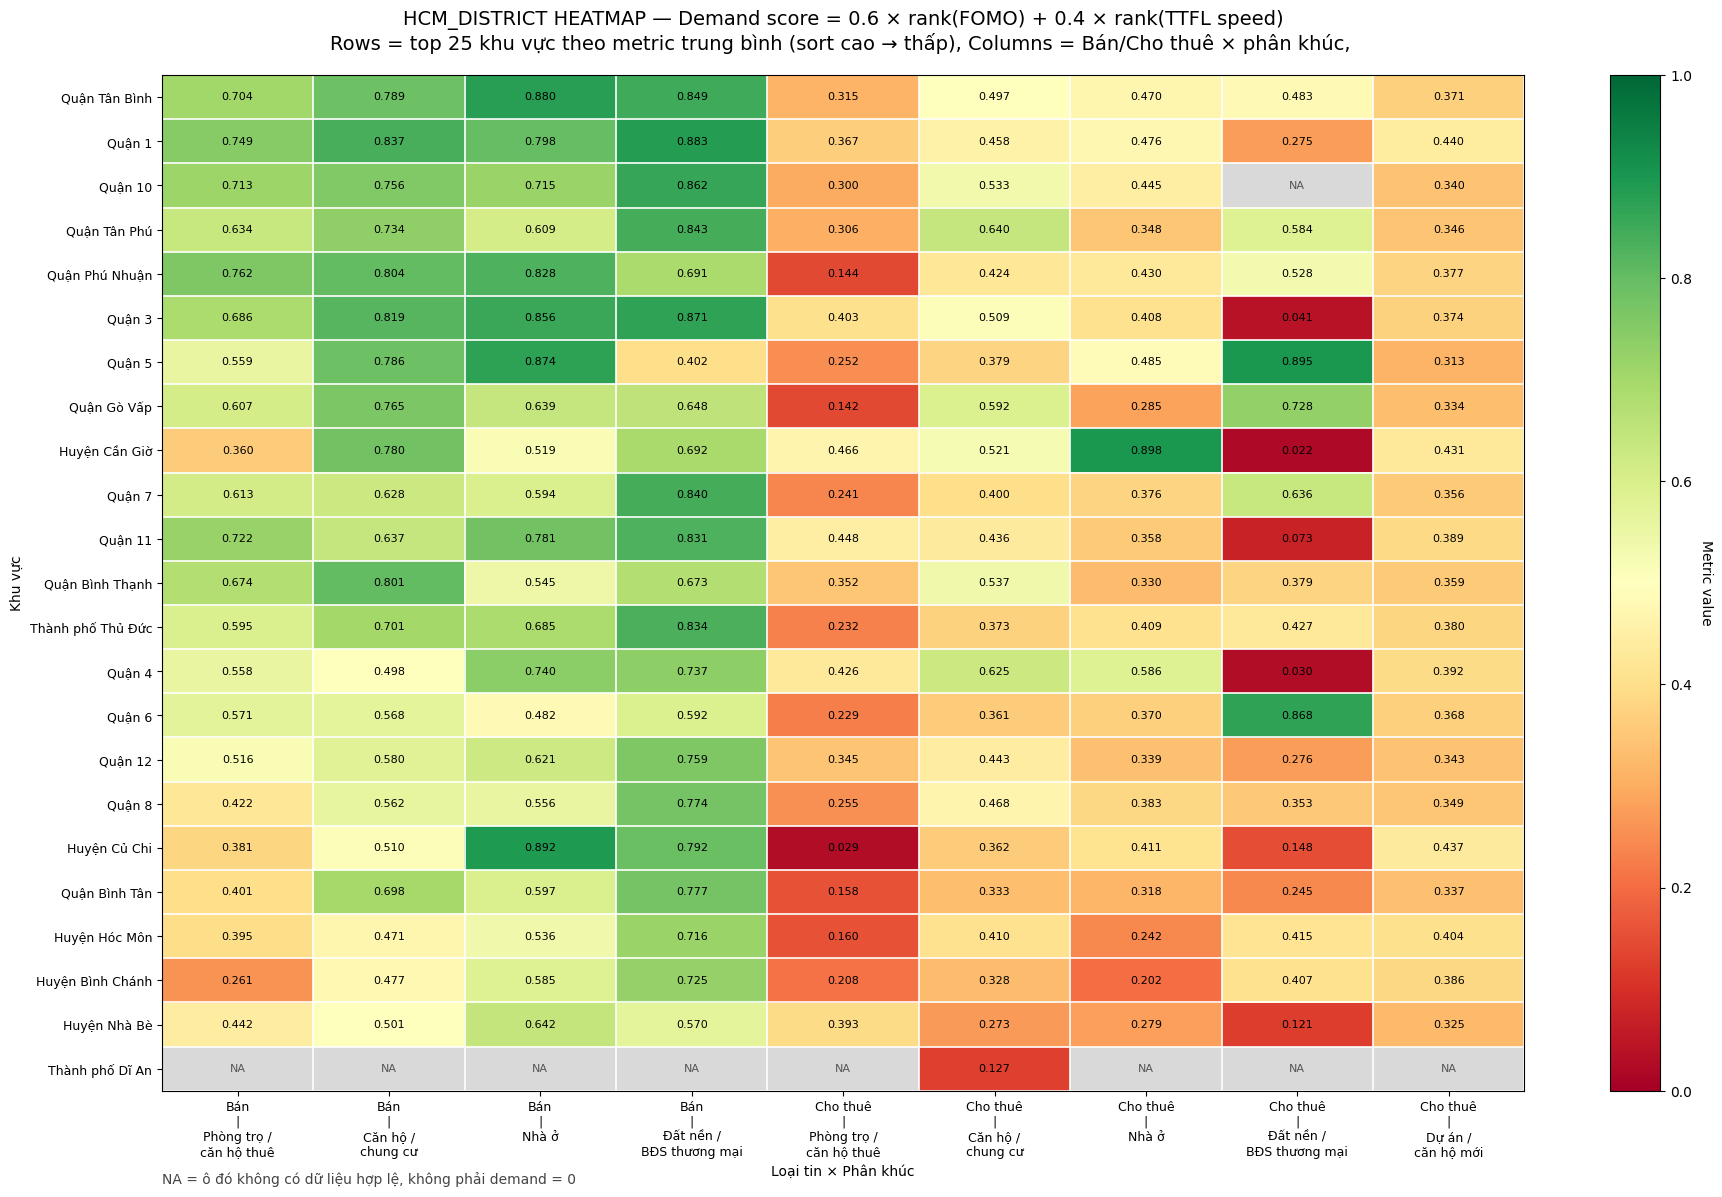

[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/hcm_district_category_meaning_demand_top25_no_listing_filter.png
[SAVED] /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/hcm_district_category_meaning_demand_top25_no_listing_filter_matrix.csv

DONE. Files saved in:
/kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_demand_top25_no_listing_filter.png
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_demand_top25_no_listing_filter_matrix.csv
- /kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter/static_top25_category_meaning_heatmaps/city_category_meaning_fom

In [13]:
# ============================================================
# STATIC FULL GRID HEATMAPS — TOP 25 MATRIX VERSION
#
# Change:
# - KHÔNG filter theo listing_count nữa
# - Heatmap / matrix CSV chỉ lấy TOP 25 row
# - FOMO, Demand: sort cao -> thấp
# - TTFL: sort thấp -> cao vì TTFL thấp = có lead nhanh hơn = nóng hơn
# - White cells replaced by light gray + "NA"
# - Columns use full category meaning instead of 1010/1020/...
# - Columns = sell/let × category meaning
# - Rows = city / HCM district
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# 1. PATH CONFIG
# ============================================================

READ_CACHE_DIR = "/kaggle/input/datasets/kimkhanhnguyen214/demand-v3/demand_v3_fomo_ttfl_traffic"

OUT_DIR = "/kaggle/working/redraw_demand_fomo_ttfl_heatmaps_top25_no_listing_filter"
os.makedirs(OUT_DIR, exist_ok=True)

STATIC_DIR = os.path.join(OUT_DIR, "static_top25_category_meaning_heatmaps")
os.makedirs(STATIC_DIR, exist_ok=True)

CITY_FINAL_CSV = os.path.join(
    READ_CACHE_DIR,
    "city_demand_v3_fomo_ttfl_traffic.csv"
)

HCM_FINAL_CSV = os.path.join(
    READ_CACHE_DIR,
    "hcm_district_demand_v3_fomo_ttfl_traffic.csv"
)

# Không filter theo số listing nữa
MIN_LISTINGS_CITY = None
MIN_LISTINGS_DISTRICT = None

# Matrix / heatmap chỉ lấy top 25 dòng
TOP_CITY_ROWS = 25
TOP_DISTRICT_ROWS = 25

CATEGORY_MEANING = {
    "1010": "Phòng trọ /\ncăn hộ thuê",
    "1020": "Căn hộ /\nchung cư",
    "1030": "Nhà ở",
    "1040": "Đất nền /\nBĐS thương mại",
    "1050": "Dự án /\ncăn hộ mới",
}

AD_TYPE_MEANING = {
    "sell": "Bán",
    "let": "Cho thuê",
}

# ============================================================
# 2. HELPERS
# ============================================================

def safe_div(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)


def pct_rank(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)

    if s.notna().sum() <= 1:
        return pd.Series(np.nan, index=s.index)

    if higher_is_better:
        return s.rank(pct=True, ascending=True)
    else:
        return s.rank(pct=True, ascending=False)


def normalize_ad_type(x):
    if pd.isna(x):
        return "unknown"

    x = str(x).strip().lower()

    if x in ["sell", "bán", "ban"]:
        return "sell"

    if x in ["let", "rent", "thuê", "thue"]:
        return "let"

    return x


def extract_category_code(x):
    """
    category_name thường có dạng:
    '1010 - Phòng trọ / căn hộ thuê'
    """
    if pd.isna(x):
        return "unknown"

    x = str(x).strip()

    m = re.match(r"^\s*(\d{4})", x)
    if m:
        return m.group(1)

    return x


def category_to_meaning(x):
    code = extract_category_code(x)
    return CATEGORY_MEANING.get(code, str(x))


def make_col_label(row):
    ad = normalize_ad_type(row["ad_type"])
    ad_label = AD_TYPE_MEANING.get(ad, ad)

    cate_label = category_to_meaning(row["category_name"])

    return f"{ad_label}\n|\n{cate_label}"


def enrich_metrics(df):
    df = df.copy()

    for c in [
        "listing_count",
        "early_views_24h",
        "early_contacts_24h",
        "median_ttfl_days",
        "items_with_lead",
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # FOMO
    if "fomo_early_contact_rate" not in df.columns:
        df["fomo_early_contact_rate"] = safe_div(
            df["early_contacts_24h"],
            df["early_views_24h"]
        )
    else:
        df["fomo_early_contact_rate"] = pd.to_numeric(
            df["fomo_early_contact_rate"],
            errors="coerce"
        )

    # TTFL speed
    df["ttfl_speed"] = 1 / (1 + df["median_ttfl_days"])

    # Demand score from FOMO + TTFL only
    df["score_fomo"] = pct_rank(
        df["fomo_early_contact_rate"],
        higher_is_better=True
    )

    df["score_ttfl_speed"] = pct_rank(
        df["ttfl_speed"],
        higher_is_better=True
    )

    df["demand_score_fomo_ttfl"] = (
        0.6 * df["score_fomo"]
        + 0.4 * df["score_ttfl_speed"]
    )

    df["ad_type"] = df["ad_type"].map(normalize_ad_type)
    df["category_code"] = df["category_name"].map(extract_category_code)
    df["category_meaning"] = df["category_name"].map(category_to_meaning)

    df["adtype_category_label"] = df.apply(make_col_label, axis=1)

    return df


def sort_col_labels(cols):
    """
    Sort columns:
    Bán 1010 -> 1020 -> ...
    Cho thuê 1010 -> 1020 -> ...
    """
    def key_func(col):
        col_str = str(col)

        if col_str.startswith("Bán"):
            ad_order = 0
        elif col_str.startswith("Cho thuê"):
            ad_order = 1
        else:
            ad_order = 9

        if "Phòng trọ" in col_str:
            cate_order = 1010
        elif "Căn hộ" in col_str and "chung cư" in col_str:
            cate_order = 1020
        elif "Nhà ở" in col_str:
            cate_order = 1030
        elif "Đất nền" in col_str:
            cate_order = 1040
        elif "Dự án" in col_str:
            cate_order = 1050
        else:
            cate_order = 9999

        return (ad_order, cate_order)

    return sorted(cols, key=key_func)


def make_full_grid_pivot(
    df,
    geo_col,
    metric,
    top_n=25,
    higher_is_better=True,
):
    tmp = df.copy()

    pivot = tmp.pivot_table(
        index=geo_col,
        columns="adtype_category_label",
        values=metric,
        aggfunc="mean"
    )

    pivot = pivot.reindex(columns=sort_col_labels(pivot.columns))

    # row_mean = trung bình metric của mỗi city/district qua các cột sell/let × category
    row_mean = pivot.mean(axis=1)

    # FOMO / Demand: cao hơn tốt hơn
    # TTFL: thấp hơn tốt hơn
    pivot = pivot.loc[
        row_mean.sort_values(ascending=not higher_is_better).index
    ]

    # Chỉ lấy top 25 row để matrix/heatmap dễ nhìn
    if top_n is not None:
        pivot = pivot.head(top_n)

    return pivot


def plot_static_heatmap(
    pivot,
    title,
    filename,
    fmt=".3f",
    higher_is_better=True,
    vmin=None,
    vmax=None,
    annotate=True,
):
    if pivot.empty:
        print("[SKIP] Empty pivot:", filename)
        return

    data = pivot.values.astype(float)

    n_rows, n_cols = data.shape

    fig_w = max(14, 1.65 * n_cols + 4)
    fig_h = max(7, 0.40 * n_rows + 2.8)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # NaN/missing cells will be light gray instead of white
    base_cmap = plt.cm.RdYlGn if higher_is_better else plt.cm.RdYlGn_r
    cmap = base_cmap.copy()
    cmap.set_bad(color="#d9d9d9")

    masked_data = np.ma.masked_invalid(data)

    im = ax.imshow(
        masked_data,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title, fontsize=14, pad=18)
    ax.set_xlabel("Loại tin × Phân khúc")
    ax.set_ylabel("Khu vực")

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(pivot.columns, rotation=0, ha="center", fontsize=9)

    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(pivot.index, fontsize=9)

    # grid lines
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    if annotate:
        for i in range(n_rows):
            for j in range(n_cols):
                val = data[i, j]

                if np.isfinite(val):
                    text = format(val, fmt)
                    color = "black"
                else:
                    text = "NA"
                    color = "#555555"

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=color
                )

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Metric value", rotation=270, labelpad=15)

    ax.text(
        0,
        -0.08,
        "NA = ô đó không có dữ liệu hợp lệ, không phải demand = 0",
        transform=ax.transAxes,
        fontsize=10,
        color="#444444",
        ha="left",
        va="top"
    )

    plt.tight_layout()

    out_path = os.path.join(STATIC_DIR, filename)
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print("[SAVED]", out_path)


def draw_geo_full_grid_heatmaps(
    df,
    geo_col,
    geo_name,
    min_listings=None,
    top_n=25,
):
    df = df.copy()

    # ========================================================
    # KHÔNG FILTER listing_count nữa
    # Giữ toàn bộ dữ liệu, kể cả listing_count nhỏ
    # ========================================================

    # Chỉ giữ sell / let vì chart đang thiết kế theo Bán / Cho thuê
    df = df[df["ad_type"].isin(["sell", "let"])].copy()

    if len(df) == 0:
        print("[SKIP] No rows:", geo_name)
        return

    configs = [
        {
            "metric": "fomo_early_contact_rate",
            "name": "fomo",
            "title": "FOMO rate = early contacts / early views",
            "fmt": ".3f",
            "higher_is_better": True,
            "vmin": None,
            "vmax": None,
            "sort_note": "sort cao → thấp",
        },
        {
            "metric": "median_ttfl_days",
            "name": "ttfl",
            "title": "Median TTFL days, lower = hotter",
            "fmt": ".1f",
            "higher_is_better": False,
            "vmin": None,
            "vmax": None,
            "sort_note": "sort thấp → cao vì TTFL thấp = nóng hơn",
        },
        {
            "metric": "demand_score_fomo_ttfl",
            "name": "demand",
            "title": "Demand score = 0.6 × rank(FOMO) + 0.4 × rank(TTFL speed)",
            "fmt": ".3f",
            "higher_is_better": True,
            "vmin": 0,
            "vmax": 1,
            "sort_note": "sort cao → thấp",
        },
    ]

    for cfg in configs:
        pivot = make_full_grid_pivot(
            df=df,
            geo_col=geo_col,
            metric=cfg["metric"],
            top_n=top_n,
            higher_is_better=cfg["higher_is_better"],
        )

        title = (
            f"{geo_name.upper()} HEATMAP — {cfg['title']}\n"
            f"Rows = top {top_n} khu vực theo metric trung bình ({cfg['sort_note']}), "
            f"Columns = Bán/Cho thuê × phân khúc, "
        
        )

        filename = f"{geo_name.lower()}_category_meaning_{cfg['name']}_top{top_n}_no_listing_filter.png"

        plot_static_heatmap(
            pivot=pivot,
            title=title,
            filename=filename,
            fmt=cfg["fmt"],
            higher_is_better=cfg["higher_is_better"],
            vmin=cfg["vmin"],
            vmax=cfg["vmax"],
            annotate=True,
        )

        matrix_path = os.path.join(
            STATIC_DIR,
            f"{geo_name.lower()}_category_meaning_{cfg['name']}_top{top_n}_no_listing_filter_matrix.csv"
        )
        pivot.to_csv(matrix_path)
        print("[SAVED]", matrix_path)


# ============================================================
# 3. LOAD DATA
# ============================================================

city = pd.read_csv(CITY_FINAL_CSV)
city = enrich_metrics(city)

hcm = pd.read_csv(HCM_FINAL_CSV)
hcm = enrich_metrics(hcm)

# Bỏ district lỗi / unmapped cho HCM district chart
hcm = hcm[
    ~hcm["district_name"].astype(str).isin(["Unknown District", "Unmapped Item"])
].copy()

print("city shape:", city.shape)
print("hcm shape:", hcm.shape)

print("\nCategory labels used:")
for k, v in CATEGORY_MEANING.items():
    print(k, "=>", v.replace("\n", " "))

print("\nIMPORTANT:")
print("- Không filter theo listing_count.")
print("- Heatmap / matrix CSV chỉ giữ top 25 row.")
print("- FOMO, Demand sort cao -> thấp.")
print("- TTFL sort thấp -> cao vì TTFL thấp nghĩa là listing có lead nhanh hơn.")

# ============================================================
# 4. DRAW HEATMAPS
# ============================================================

draw_geo_full_grid_heatmaps(
    df=city,
    geo_col="city_name",
    geo_name="city",
    min_listings=MIN_LISTINGS_CITY,
    top_n=TOP_CITY_ROWS,
)

draw_geo_full_grid_heatmaps(
    df=hcm,
    geo_col="district_name",
    geo_name="hcm_district",
    min_listings=MIN_LISTINGS_DISTRICT,
    top_n=TOP_DISTRICT_ROWS,
)

# ============================================================
# 5. OUTPUT
# ============================================================

print("\nDONE. Files saved in:")
print(STATIC_DIR)

for f in sorted(os.listdir(STATIC_DIR)):
    print("-", os.path.join(STATIC_DIR, f))